# Database Comparison Analysis - Chunking Strategies

This notebook provides comprehensive analysis of RAG evaluation results comparing different:
- **Database configurations** (fixed_size vs by_sentence)
- **Chunking strategies** (different chunk sizes and overlaps)
- **Models** (InternVL3, Qwen3-4B)
- **Performance metrics** (semantic similarity, BLEU, ROUGE, TF-IDF)

## Data Source
Analysis based on JSON files from: `E:\00_SW\01_RAG\tests\db_comparsion_logs\logs`

## 1. Import Required Libraries

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Any, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Parse Filenames and Load Data

Extract configuration details from filenames and load all evaluation results.

**Filename Format:**
- **Fixed Size**: `answer_evaluation_results_chroma_db_fixed_size_Qwen_Qwen3-Embedding-0.6B_[embed_dim]_[chunk_size]_[overlap]_cleaned_[model]_[timestamp].json`
  - Example: `...1024_500_150...` → embed_dim=1024, chunk_size=500, overlap=150
  
- **By Sentence**: `answer_evaluation_results_chroma_db_by_sentence_Qwen_Qwen3-Embedding-0.6B_[embed_dim]_[chunk_size]_cleaned_[model]_[timestamp].json`
  - Example: `...1024_500...` → embed_dim=1024, chunk_size=500 (no overlap)

In [4]:
def parse_filename(filename: str) -> Dict[str, Any]:
    """
    Parse filename to extract configuration parameters.
    
    Format for fixed_size:
    answer_evaluation_results_chroma_db_fixed_size_Qwen_Qwen3-Embedding-0.6B_{embed_dim}_{chunk_size}_{overlap}_{model}_{timestamp}.json
    
    Format for by_sentence:
    answer_evaluation_results_chroma_db_by_sentence_Qwen_Qwen3-Embedding-0.6B_{embed_dim}_{chunk_size}_{model}_{timestamp}.json
    """
    # Remove extension and prefix
    name = filename.replace('answer_evaluation_results_', '').replace('.json', '')
    
    parts = name.split('_')
    
    config = {
        'filename': filename,
        'db_type': None,
        'chunking_strategy': None,
        'embedding_model': None,
        'embed_dimension': None,
        'chunk_size': None,
        'overlap': None,
        'timestamp': None
    }
    
    # Identify database type
    if 'fixed_size' in name:
        config['db_type'] = 'fixed_size'
        config['chunking_strategy'] = 'fixed_size'
    elif 'by_sentence' in name:
        config['db_type'] = 'by_sentence'
        config['chunking_strategy'] = 'by_sentence'
    
    # Extract numeric parameters (embed_dim, chunk_size, overlap for fixed_size)
    numbers = []
    for i, part in enumerate(parts):
        if part.isdigit():
            numbers.append((i, int(part)))
    
    # Assign numbers based on context
    if config['chunking_strategy'] == 'fixed_size' and len(numbers) >= 3:
        # For fixed_size: embed_dim, chunk_size, overlap
        config['embed_dimension'] = numbers[0][1]  # First number is embed dimension (1024)
        config['chunk_size'] = numbers[1][1]       # Second number is chunk_size (500, 750, 1000, etc.)
        config['overlap'] = numbers[2][1]          # Third number is overlap (150, 200, 250, etc.)
    elif config['chunking_strategy'] == 'by_sentence' and len(numbers) >= 2:
        # For by_sentence: embed_dim, chunk_size (no overlap)
        config['embed_dimension'] = numbers[0][1]  # First number is embed dimension (1024)
        config['chunk_size'] = numbers[1][1]       # Second number is chunk_size (500, 1000, etc.)
    
    # Extract embedding model
    if 'Qwen3-Embedding' in name:
        config['embedding_model'] = 'Qwen3-Embedding-0.6B'
    
    # Extract timestamp
    timestamp_match = re.search(r'_(\d{8}_\d{6})\.json$', filename)
    if timestamp_match:
        config['timestamp'] = timestamp_match.group(1)
    
    return config


def load_all_results(logs_dir: str) -> pd.DataFrame:
    """Load all JSON files and create a comprehensive DataFrame."""
    logs_path = Path(logs_dir)
    all_data = []
    
    json_files = list(logs_path.glob('answer_evaluation_results_*.json'))
    print(f"Found {len(json_files)} JSON files")
    
    for json_file in json_files:
        try:
            # Parse filename
            config = parse_filename(json_file.name)
            
            # Load JSON data
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            # Extract model name from session_tags in JSON (not filename)
            model_name = None
            if 'session_tags' in data and 'model' in data['session_tags']:
                model_name = data['session_tags']['model']
            
            # Extract metrics
            row = {
                'filename': json_file.name,
                'db_type': config['db_type'],
                'chunking_strategy': config['chunking_strategy'],
                'embedding_model': config['embedding_model'],
                'embed_dimension': config['embed_dimension'],
                'chunk_size': config['chunk_size'],
                'overlap': config['overlap'],
                'model_name': model_name,  # Now from JSON, not filename
                'timestamp': config['timestamp'],
                'total_questions': data.get('total_questions_evaluated', 0),
                'avg_semantic_similarity': None,
                'avg_bleu_score': None,
                'avg_rouge_1_f': None,
                'avg_rouge_2_f': None,
                'avg_rouge_l_f': None,
                'avg_tfidf_similarity': None,
                'avg_response_time': None
            }
            
            # Calculate averages from per_question_results
            if 'per_question_results' in data and data['per_question_results']:
                results = data['per_question_results']
                row['avg_semantic_similarity'] = np.mean([r.get('semantic_similarity', 0) for r in results])
                row['avg_bleu_score'] = np.mean([r.get('bleu_score', 0) for r in results])
                row['avg_rouge_1_f'] = np.mean([r.get('rouge_1_f', 0) for r in results])
                row['avg_rouge_2_f'] = np.mean([r.get('rouge_2_f', 0) for r in results])
                row['avg_rouge_l_f'] = np.mean([r.get('rouge_l_f', 0) for r in results])
                row['avg_tfidf_similarity'] = np.mean([r.get('tfidf_similarity', 0) for r in results])
                row['avg_response_time'] = np.mean([r.get('response_time_seconds', 0) for r in results])
            
            all_data.append(row)
            
        except Exception as e:
            print(f"Error processing {json_file.name}: {e}")
    
    df = pd.DataFrame(all_data)
    print(f"\n✓ Loaded {len(df)} evaluation results")
    return df


# Load the data
logs_directory = r"E:\00_SW\01_RAG\tests\db_comparsion_logs\logs"
df = load_all_results(logs_directory)
print(f"\nDataFrame shape: {df.shape}")
print(f"\nUnique models found: {df['model_name'].nunique()}")
print(f"Model names: {sorted(df['model_name'].dropna().unique())}")

Found 204 JSON files

✓ Loaded 204 evaluation results

DataFrame shape: (204, 17)

Unique models found: 6
Model names: ['InternVL3-2B-Instruct-Q5_K_M', 'InternVL3_5-2B-Q8_0', 'InternVL3_5-8B-Q4_K_M', 'OpenGVLab_InternVL3_5-8B-Q6_K', 'Qwen3-4B-Instruct-2507-Q8_0', 'Qwen3-8B-Q5_K_M']


In [5]:
# DEBUG: Check actual filename and JSON structure
import json
from pathlib import Path

logs_directory = r"E:\00_SW\01_RAG\tests\db_comparsion_logs\logs"
logs_path = Path(logs_directory)
json_files = list(logs_path.glob('answer_evaluation_results_*.json'))

if json_files:
    sample_file = json_files[0]
    print(f"Sample filename: {sample_file.name}")
    print("\n" + "=" * 100)
    
    with open(sample_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    print("JSON structure keys:")
    print(list(data.keys()))
    
    if 'session_tags' in data:
        print("\nsession_tags content:")
        print(json.dumps(data['session_tags'], indent=2))
    
    print("\n" + "=" * 100)
else:
    print("No JSON files found!")

Sample filename: answer_evaluation_results_chroma_db_fixed_size_Qwen_Qwen3-Embedding-0.6B_1024_1000_150_cleaned_InternVL3_2B_Instruct_Q5_K_M_20251206_051055.json

JSON structure keys:
['evaluation_timestamp', 'session_name', 'session_tags', 'gold_standard_path', 'inference_log_path', 'embedding_model', 'inference_index_used', 'max_questions_limit', 'total_questions_evaluated', 'per_question_results', 'aggregate_stats']

session_tags content:
{
  "model": "InternVL3-2B-Instruct-Q5_K_M",
  "db_path": "/app/01_RAG/data/output/chroma_db_fixed_size_Qwen_Qwen3-Embedding-0.6B_1024_1000_150_cleaned",
  "top_k": 20,
  "similarity_threshold": 50.0,
  "test_questions_path": "data/test/inference_test_questions.json"
}



## 3. Data Overview

Display basic statistics and check data quality.

In [6]:
# Display first few rows
print("=" * 100)
print("SAMPLE DATA")
print("=" * 100)
display(df.head(10))

print("\n" + "=" * 100)
print("DATA INFO")
print("=" * 100)
print(f"Total records: {len(df)}")
print(f"Unique chunking strategies: {df['chunking_strategy'].nunique()}")
print(f"Unique models: {df['model_name'].nunique()}")
print(f"Embedding dimension: {sorted(df['embed_dimension'].dropna().unique())}")
print(f"Unique chunk sizes: {sorted(df['chunk_size'].dropna().unique())}")
print(f"Unique overlaps (fixed_size): {sorted(df[df['chunking_strategy']=='fixed_size']['overlap'].dropna().unique())}")

print("\n" + "=" * 100)
print("MISSING VALUES")
print("=" * 100)
print(df.isnull().sum())

SAMPLE DATA


,filename,db_type,chunking_strategy,embedding_model,embed_dimension,chunk_size,overlap,model_name,timestamp,total_questions,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_rouge_2_f,avg_rouge_l_f,avg_tfidf_similarity,avg_response_time
0,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,InternVL3-2B-Instruct-Q5_K_M,20251206_051055,10,0.822282,0.092017,0.417327,0.185048,0.263228,0.606854,4.236291
1,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,InternVL3_5-2B-Q8_0,20251206_061059,10,0.814201,0.089293,0.404027,0.146145,0.236057,0.556055,16.042976
2,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,InternVL3_5-8B-Q4_K_M,20251206_024111,10,0.833778,0.116620,0.438529,0.199110,0.274609,0.634966,15.204763
3,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,OpenGVLab_InternVL3_5-8B-Q6_K,20251206_084942,10,0.782871,0.109869,0.423661,0.190604,0.249808,0.596610,16.556071
4,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,Qwen3-4B-Instruct-2507-Q8_0,20251205_194519,10,0.868377,0.090416,0.429145,0.188945,0.255968,0.598306,15.427454
5,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,150,Qwen3-8B-Q5_K_M,20251205_223419,10,0.844035,0.093190,0.453692,0.187572,0.248019,0.584216,37.739600
6,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,200,InternVL3-2B-Instruct-Q5_K_M,20251206_053049,10,0.815550,0.069772,0.402425,0.153998,0.247461,0.527200,3.088588
7,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,200,InternVL3_5-2B-Q8_0,20251206_073627,10,0.816624,0.088725,0.373721,0.138754,0.220196,0.555252,26.806898
8,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,200,InternVL3_5-8B-Q4_K_M,20251206_040317,10,0.838098,0.126005,0.440072,0.197163,0.272757,0.622920,16.840469
9,answer_evaluation_results_chroma_db_fixed_size...,fixed_size,fixed_size,Qwen3-Embedding-0.6B,1024,1000,200,OpenGVLab_InternVL3_5-8B-Q6_K,20251206_103008,10,0.772077,0.083031,0.350734,0.139181,0.206359,0.532290,47.199689



DATA INFO
Total records: 204
Unique chunking strategies: 1
Unique models: 6
Embedding dimension: [np.int64(1024)]
Unique chunk sizes: [np.int64(500), np.int64(750), np.int64(1000), np.int64(1250), np.int64(1500), np.int64(2000), np.int64(3000), np.int64(4000)]
Unique overlaps (fixed_size): [np.int64(100), np.int64(150), np.int64(200), np.int64(250), np.int64(350), np.int64(450)]

MISSING VALUES
filename                   0
db_type                    0
chunking_strategy          0
embedding_model            0
embed_dimension            0
chunk_size                 0
overlap                    0
model_name                 0
timestamp                  0
total_questions            0
avg_semantic_similarity    0
avg_bleu_score             0
avg_rouge_1_f              0
avg_rouge_2_f              0
avg_rouge_l_f              0
avg_tfidf_similarity       0
avg_response_time          0
dtype: int64


## 4. Chunking Strategy Comparison

Compare performance between **fixed_size** and **by_sentence** chunking strategies.

In [7]:
# Group by chunking strategy
strategy_comparison = df.groupby('chunking_strategy').agg({
    'avg_semantic_similarity': ['mean', 'std', 'min', 'max'],
    'avg_bleu_score': ['mean', 'std', 'min', 'max'],
    'avg_rouge_1_f': ['mean', 'std', 'min', 'max'],
    'avg_tfidf_similarity': ['mean', 'std', 'min', 'max'],
    'avg_response_time': ['mean', 'std', 'min', 'max']
}).round(4)

print("=" * 100)
print("CHUNKING STRATEGY PERFORMANCE COMPARISON")
print("=" * 100)
display(strategy_comparison)

# Statistical summary
print("\n" + "=" * 100)
print("KEY INSIGHTS - CHUNKING STRATEGY")
print("=" * 100)

for strategy in df['chunking_strategy'].unique():
    if pd.notna(strategy):
        strategy_data = df[df['chunking_strategy'] == strategy]
        print(f"\n{strategy.upper()}:")
        print(f"  Total configurations: {len(strategy_data)}")
        print(f"  Avg Semantic Similarity: {strategy_data['avg_semantic_similarity'].mean():.4f} (±{strategy_data['avg_semantic_similarity'].std():.4f})")
        print(f"  Avg BLEU Score: {strategy_data['avg_bleu_score'].mean():.4f} (±{strategy_data['avg_bleu_score'].std():.4f})")
        print(f"  Avg ROUGE-1 F1: {strategy_data['avg_rouge_1_f'].mean():.4f} (±{strategy_data['avg_rouge_1_f'].std():.4f})")
        print(f"  Avg Response Time: {strategy_data['avg_response_time'].mean():.4f}s")

CHUNKING STRATEGY PERFORMANCE COMPARISON


avg_semantic_similarity                          \
                                     mean     std     min     max   
chunking_strategy                                                   
fixed_size                         0.8273  0.0292  0.6537  0.8708   

                  avg_bleu_score                         avg_rouge_1_f  \
                            mean     std     min     max          mean   
chunking_strategy                                                        
fixed_size                0.0909  0.0179  0.0541  0.1391        0.4076   

                                          avg_tfidf_similarity                 \
                      std     min     max                 mean    std     min   
chunking_strategy                                                               
fixed_size         0.0293  0.3074  0.4801               0.5655  0.036  0.3948   

                         avg_response_time                             
                     max              mean      std     min       max  
chunking_strategy                                                      
fixed_size         0.636           26.1336  18.4728  2.3411  124.8298


KEY INSIGHTS - CHUNKING STRATEGY

FIXED_SIZE:
  Total configurations: 204
  Avg Semantic Similarity: 0.8273 (±0.0292)
  Avg BLEU Score: 0.0909 (±0.0179)
  Avg ROUGE-1 F1: 0.4076 (±0.0293)
  Avg Response Time: 26.1336s


In [8]:
# Quick query: Which database has overlap=120?
if 'df' in dir() and len(df) > 0:
    overlap_120 = df[df['overlap'] == 120]
    if len(overlap_120) > 0:
        print("=" * 100)
        print("DATABASE CONFIGURATIONS WITH OVERLAP = 120")
        print("=" * 100)
        print(f"\nFound {len(overlap_120)} configuration(s):\n")
        for idx, row in overlap_120.iterrows():
            print(f"Database Type: {row['db_type']}")
            print(f"Chunking Strategy: {row['chunking_strategy']}")
            print(f"Model: {row['model_name']}")
            print(f"Chunk Size: {row['chunk_size']}")
            print(f"Overlap: {row['overlap']}")
            print(f"Filename: {row['filename']}")
            print(f"Semantic Similarity: {row['avg_semantic_similarity']:.4f}")
            print(f"BLEU Score: {row['avg_bleu_score']:.4f}")
            print("-" * 100)
    else:
        print("No configurations found with overlap = 120")
        print(f"\nAvailable overlap values: {sorted(df['overlap'].dropna().unique())}")
else:
    print("Please run the data loading cells first (Section 2)")

No configurations found with overlap = 120

Available overlap values: [np.int64(100), np.int64(150), np.int64(200), np.int64(250), np.int64(350), np.int64(450)]


In [9]:
# Calculate composite score
df['composite_score'] = (
    df['avg_semantic_similarity'] * 0.35 +
    df['avg_bleu_score'] * 0.20 +
    df['avg_rouge_1_f'] * 0.25 +
    df['avg_tfidf_similarity'] * 0.20
)

# Calculate composite score to match top_k configurations
"""df['composite_score'] = (
    df['avg_semantic_similarity'] * 0.60 +
    df['avg_bleu_score'] * 0.20 +
    df['avg_tfidf_similarity'] * 0.20
)
"""

# Top 10 configurations
top_configs = df.nlargest(10, 'composite_score')[
    ['chunking_strategy', 'embed_dimension', 'chunk_size', 'overlap', 'model_name',
     'avg_semantic_similarity', 'avg_bleu_score', 'avg_rouge_1_f', 
     'avg_tfidf_similarity', 'composite_score', 'avg_response_time']
].round(4)

print("=" * 120)
print("TOP 10 CONFIGURATIONS (Composite Score)")
print("=" * 120)
print("\nComposite Score = 0.35*Semantic + 0.20*BLEU + 0.25*ROUGE + 0.20*TF-IDF\n")
display(top_configs.reset_index(drop=True))

TOP 10 CONFIGURATIONS (Composite Score)

Composite Score = 0.35*Semantic + 0.20*BLEU + 0.25*ROUGE + 0.20*TF-IDF



,chunking_strategy,embed_dimension,chunk_size,overlap,model_name,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_tfidf_similarity,composite_score,avg_response_time
0,fixed_size,1024,500,200,Qwen3-4B-Instruct-2507-Q8_0,0.8661,0.1265,0.4608,0.6240,0.5684,13.4849
1,fixed_size,1024,1000,350,OpenGVLab_InternVL3_5-8B-Q6_K,0.8666,0.1166,0.4670,0.6154,0.5665,18.6125
2,fixed_size,1024,500,200,OpenGVLab_InternVL3_5-8B-Q6_K,0.8372,0.1391,0.4795,0.6011,0.5609,24.8008
3,fixed_size,1024,1250,350,InternVL3_5-8B-Q4_K_M,0.8520,0.1116,0.4533,0.6353,0.5609,14.8351
4,fixed_size,1024,750,150,Qwen3-4B-Instruct-2507-Q8_0,0.8654,0.1170,0.4398,0.6221,0.5607,14.5605
5,fixed_size,1024,500,100,InternVL3_5-8B-Q4_K_M,0.8549,0.1129,0.4530,0.6170,0.5585,11.3417
6,fixed_size,1024,750,450,Qwen3-4B-Instruct-2507-Q8_0,0.8708,0.1132,0.4331,0.6136,0.5584,15.5941
7,fixed_size,1024,750,150,InternVL3_5-8B-Q4_K_M,0.8442,0.1234,0.4567,0.6147,0.5573,12.1538
8,fixed_size,1024,750,250,OpenGVLab_InternVL3_5-8B-Q6_K,0.8202,0.1203,0.4801,0.6296,0.5571,13.4782
9,fixed_size,1024,1500,450,InternVL3_5-8B-Q4_K_M,0.8558,0.1191,0.4317,0.6255,0.5564,22.1749


## 5. Chunk Size Analysis

Analyze how different chunk sizes affect performance across strategies.

CHUNK SIZE PERFORMANCE BY STRATEGY AND MODEL


,chunking_strategy,model_name,chunk_size,overlap,avg_semantic_similarity_mean,avg_semantic_similarity_std,avg_bleu_score_mean,avg_rouge_1_f_mean,avg_rouge_2_f_mean,avg_tfidf_similarity_mean,avg_response_time_mean,composite_score_mean
0,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,100,0.836097,NaN,0.082962,0.414896,0.189485,0.577701,2.341094,0.528490
1,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,150,0.834019,NaN,0.080465,0.403671,0.157672,0.557366,2.672217,0.520390
2,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,200,0.838145,NaN,0.081728,0.451527,0.183863,0.575813,2.444540,0.537741
3,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,250,0.809393,NaN,0.065113,0.400850,0.141719,0.554837,2.506447,0.507490
4,fixed_size,InternVL3-2B-Instruct-Q5_K_M,750,150,0.824566,NaN,0.093056,0.442605,0.173102,0.584132,2.628722,0.534687
...,...,...,...,...,...,...,...,...,...,...,...,...
199,fixed_size,Qwen3-8B-Q5_K_M,3000,450,0.841561,NaN,0.083744,0.407714,0.157609,0.569098,57.126126,0.527043
200,fixed_size,Qwen3-8B-Q5_K_M,4000,150,0.853603,NaN,0.084161,0.421689,0.155373,0.588883,66.894791,0.538792
201,fixed_size,Qwen3-8B-Q5_K_M,4000,250,0.858403,NaN,0.101730,0.429998,0.178635,0.587448,65.310572,0.545776
202,fixed_size,Qwen3-8B-Q5_K_M,4000,350,0.858627,NaN,0.080639,0.419945,0.158175,0.566781,68.511805,0.534990



STRATEGY-LEVEL CHUNK SIZE SUMMARY (mean values)


,chunking_strategy,chunk_size,avg_semantic_similarity_mean,avg_semantic_similarity_std,avg_bleu_score_mean,avg_rouge_1_f_mean,avg_rouge_2_f_mean,avg_tfidf_similarity_mean,avg_response_time_mean,composite_score_mean
0,fixed_size,500,0.832414,0.022002,0.095133,0.427942,0.172233,0.580630,16.947859,0.533483
1,fixed_size,750,0.833515,0.020428,0.096012,0.419797,0.169863,0.584806,16.817071,0.532843
2,fixed_size,1000,0.833358,0.022771,0.091911,0.415060,0.164344,0.574529,20.169391,0.528728
3,fixed_size,1250,0.831022,0.024593,0.086643,0.398962,0.156677,0.558161,19.144591,0.519559
4,fixed_size,1500,0.825789,0.028870,0.088522,0.401208,0.164014,0.565937,22.680131,0.520220
5,fixed_size,2000,0.830148,0.022291,0.088093,0.394372,0.157923,0.559542,29.237676,0.518672
6,fixed_size,3000,0.813792,0.045151,0.085707,0.392105,0.156446,0.539963,39.084645,0.507988
7,fixed_size,4000,0.817067,0.036367,0.095518,0.410995,0.169177,0.557763,47.341886,0.519378



BEST CHUNK SIZE PER STRATEGY & MODEL (by Semantic Similarity)

FIXED_SIZE:
  InternVL3-2B-Instruct-Q5_K_M: chunk_size=4000, semantic=0.862654, BLEU=0.077209, ROUGE-1=0.395004, RespTime=11.5086s
  InternVL3_5-2B-Q8_0: chunk_size=1500, semantic=0.852216, BLEU=0.091450, ROUGE-1=0.422702, RespTime=19.4873s
  InternVL3_5-8B-Q4_K_M: chunk_size=2000, semantic=0.859351, BLEU=0.112415, ROUGE-1=0.399800, RespTime=59.7692s
  OpenGVLab_InternVL3_5-8B-Q6_K: chunk_size=1000, semantic=0.866573, BLEU=0.116551, ROUGE-1=0.467017, RespTime=18.6125s
  Qwen3-4B-Instruct-2507-Q8_0: chunk_size=750, semantic=0.870787, BLEU=0.113201, ROUGE-1=0.433060, RespTime=15.5941s
  Qwen3-8B-Q5_K_M: chunk_size=4000, semantic=0.860249, BLEU=0.088498, ROUGE-1=0.421672, RespTime=74.5138s


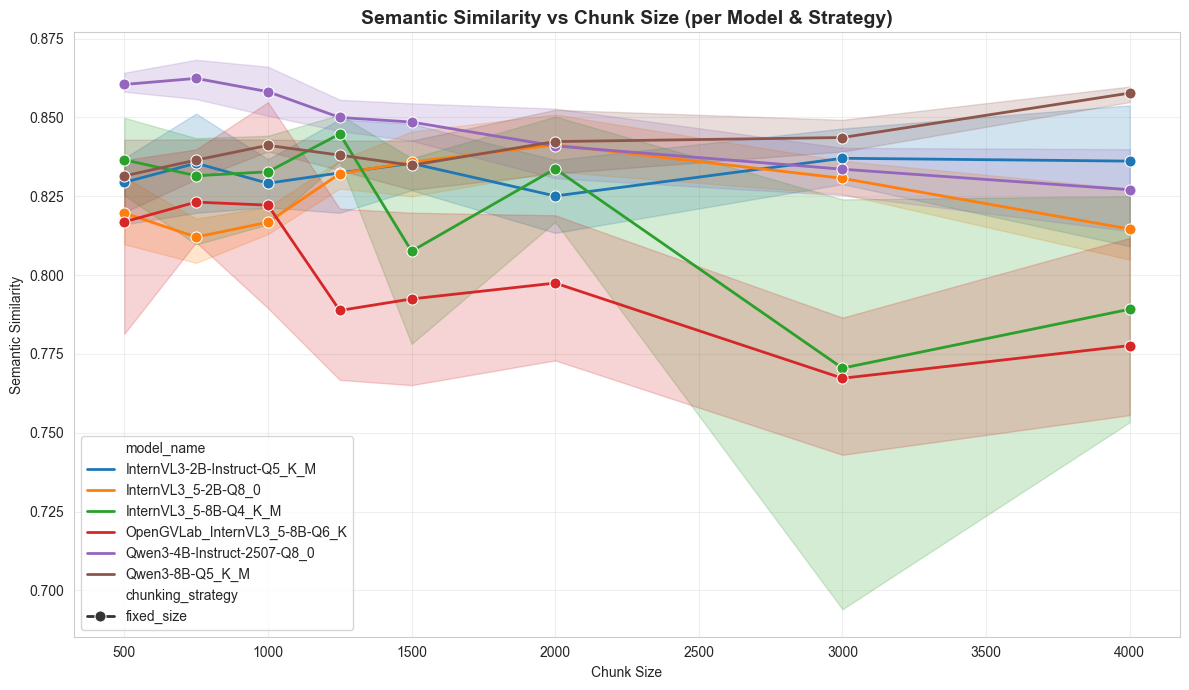

In [10]:
# Chunk size analysis by strategy and model (higher precision to avoid hiding differences)
if len(df) == 0:
    print("No data available for chunk size analysis")
else:
    metrics_for_agg = {
        'avg_semantic_similarity': ['mean', 'std'],
        'avg_bleu_score': 'mean',
        'avg_rouge_1_f': 'mean',
        'avg_rouge_2_f': 'mean',
        'avg_tfidf_similarity': 'mean',
        'avg_response_time': 'mean',
        'composite_score': 'mean'
    }
    
    def _flatten_cols(frame):
        frame = frame.copy()
        frame.columns = [
            '_'.join([c for c in col if c]) if isinstance(col, tuple) else str(col)
            for col in frame.columns
        ]
        return frame
    
    # Full breakdown: strategy + model + chunk size
    chunk_analysis = df.groupby(['chunking_strategy', 'model_name', 'chunk_size', 'overlap']).agg(metrics_for_agg)
    chunk_analysis = _flatten_cols(chunk_analysis).reset_index().round(6)
    
    print("=" * 100)
    print("CHUNK SIZE PERFORMANCE BY STRATEGY AND MODEL")
    print("=" * 100)
    display(chunk_analysis.sort_values(['chunking_strategy', 'model_name', 'chunk_size']))
    
    # Backward-compatible summary (strategy + chunk size only) but with more precision
    strategy_chunk_summary = df.groupby(['chunking_strategy', 'chunk_size']).agg(metrics_for_agg)
    strategy_chunk_summary = _flatten_cols(strategy_chunk_summary).reset_index().round(6)
    
    print("\n" + "=" * 100)
    print("STRATEGY-LEVEL CHUNK SIZE SUMMARY (mean values)")
    print("=" * 100)
    display(strategy_chunk_summary.sort_values(['chunking_strategy', 'chunk_size']))
    
    # Find optimal chunk sizes per strategy and model
    print("\n" + "=" * 100)
    print("BEST CHUNK SIZE PER STRATEGY & MODEL (by Semantic Similarity)")
    print("=" * 100)
    for strategy in sorted(df['chunking_strategy'].dropna().unique()):
        strategy_subset = chunk_analysis[chunk_analysis['chunking_strategy'] == strategy]
        print(f"\n{strategy.upper()}:")
        for model in sorted(strategy_subset['model_name'].dropna().unique()):
            model_subset = strategy_subset[strategy_subset['model_name'] == model]
            best_row = model_subset.loc[model_subset['avg_semantic_similarity_mean'].idxmax()]
            print(
                f"  {model}: chunk_size={int(best_row['chunk_size'])}, "
                f"semantic={best_row['avg_semantic_similarity_mean']:.6f}, "
                f"BLEU={best_row['avg_bleu_score_mean']:.6f}, "
                f"ROUGE-1={best_row['avg_rouge_1_f_mean']:.6f}, "
                f"RespTime={best_row['avg_response_time_mean']:.4f}s"
            )
    
    # Visualization: chunk size vs semantic similarity by model & strategy
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(
        data=chunk_analysis,
        x='chunk_size',
        y='avg_semantic_similarity_mean',
        hue='model_name',
        style='chunking_strategy',
        markers=True,
        dashes=False,
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    ax.set_title('Semantic Similarity vs Chunk Size (per Model & Strategy)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Chunk Size')
    ax.set_ylabel('Semantic Similarity')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Overlap Analysis (Fixed Size Chunking)

For fixed_size chunking, analyze the effect of overlap parameter.

In [11]:
# Per-file variance: semantic similarity by strategy, model, and chunk size
if len(df) == 0:
    print("No data available for variance breakdown")
else:
    variance_table = (
        df.groupby(['chunking_strategy', 'model_name', 'chunk_size', 'overlap'])
          .agg(
              count=('avg_semantic_similarity', 'count'),
              semantic_min=('avg_semantic_similarity', 'min'),
              semantic_max=('avg_semantic_similarity', 'max'),
              semantic_mean=('avg_semantic_similarity', 'mean'),
              semantic_std=('avg_semantic_similarity', 'std'),
              composite_mean=('composite_score', 'mean'),
          )
          .reset_index()
          .round(6)
    )
    print("=" * 100)
    print("PER-FILE VARIANCE: Semantic Similarity by Strategy, Model, Chunk Size")
    print("=" * 100)
    display(variance_table.sort_values(['chunking_strategy','model_name','chunk_size']))

PER-FILE VARIANCE: Semantic Similarity by Strategy, Model, Chunk Size


,chunking_strategy,model_name,chunk_size,overlap,count,semantic_min,semantic_max,semantic_mean,semantic_std,composite_mean
0,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,100,1,0.836097,0.836097,0.836097,NaN,0.528490
1,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,150,1,0.834019,0.834019,0.834019,NaN,0.520390
2,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,200,1,0.838145,0.838145,0.838145,NaN,0.537741
3,fixed_size,InternVL3-2B-Instruct-Q5_K_M,500,250,1,0.809393,0.809393,0.809393,NaN,0.507490
4,fixed_size,InternVL3-2B-Instruct-Q5_K_M,750,150,1,0.824566,0.824566,0.824566,NaN,0.534687
...,...,...,...,...,...,...,...,...,...,...
199,fixed_size,Qwen3-8B-Q5_K_M,3000,450,1,0.841561,0.841561,0.841561,NaN,0.527043
200,fixed_size,Qwen3-8B-Q5_K_M,4000,150,1,0.853603,0.853603,0.853603,NaN,0.538792
201,fixed_size,Qwen3-8B-Q5_K_M,4000,250,1,0.858403,0.858403,0.858403,NaN,0.545776
202,fixed_size,Qwen3-8B-Q5_K_M,4000,350,1,0.858627,0.858627,0.858627,NaN,0.534990


In [12]:
# Filter fixed_size data
fixed_size_df = df[df['chunking_strategy'] == 'fixed_size'].copy()

if len(fixed_size_df) > 0:
    # Overlap analysis
    overlap_analysis = fixed_size_df.groupby(['chunk_size', 'overlap']).agg({
        'avg_semantic_similarity': 'mean',
        'avg_bleu_score': 'mean',
        'avg_rouge_1_f': 'mean',
        'avg_tfidf_similarity': 'mean',
        'avg_response_time': 'mean',
        'composite_score': 'mean'
    }).round(4).reset_index()
    
    print("=" * 100)
    print("OVERLAP PARAMETER ANALYSIS (Fixed Size Chunking)")
    print("=" * 100)
    display(overlap_analysis.sort_values(['chunk_size', 'overlap']))
    
    # Best overlap per chunk size
    print("\n" + "=" * 100)
    print("OPTIMAL OVERLAP BY CHUNK SIZE")
    print("=" * 100)
    
    for chunk_size in sorted(fixed_size_df['chunk_size'].unique()):
        chunk_data = overlap_analysis[overlap_analysis['chunk_size'] == chunk_size]
        if len(chunk_data) > 0:
            best = chunk_data.loc[chunk_data['avg_semantic_similarity'].idxmax()]
            print(f"\nChunk Size {int(chunk_size)}:")
            print(f"  Best overlap: {int(best['overlap'])}")
            print(f"  Semantic Similarity: {best['avg_semantic_similarity']:.4f}")
            print(f"  BLEU Score: {best['avg_bleu_score']:.4f}")
else:
    print("No fixed_size chunking data available")

OVERLAP PARAMETER ANALYSIS (Fixed Size Chunking)


,chunk_size,overlap,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_tfidf_similarity,avg_response_time,composite_score
0,500,100,0.8424,0.0994,0.4292,0.5929,15.2902,0.5406
1,500,150,0.8191,0.0839,0.4131,0.5581,15.6496,0.5183
2,500,200,0.8417,0.1129,0.4545,0.5929,15.5241,0.5494
3,500,250,0.8265,0.0844,0.4150,0.5787,21.3276,0.5256
4,750,150,0.8407,0.1022,0.4293,0.5942,17.7087,0.5409
5,750,250,0.8348,0.0969,0.4335,0.6080,15.4638,0.5416
6,750,350,0.8194,0.0880,0.4042,0.5645,15.2294,0.5183
7,750,450,0.8391,0.0970,0.4121,0.5725,18.8665,0.5306
8,1000,150,0.8276,0.0986,0.4277,0.5962,17.5345,0.5355
9,1000,200,0.8251,0.0892,0.3937,0.5577,23.7324,0.5166



OPTIMAL OVERLAP BY CHUNK SIZE

Chunk Size 500:
  Best overlap: 100
  Semantic Similarity: 0.8424
  BLEU Score: 0.0994

Chunk Size 750:
  Best overlap: 150
  Semantic Similarity: 0.8407
  BLEU Score: 0.1022

Chunk Size 1000:
  Best overlap: 250
  Semantic Similarity: 0.8431
  BLEU Score: 0.0852

Chunk Size 1250:
  Best overlap: 450
  Semantic Similarity: 0.8369
  BLEU Score: 0.0835

Chunk Size 1500:
  Best overlap: 350
  Semantic Similarity: 0.8319
  BLEU Score: 0.0809

Chunk Size 2000:
  Best overlap: 250
  Semantic Similarity: 0.8376
  BLEU Score: 0.0919

Chunk Size 3000:
  Best overlap: 250
  Semantic Similarity: 0.8263
  BLEU Score: 0.0850

Chunk Size 4000:
  Best overlap: 250
  Semantic Similarity: 0.8225
  BLEU Score: 0.0924


## 7. Model Performance Comparison

Compare different models across all configurations.

In [13]:
# Model comparison
model_comparison = df.groupby('model_name').agg({
    'avg_semantic_similarity': ['mean', 'std', 'min', 'max'],
    'avg_bleu_score': ['mean', 'std', 'min', 'max'],
    'avg_rouge_1_f': ['mean', 'std', 'min', 'max'],
    'avg_tfidf_similarity': ['mean', 'std', 'min', 'max'],
    'avg_response_time': ['mean', 'std'],
    'composite_score': ['mean', 'std']
}).round(4)

print("=" * 100)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 100)
display(model_comparison.sort_values(('avg_semantic_similarity', 'mean'), ascending=False))

# Best model per chunking strategy
print("\n" + "=" * 100)
print("BEST MODEL PER CHUNKING STRATEGY")
print("=" * 100)

for strategy in df['chunking_strategy'].unique():
    if pd.notna(strategy):
        strategy_data = df[df['chunking_strategy'] == strategy].groupby('model_name').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean'
        }).round(4)
        
        if len(strategy_data) == 0:
            print(f"\n{strategy.upper()}:")
            print(f"  No data available")
            continue
        
        best_model = strategy_data['avg_semantic_similarity'].idxmax()
        print(f"\n{strategy.upper()}:")
        print(f"  Best model: {best_model}")
        print(f"  Semantic Similarity: {strategy_data.loc[best_model, 'avg_semantic_similarity']:.4f}")
        print(f"  BLEU Score: {strategy_data.loc[best_model, 'avg_bleu_score']:.4f}")

MODEL PERFORMANCE COMPARISON


avg_semantic_similarity                          \
                                                 mean     std     min     max   
model_name                                                                      
Qwen3-4B-Instruct-2507-Q8_0                    0.8480  0.0147  0.8082  0.8708   
Qwen3-8B-Q5_K_M                                0.8405  0.0106  0.8178  0.8602   
InternVL3-2B-Instruct-Q5_K_M                   0.8325  0.0152  0.7972  0.8627   
InternVL3_5-2B-Q8_0                            0.8254  0.0136  0.7999  0.8522   
InternVL3_5-8B-Q4_K_M                          0.8184  0.0411  0.6537  0.8594   
OpenGVLab_InternVL3_5-8B-Q6_K                  0.7988  0.0350  0.7329  0.8666   

                              avg_bleu_score                          \
                                        mean     std     min     max   
model_name                                                             
Qwen3-4B-Instruct-2507-Q8_0           0.0952  0.0140  0.0672  0.1265   
Qwen3-8B-Q5_K_M                       0.0769  0.0099  0.0551  0.1017   
InternVL3-2B-Instruct-Q5_K_M          0.0780  0.0132  0.0541  0.1049   
InternVL3_5-2B-Q8_0                   0.0886  0.0130  0.0660  0.1227   
InternVL3_5-8B-Q4_K_M                 0.1039  0.0156  0.0692  0.1303   
OpenGVLab_InternVL3_5-8B-Q6_K         0.1029  0.0191  0.0642  0.1391   

                              avg_rouge_1_f                          \
                                       mean     std     min     max   
model_name                                                            
Qwen3-4B-Instruct-2507-Q8_0          0.4004  0.0242  0.3592  0.4608   
Qwen3-8B-Q5_K_M                      0.4062  0.0190  0.3610  0.4537   
InternVL3-2B-Instruct-Q5_K_M         0.4104  0.0256  0.3491  0.4515   
InternVL3_5-2B-Q8_0                  0.3983  0.0278  0.3445  0.4574   
InternVL3_5-8B-Q4_K_M                0.4179  0.0391  0.3074  0.4625   
OpenGVLab_InternVL3_5-8B-Q6_K        0.4123  0.0333  0.3507  0.4801   

                              avg_tfidf_similarity                          \
                                              mean     std     min     max   
model_name                                                                   
Qwen3-4B-Instruct-2507-Q8_0                 0.5826  0.0236  0.5427  0.6240   
Qwen3-8B-Q5_K_M                             0.5479  0.0281  0.4918  0.5889   
InternVL3-2B-Instruct-Q5_K_M                0.5630  0.0256  0.5061  0.6133   
InternVL3_5-2B-Q8_0                         0.5567  0.0239  0.5083  0.6108   
InternVL3_5-8B-Q4_K_M                       0.5832  0.0498  0.3948  0.6353   
OpenGVLab_InternVL3_5-8B-Q6_K               0.5594  0.0429  0.4781  0.6360   

                              avg_response_time          composite_score  \
                                           mean      std            mean   
model_name                                                                 
Qwen3-4B-Instruct-2507-Q8_0             22.1891   9.2717          0.5324   
Qwen3-8B-Q5_K_M                         40.8418  13.3830          0.5207   
InternVL3-2B-Instruct-Q5_K_M             5.5669   4.4248          0.5222   
InternVL3_5-2B-Q8_0                     24.3633   7.4952          0.5175   
InternVL3_5-8B-Q4_K_M                   31.1772  26.4945          0.5283   
OpenGVLab_InternVL3_5-8B-Q6_K           32.6633  17.5583          0.5151   

                                       
                                  std  
model_name                             
Qwen3-4B-Instruct-2507-Q8_0    0.0159  
Qwen3-8B-Q5_K_M                0.0139  
InternVL3-2B-Instruct-Q5_K_M   0.0160  
InternVL3_5-2B-Q8_0            0.0117  
InternVL3_5-8B-Q4_K_M          0.0341  
OpenGVLab_InternVL3_5-8B-Q6_K  0.0274


BEST MODEL PER CHUNKING STRATEGY

FIXED_SIZE:
  Best model: Qwen3-4B-Instruct-2507-Q8_0
  Semantic Similarity: 0.8480
  BLEU Score: 0.0952


## 8. Visualizations

Create comprehensive visualizations to understand patterns and relationships.

### 8.1 Chunking Strategy Comparison

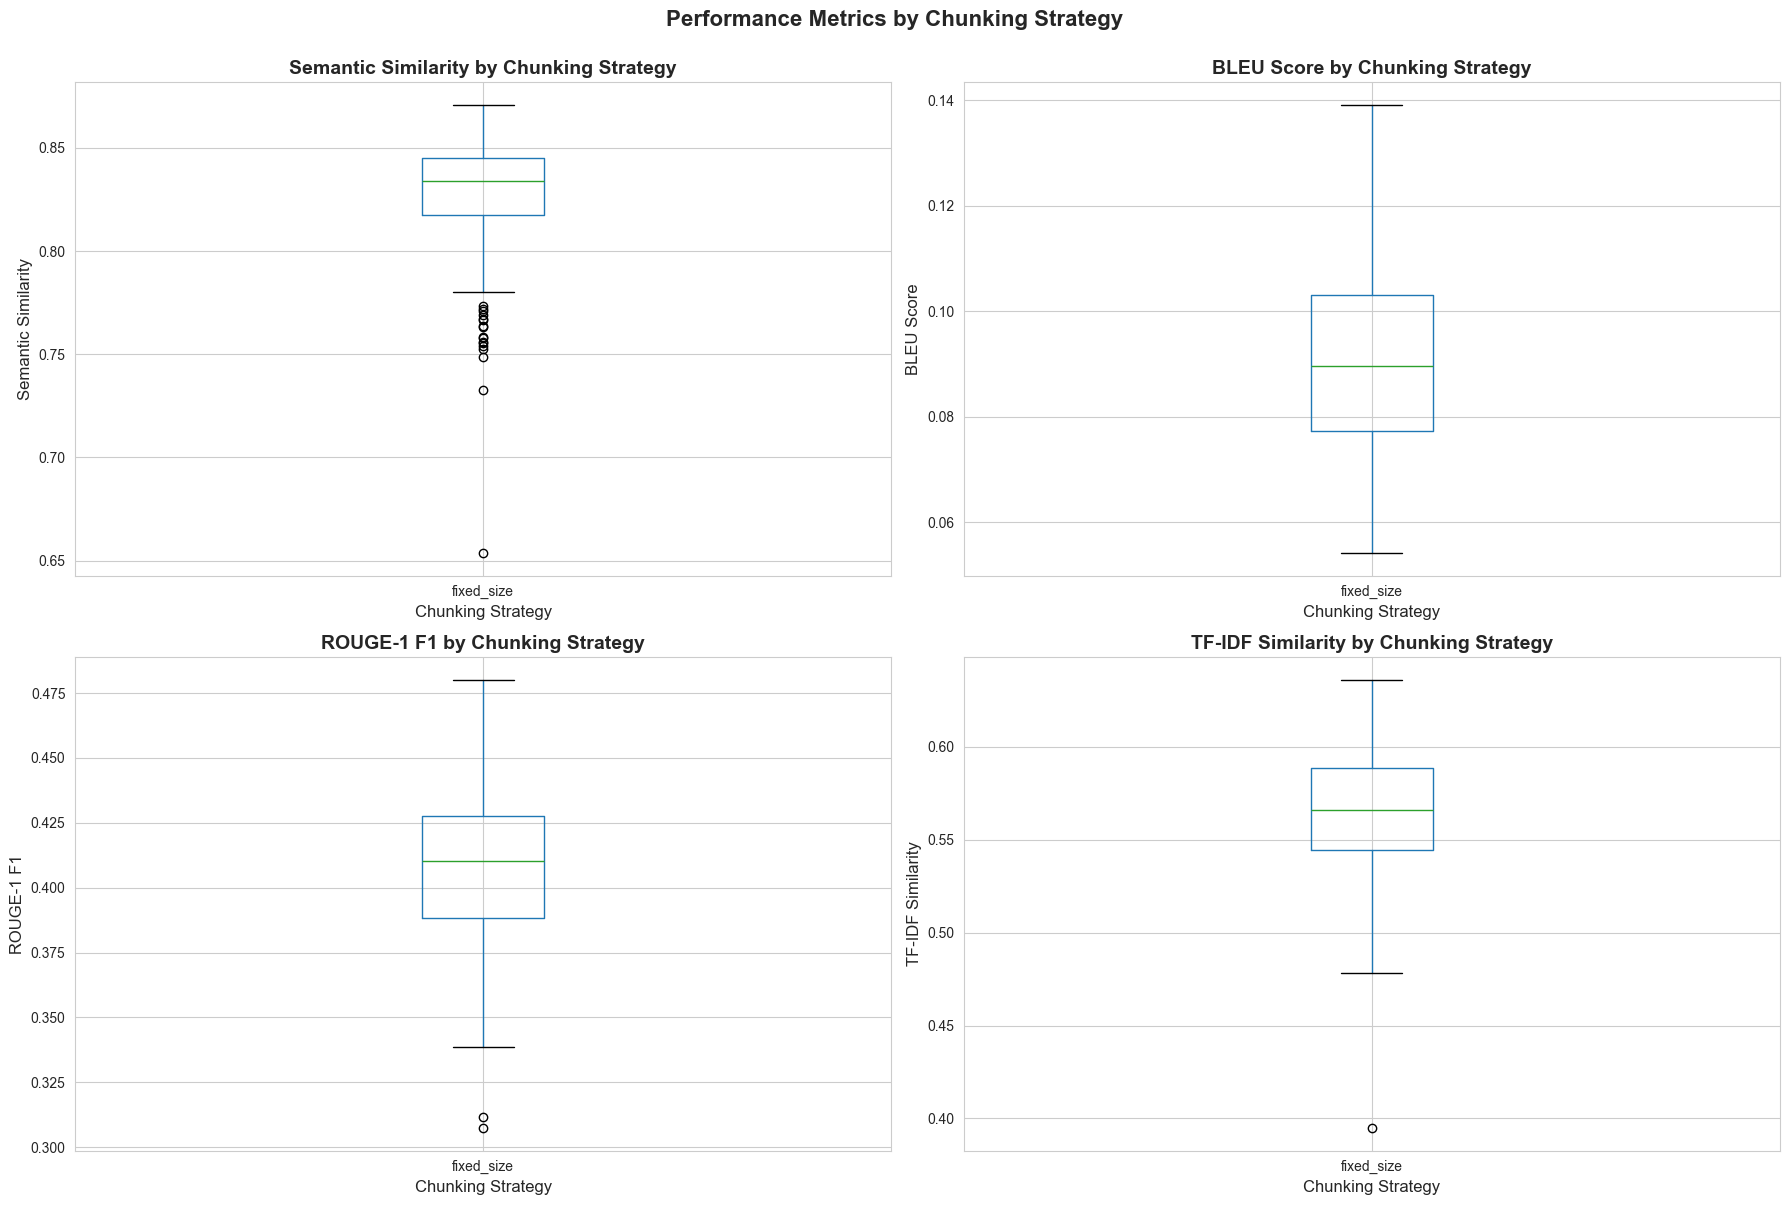

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metrics = [('avg_semantic_similarity', 'Semantic Similarity'), 
           ('avg_bleu_score', 'BLEU Score'),
           ('avg_rouge_1_f', 'ROUGE-1 F1'),
           ('avg_tfidf_similarity', 'TF-IDF Similarity')]

for idx, (metric, label) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    df.boxplot(column=metric, by='chunking_strategy', ax=ax)
    ax.set_title(f'{label} by Chunking Strategy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Chunking Strategy', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    plt.sca(ax)
    plt.xticks(rotation=0)

plt.suptitle('Performance Metrics by Chunking Strategy', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 8.2 Chunk Size Impact

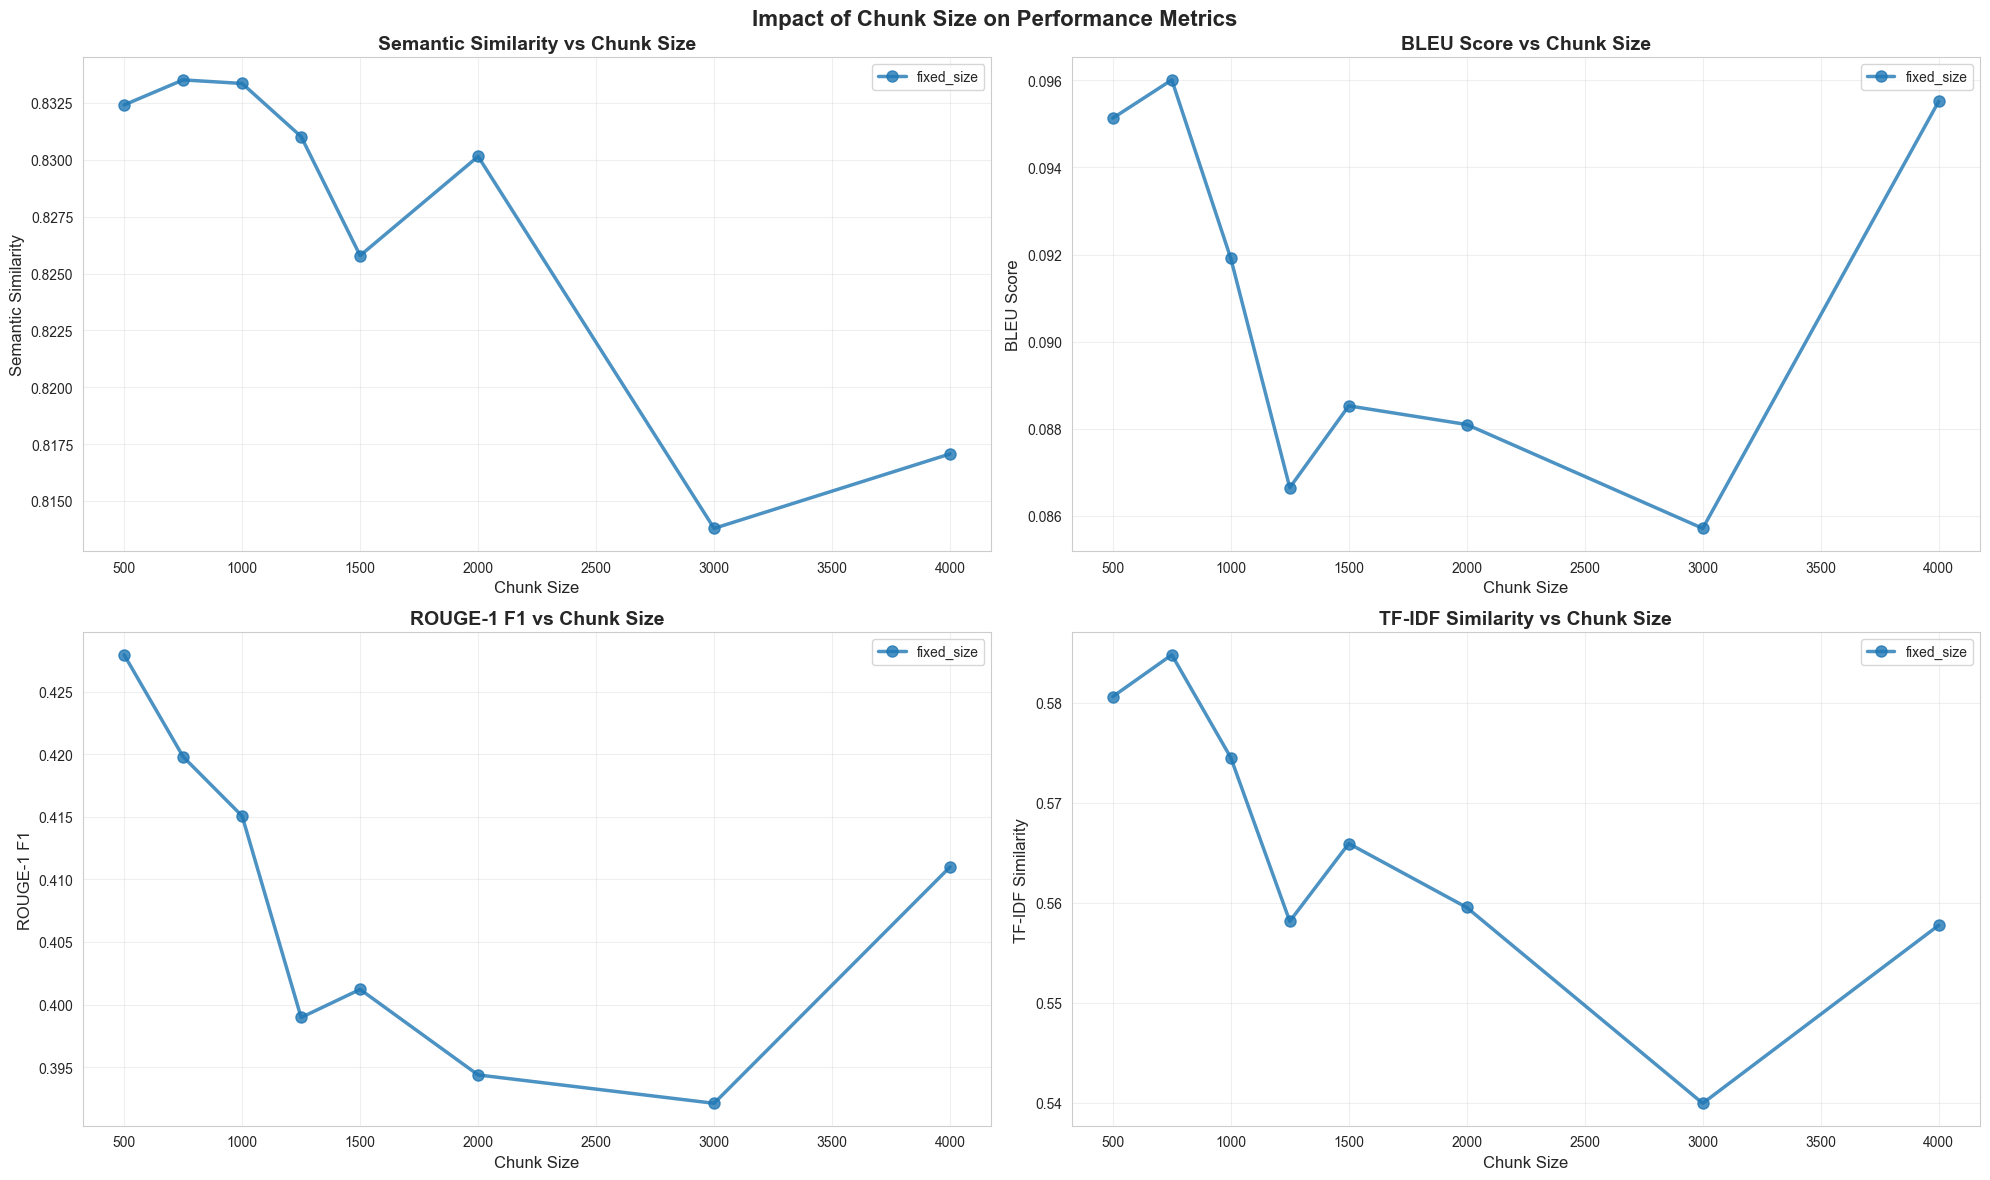

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for idx, (metric, label) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    for strategy in df['chunking_strategy'].unique():
        if pd.notna(strategy):
            strategy_data = df[df['chunking_strategy'] == strategy].groupby('chunk_size')[metric].mean()
            ax.plot(strategy_data.index, strategy_data.values, marker='o', linewidth=2.5, 
                   markersize=8, label=strategy, alpha=0.8)
    
    ax.set_title(f'{label} vs Chunk Size', fontsize=14, fontweight='bold')
    ax.set_xlabel('Chunk Size', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Impact of Chunk Size on Performance Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2b Chunk Size Impact Per Model

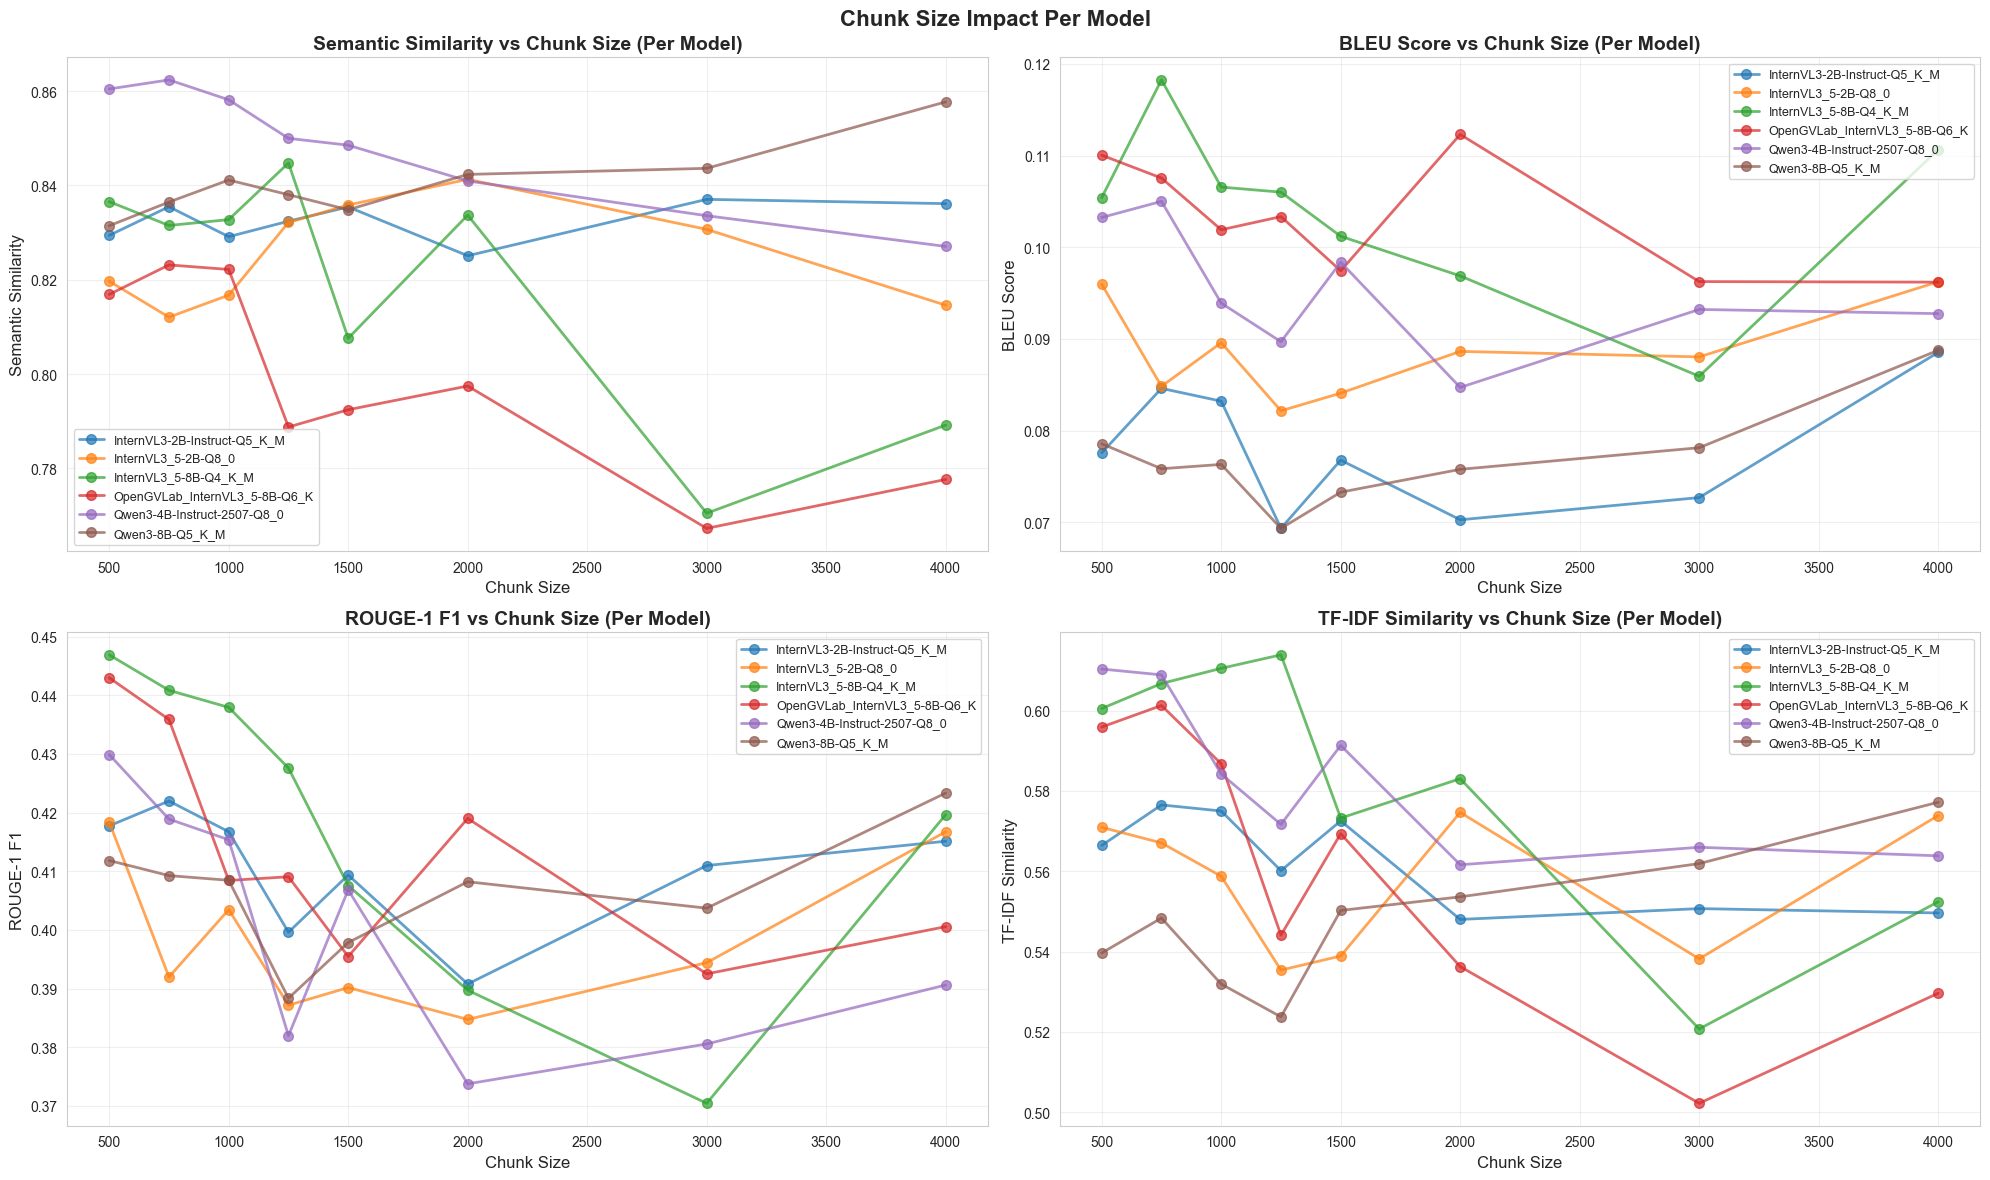

CHUNK SIZE PERFORMANCE BREAKDOWN BY MODEL

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
chunk_size,,,,,
500,0.8294,0.0776,0.4177,2.4911,0.5235
750,0.8355,0.0846,0.4220,3.1137,0.5301
1000,0.8291,0.0832,0.4167,3.4976,0.5260
1250,0.8324,0.0693,0.3996,3.7787,0.5171
1500,0.8354,0.0768,0.4094,4.2785,0.5246
2000,0.8251,0.0703,0.3908,5.4183,0.5101
3000,0.8371,0.0727,0.4110,7.8561,0.5204
4000,0.8361,0.0885,0.4151,14.9405,0.5241


  → Best chunk size: 3000 (semantic similarity: 0.8371)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
chunk_size,,,,,
500,0.8197,0.0960,0.4184,18.6325,0.5249
750,0.8121,0.0848,0.3920,24.4871,0.5126
1000,0.8167,0.0896,0.4035,18.9512,0.5164
1250,0.8321,0.0822,0.3872,25.4895,0.5116
1500,0.8359,0.0841,0.3902,25.7364,0.5147
2000,0.8413,0.0886,0.3847,29.4476,0.5233
3000,0.8307,0.0880,0.3944,28.0248,0.5146
4000,0.8146,0.0962,0.4167,25.1472,0.5233


  → Best chunk size: 2000 (semantic similarity: 0.8413)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best chunk size: 750 (semantic similarity: 0.8232)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
chunk_size,,,,,
500,0.8605,0.1032,0.4299,14.1689,0.5514
750,0.8624,0.1050,0.4189,14.9965,0.5493
1000,0.8582,0.0939,0.4154,15.2368,0.5398
1250,0.8500,0.0897,0.3820,18.7794,0.5253
1500,0.8485,0.0984,0.4068,19.9148,0.5366
2000,0.8410,0.0847,0.3738,23.0496,0.5170
3000,0.8336,0.0932,0.3806,30.6436,0.5187
4000,0.8271,0.0928,0.3906,43.0298,0.5184


  → Best chunk size: 750 (semantic similarity: 0.8624)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
chunk_size,,,,,
500,0.8315,0.0786,0.4118,27.7971,0.5176
750,0.8365,0.0758,0.4093,30.4501,0.5199
1000,0.8412,0.0763,0.4085,34.0780,0.5182
1250,0.8380,0.0693,0.3884,33.7696,0.5090
1500,0.8348,0.0733,0.3979,36.7793,0.5164
2000,0.8423,0.0758,0.4082,41.6717,0.5228
3000,0.8436,0.0781,0.4037,56.0877,0.5242
4000,0.8577,0.0888,0.4233,68.8077,0.5392


  → Best chunk size: 4000 (semantic similarity: 0.8577)


In [16]:
# Create individual plots for each model showing chunk size impact
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for idx, (metric, label) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Plot each model separately
    for model in sorted(df['model_name'].dropna().unique()):
        model_data = df[df['model_name'] == model].groupby('chunk_size')[metric].mean()
        if len(model_data) > 0:
            ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                   markersize=7, label=model, alpha=0.7)
    
    ax.set_title(f'{label} vs Chunk Size (Per Model)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Chunk Size', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Chunk Size Impact Per Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional detailed breakdown by model
print("=" * 100)
print("CHUNK SIZE PERFORMANCE BREAKDOWN BY MODEL")
print("=" * 100)

for model in sorted(df['model_name'].dropna().unique()):
    model_data = df[df['model_name'] == model].groupby('chunk_size').agg({
        'avg_semantic_similarity': 'mean',
        'avg_bleu_score': 'mean',
        'avg_rouge_1_f': 'mean',
        'avg_response_time': 'mean',
        'composite_score': 'mean',
    }).round(4)
    
    if len(model_data) > 0:
        print(f"\n{model}:")
        print("-" * 100)
        display(model_data)
        
        # Identify best chunk size for this model
        best_chunk = model_data['avg_semantic_similarity'].idxmax()
        best_score = model_data.loc[best_chunk, 'avg_semantic_similarity']
        print(f"  → Best chunk size: {int(best_chunk)} (semantic similarity: {best_score:.4f})")

### 8.3 Overlap Analysis (Fixed Size Only)

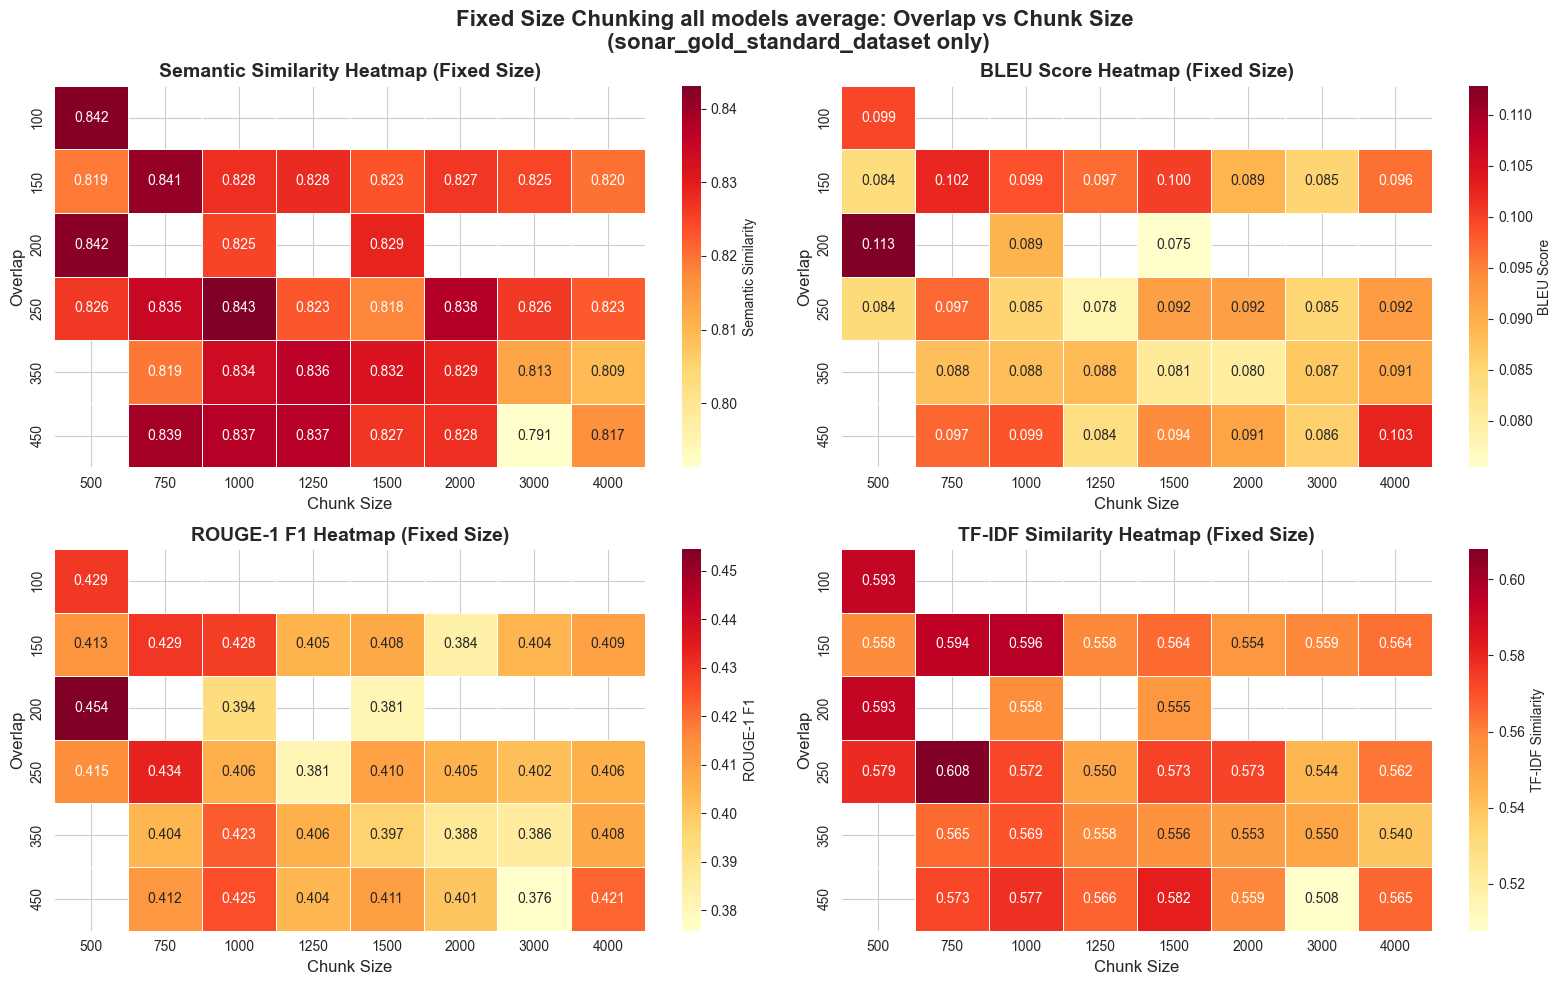

In [ ]:
if len(fixed_size_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Create heatmap data
        pivot_data = fixed_size_df.pivot_table(
            values=metric, 
            index='overlap', 
            columns='chunk_size', 
            aggfunc='mean'
        )
        
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, 
                   cbar_kws={'label': label}, linewidths=0.5)
        ax.set_title(f'{label} Heatmap (Fixed Size)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Chunk Size', fontsize=12)
        ax.set_ylabel('Overlap', fontsize=12)
    
    plt.suptitle('Fixed Size Chunking all models average: Overlap vs Chunk Size\n (sonar_gold_standard_dataset only, top_k=20)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No fixed_size data available for overlap analysis")

### 8.4 Model Performance Comparison

### 8.3b Overlap Analysis Per Model (Fixed Size Only)

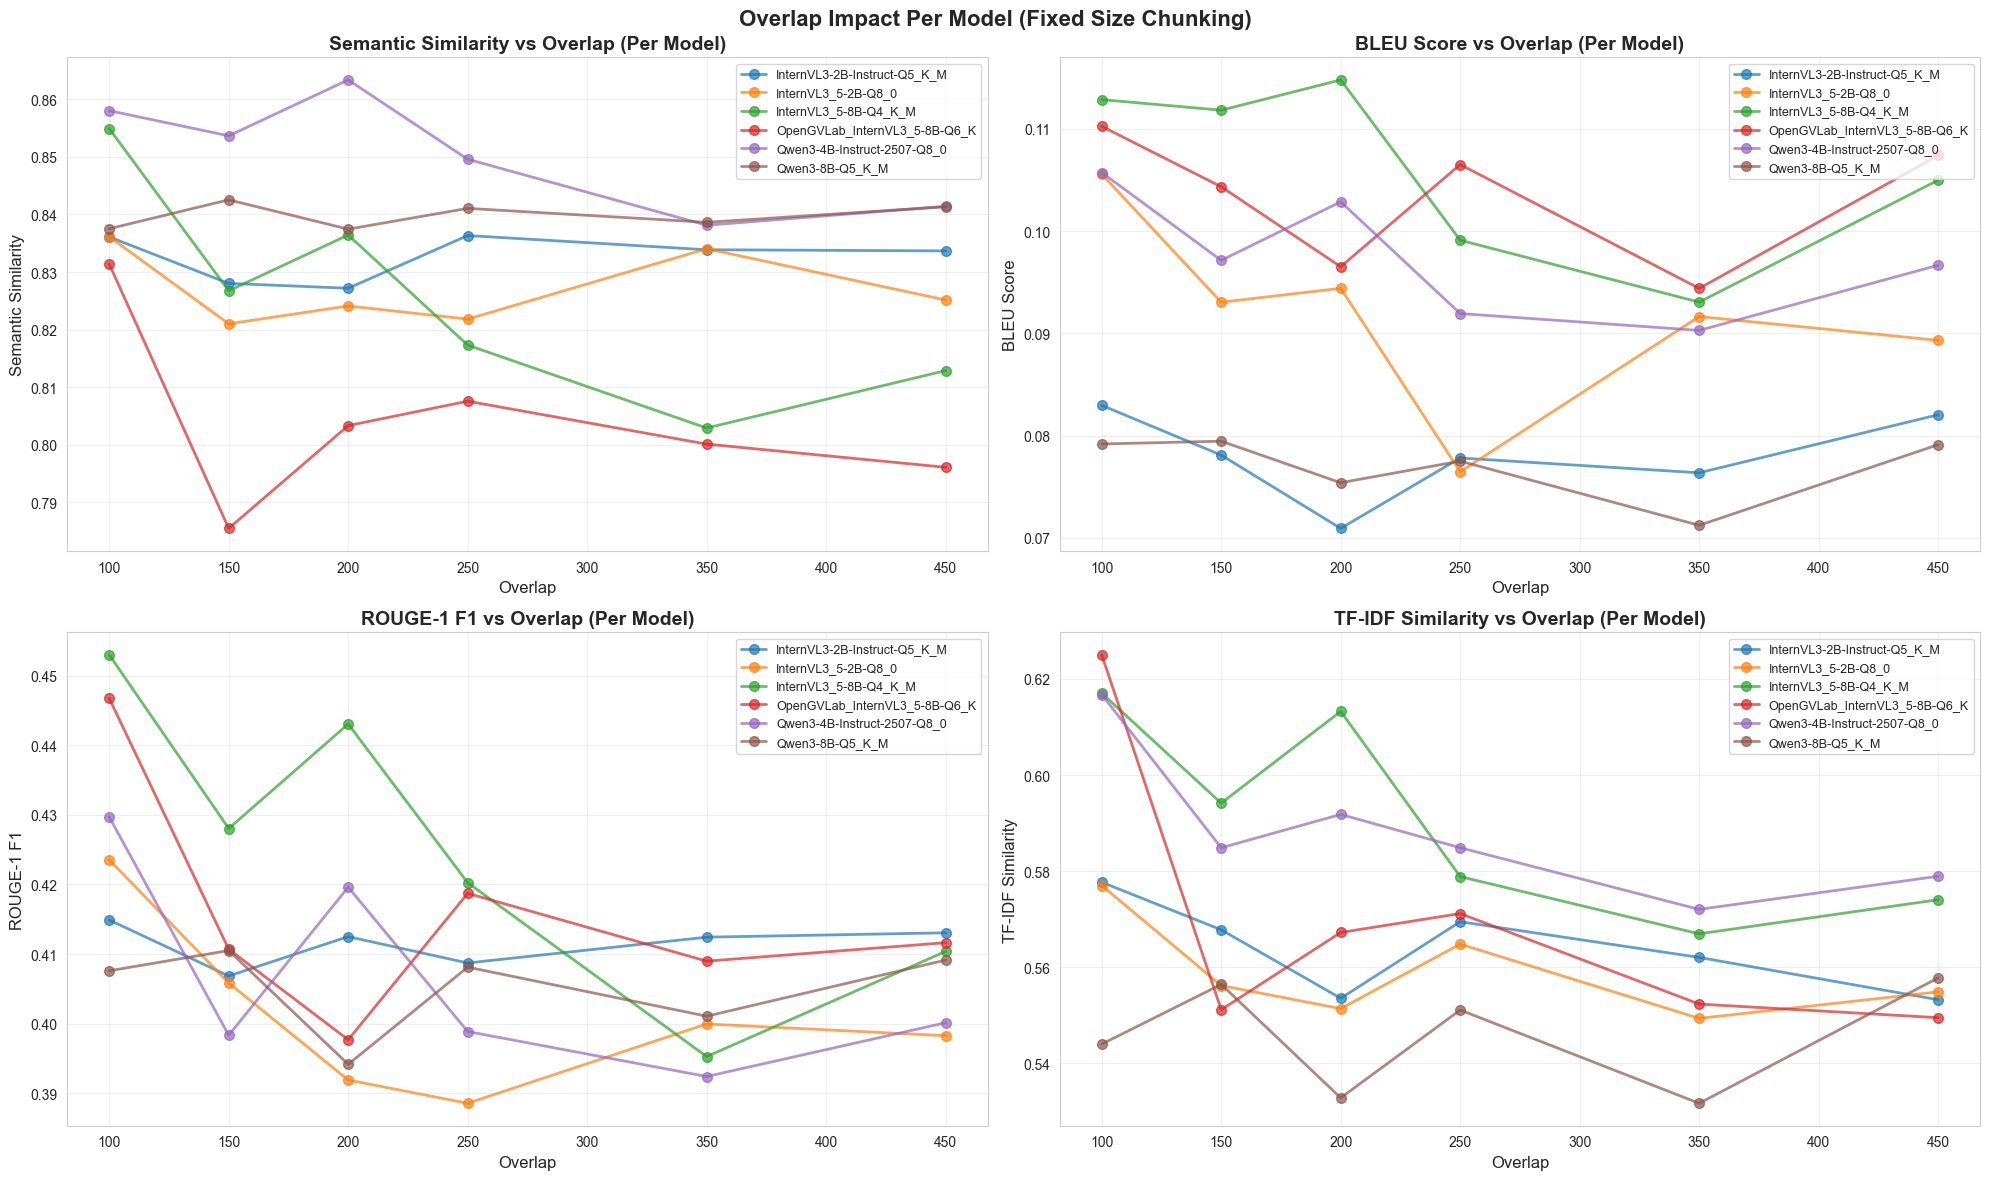

OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.0830,0.4149,2.3411,0.5285
150,0.8280,0.0781,0.4068,5.2790,0.5207
200,0.8272,0.0709,0.4125,3.2537,0.5175
250,0.8363,0.0778,0.4087,5.2131,0.5244
350,0.8339,0.0764,0.4124,7.7174,0.5226
450,0.8337,0.0820,0.4130,5.6018,0.5221


  → Best overlap: 250 (semantic similarity: 0.8363)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.1056,0.4235,20.0759,0.5350
150,0.8210,0.0931,0.4058,25.2365,0.5187
200,0.8241,0.0944,0.3919,23.2848,0.5156
250,0.8218,0.0765,0.3885,21.1609,0.5130
350,0.8340,0.0916,0.3999,27.1612,0.5201
450,0.8251,0.0893,0.3983,25.3022,0.5172


  → Best overlap: 100 (semantic similarity: 0.8361)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best overlap: 100 (semantic similarity: 0.8314)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8580,0.1057,0.4297,15.0055,0.5522
150,0.8537,0.0971,0.3983,22.4582,0.5348
200,0.8634,0.1029,0.4196,16.0236,0.5460
250,0.8496,0.0919,0.3989,22.8116,0.5324
350,0.8381,0.0903,0.3924,23.2279,0.5239
450,0.8414,0.0967,0.4001,23.7999,0.5297


  → Best overlap: 200 (semantic similarity: 0.8634)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8375,0.0792,0.4076,28.8969,0.5197
150,0.8425,0.0795,0.4105,42.1161,0.5247
200,0.8375,0.0754,0.3942,32.4753,0.5133
250,0.8411,0.0775,0.4081,41.1525,0.5221
350,0.8386,0.0712,0.4011,42.3231,0.5144
450,0.8413,0.0791,0.4091,42.8413,0.5241


  → Best overlap: 150 (semantic similarity: 0.8425)

OVERLAP × CHUNK SIZE HEATMAPS PER MODEL


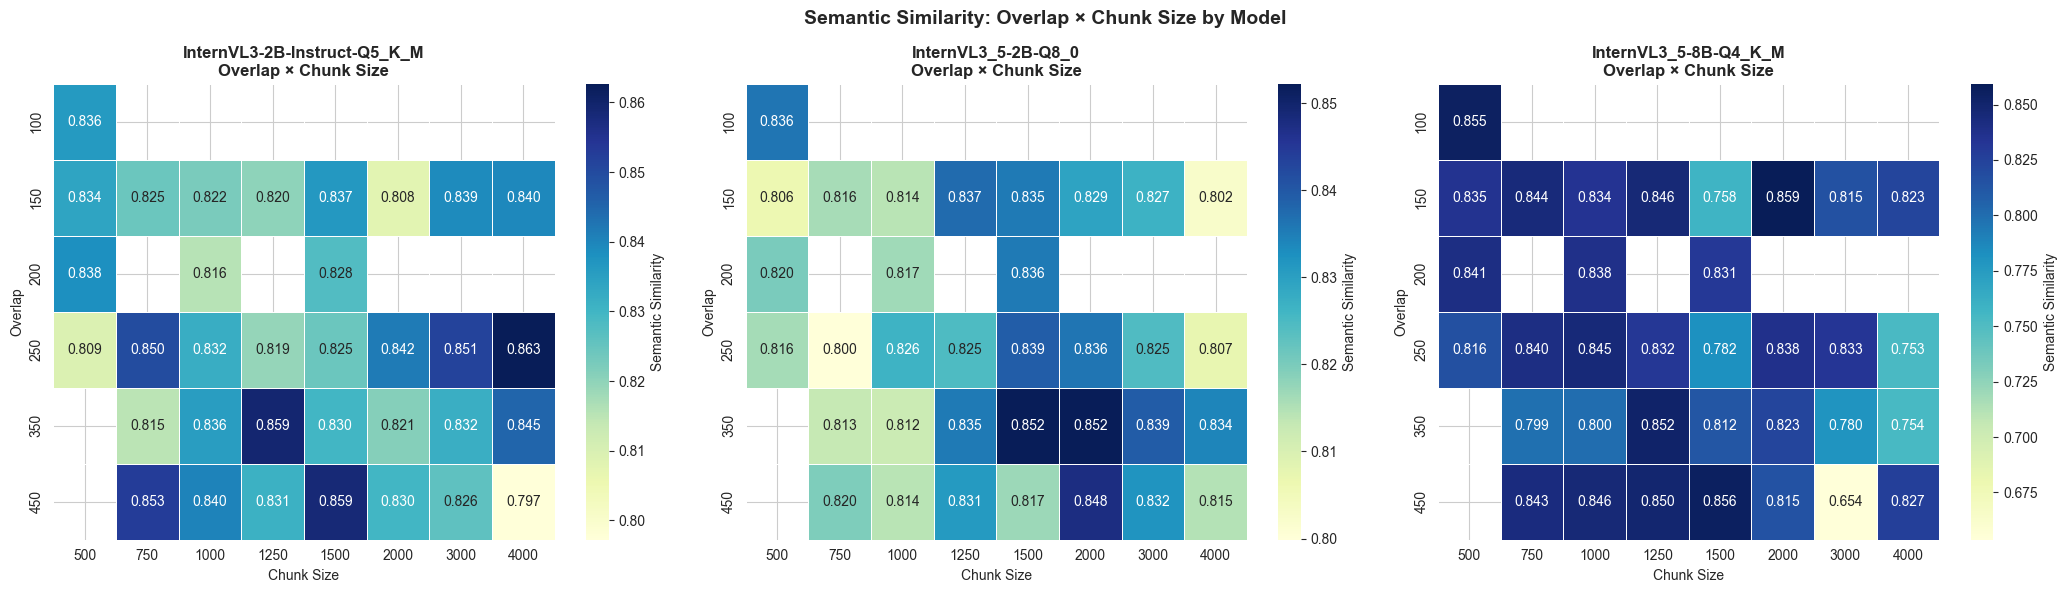

In [18]:
if len(fixed_size_df) > 0:
    # Create individual plots for each model showing overlap impact
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Plot each model separately
        for model in sorted(fixed_size_df['model_name'].dropna().unique()):
            model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap')[metric].mean()
            if len(model_data) > 0:
                ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                       markersize=7, label=model, alpha=0.7)
        
        ax.set_title(f'{label} vs Overlap (Per Model)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model (Fixed Size Chunking)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed breakdown by model and overlap
    print("=" * 100)
    print("OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)")
    print("=" * 100)
    
    for model in sorted(fixed_size_df['model_name'].dropna().unique()):
        model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean',
            'avg_response_time': 'mean',
            'composite_score': 'mean',
        }).round(4)
        
        if len(model_data) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(model_data)
            
            # Identify best overlap for this model
            best_overlap = model_data['avg_semantic_similarity'].idxmax()
            best_score = model_data.loc[best_overlap, 'avg_semantic_similarity']
            print(f"  → Best overlap: {int(best_overlap)} (semantic similarity: {best_score:.4f})")
    
    # Heatmap per model showing overlap vs chunk_size interaction
    print("\n" + "=" * 100)
    print("OVERLAP × CHUNK SIZE HEATMAPS PER MODEL")
    print("=" * 100)
    
    num_models = fixed_size_df['model_name'].nunique()
    fig, axes = plt.subplots(1, min(num_models, 3), figsize=(7*min(num_models, 3), 6))
    if num_models == 1:
        axes = [axes]
    
    for idx, model in enumerate(sorted(fixed_size_df['model_name'].dropna().unique())[:3]):  # Limit to 3 models for display
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        pivot_data = model_df.pivot_table(
            values='avg_semantic_similarity',
            index='overlap',
            columns='chunk_size',
            aggfunc='mean'
        )
        
        ax = axes[idx] if num_models > 1 else axes[0]
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                   cbar_kws={'label': 'Semantic Similarity'}, linewidths=0.5)
        ax.set_title(f'{model}\nOverlap × Chunk Size', fontsize=12, fontweight='bold')
        ax.set_xlabel('Chunk Size', fontsize=10)
        ax.set_ylabel('Overlap', fontsize=10)
    
    plt.suptitle('Semantic Similarity: Overlap × Chunk Size by Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("No fixed_size data available for overlap analysis per model")

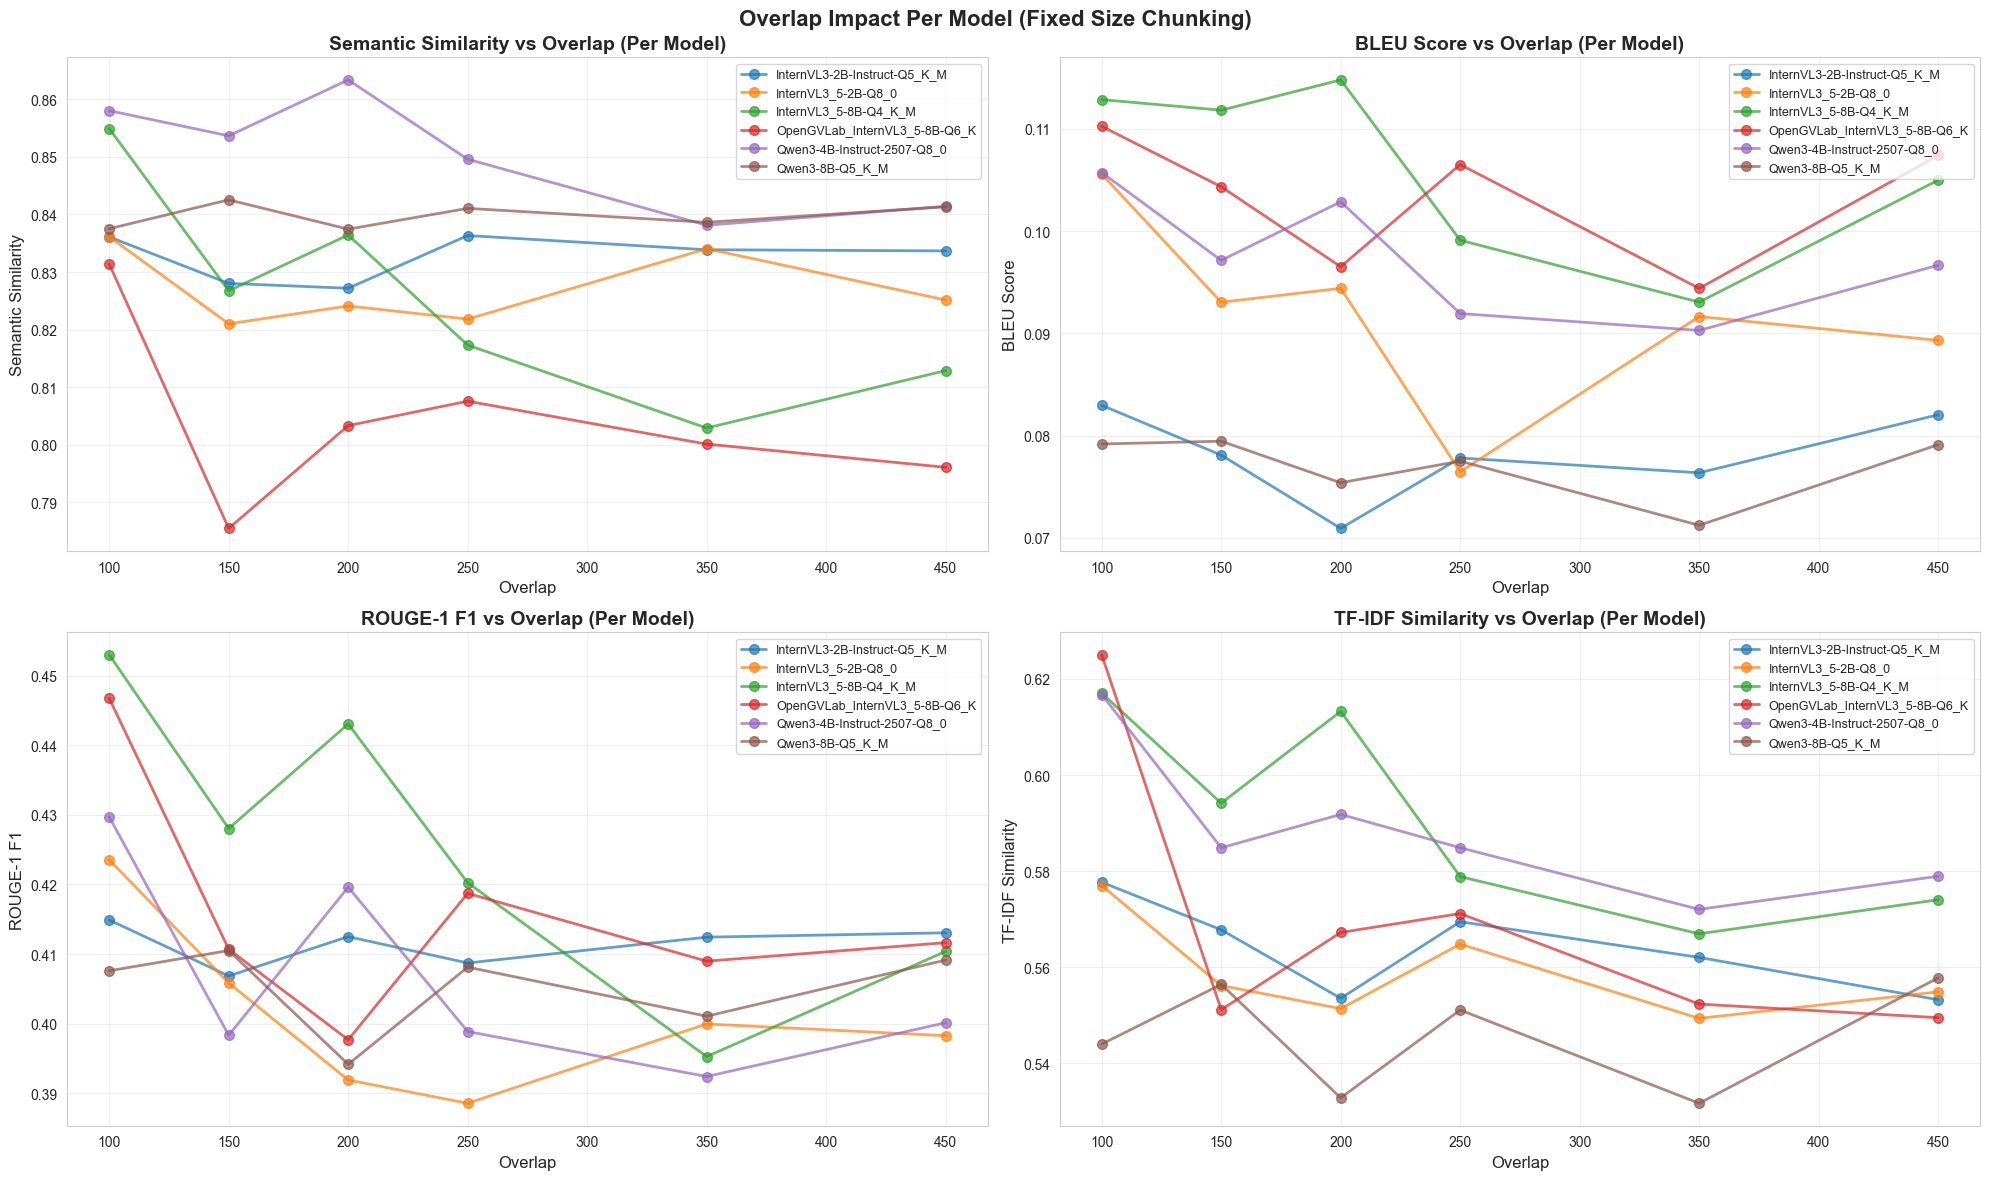

OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.0830,0.4149,2.3411,0.5285
150,0.8280,0.0781,0.4068,5.2790,0.5207
200,0.8272,0.0709,0.4125,3.2537,0.5175
250,0.8363,0.0778,0.4087,5.2131,0.5244
350,0.8339,0.0764,0.4124,7.7174,0.5226
450,0.8337,0.0820,0.4130,5.6018,0.5221


  → Best overlap: 250 (semantic similarity: 0.8363)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.1056,0.4235,20.0759,0.5350
150,0.8210,0.0931,0.4058,25.2365,0.5187
200,0.8241,0.0944,0.3919,23.2848,0.5156
250,0.8218,0.0765,0.3885,21.1609,0.5130
350,0.8340,0.0916,0.3999,27.1612,0.5201
450,0.8251,0.0893,0.3983,25.3022,0.5172


  → Best overlap: 100 (semantic similarity: 0.8361)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best overlap: 100 (semantic similarity: 0.8314)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8580,0.1057,0.4297,15.0055,0.5522
150,0.8537,0.0971,0.3983,22.4582,0.5348
200,0.8634,0.1029,0.4196,16.0236,0.5460
250,0.8496,0.0919,0.3989,22.8116,0.5324
350,0.8381,0.0903,0.3924,23.2279,0.5239
450,0.8414,0.0967,0.4001,23.7999,0.5297


  → Best overlap: 200 (semantic similarity: 0.8634)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8375,0.0792,0.4076,28.8969,0.5197
150,0.8425,0.0795,0.4105,42.1161,0.5247
200,0.8375,0.0754,0.3942,32.4753,0.5133
250,0.8411,0.0775,0.4081,41.1525,0.5221
350,0.8386,0.0712,0.4011,42.3231,0.5144
450,0.8413,0.0791,0.4091,42.8413,0.5241


  → Best overlap: 150 (semantic similarity: 0.8425)

OVERLAP × CHUNK SIZE HEATMAPS PER MODEL


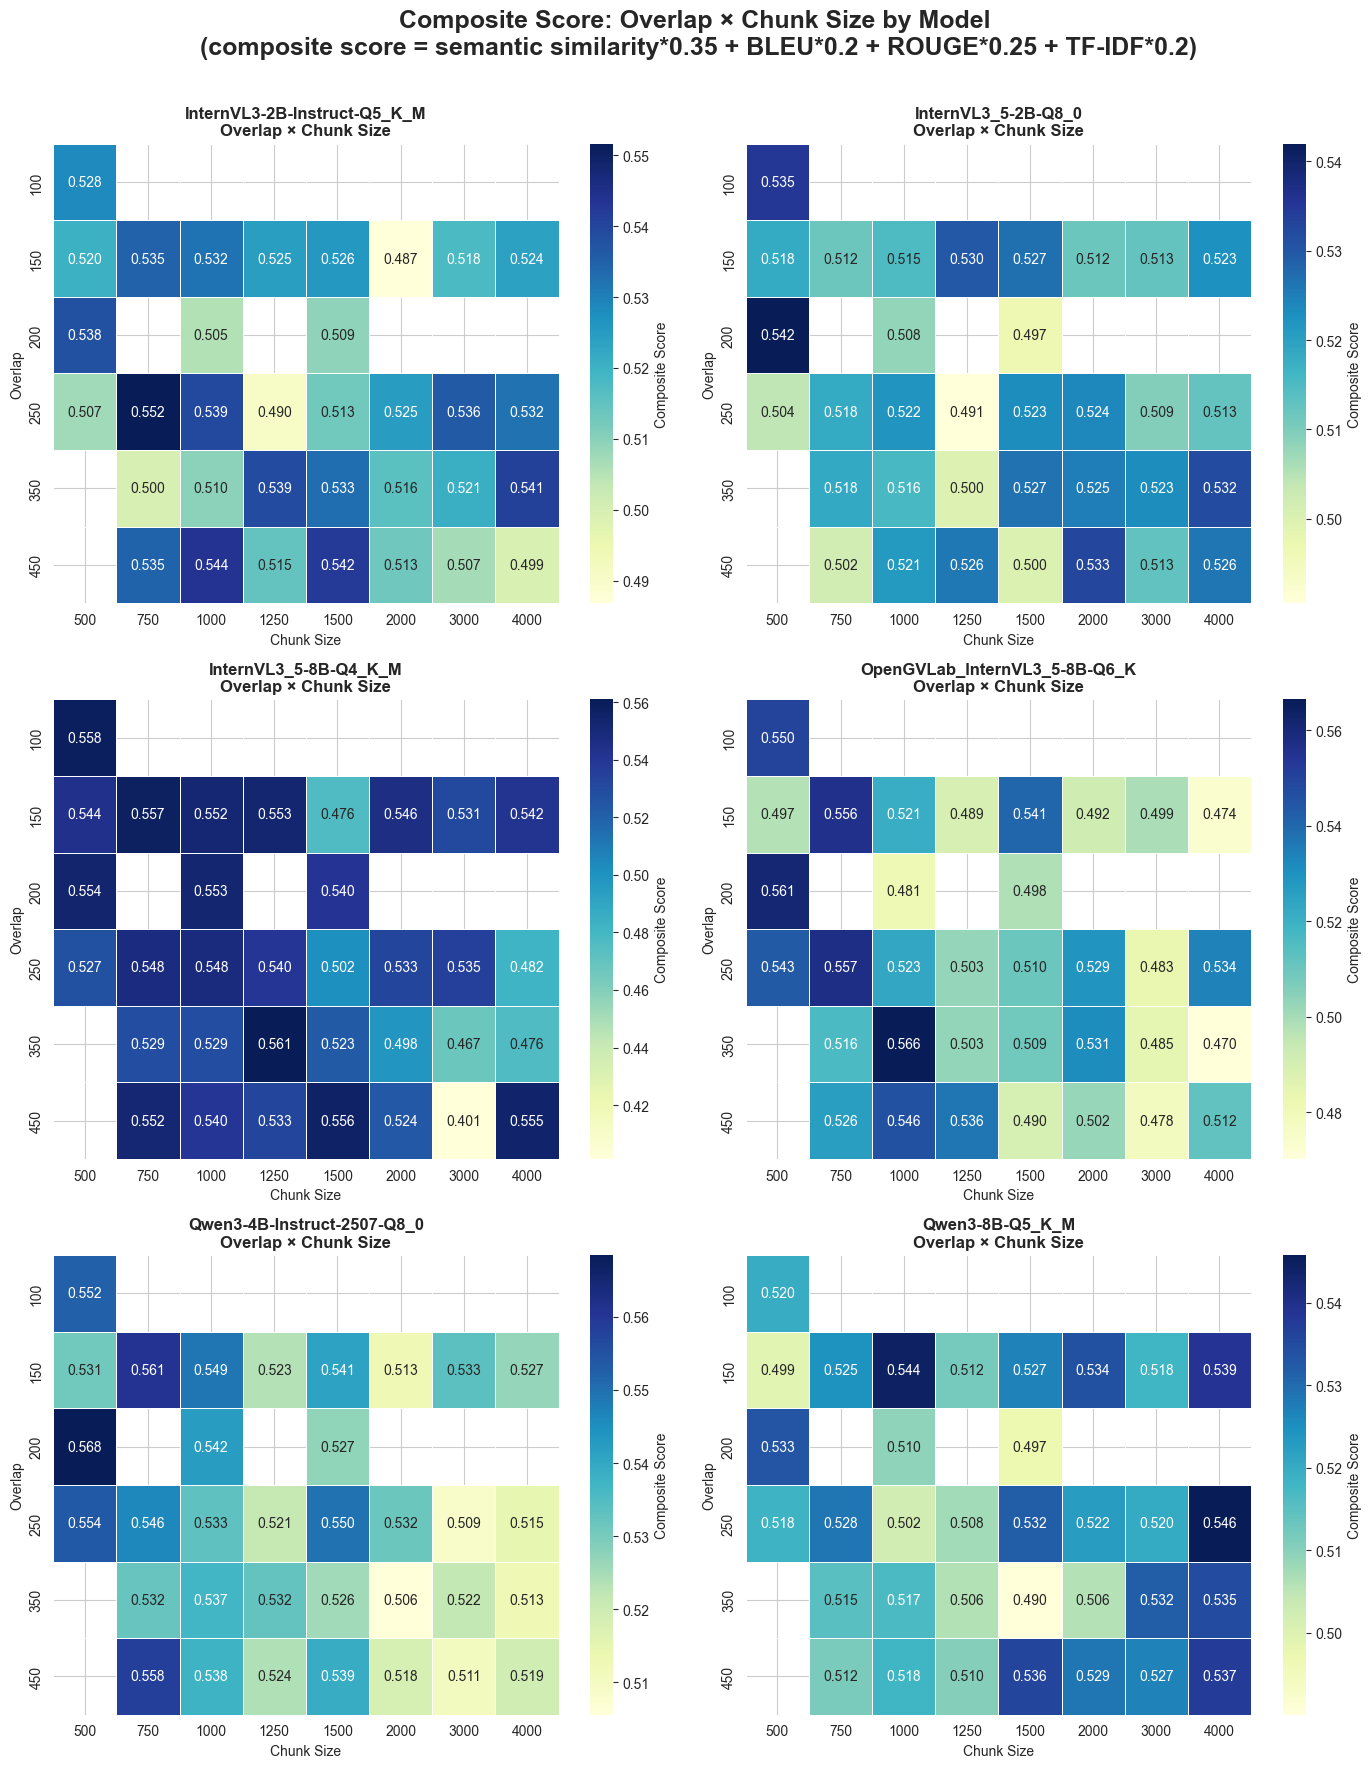

In [19]:
if len(fixed_size_df) > 0:
    # Create individual plots for each model showing overlap impact
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Plot each model separately
        for model in sorted(fixed_size_df['model_name'].dropna().unique()):
            model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap')[metric].mean()
            if len(model_data) > 0:
                ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                       markersize=7, label=model, alpha=0.7)
        
        ax.set_title(f'{label} vs Overlap (Per Model)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model (Fixed Size Chunking)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed breakdown by model and overlap
    print("=" * 100)
    print("OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)")
    print("=" * 100)
    
    for model in sorted(fixed_size_df['model_name'].dropna().unique()):
        model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean',
            'avg_response_time': 'mean',
            'composite_score': 'mean',
        }).round(4)
        
        if len(model_data) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(model_data)
            
            # Identify best overlap for this model
            best_overlap = model_data['avg_semantic_similarity'].idxmax()
            best_score = model_data.loc[best_overlap, 'avg_semantic_similarity']
            print(f"  → Best overlap: {int(best_overlap)} (semantic similarity: {best_score:.4f})")
    
    # Heatmap per model showing overlap vs chunk_size interaction
    print("\n" + "=" * 100)
    print("OVERLAP × CHUNK SIZE HEATMAPS PER MODEL")
    print("=" * 100)
    
    # Calculate optimal grid layout for all models
    num_models = fixed_size_df['model_name'].nunique()
    import math
    ncols = min(2, num_models)  # Max 2 columns for readability
    nrows = math.ceil(num_models / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
    
    # Flatten axes array for easy iteration
    if num_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else axes
    
    for idx, model in enumerate(sorted(fixed_size_df['model_name'].dropna().unique())):
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        pivot_data = model_df.pivot_table(
            values='composite_score',
            index='overlap',
            columns='chunk_size',
            aggfunc='mean'
        )
        
        ax = axes[idx]
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                   cbar_kws={'label': 'Composite Score'}, linewidths=0.5)
        ax.set_title(f'{model}\nOverlap × Chunk Size', fontsize=12, fontweight='bold')
        ax.set_xlabel('Chunk Size', fontsize=10)
        ax.set_ylabel('Overlap', fontsize=10)
    
    # Hide any unused subplots
    for idx in range(num_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Composite Score: Overlap × Chunk Size by Model\n (composite score = semantic similarity*0.35 + BLEU*0.2 + ROUGE*0.25 + TF-IDF*0.2)\n\n', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("No fixed_size data available for overlap analysis per model")


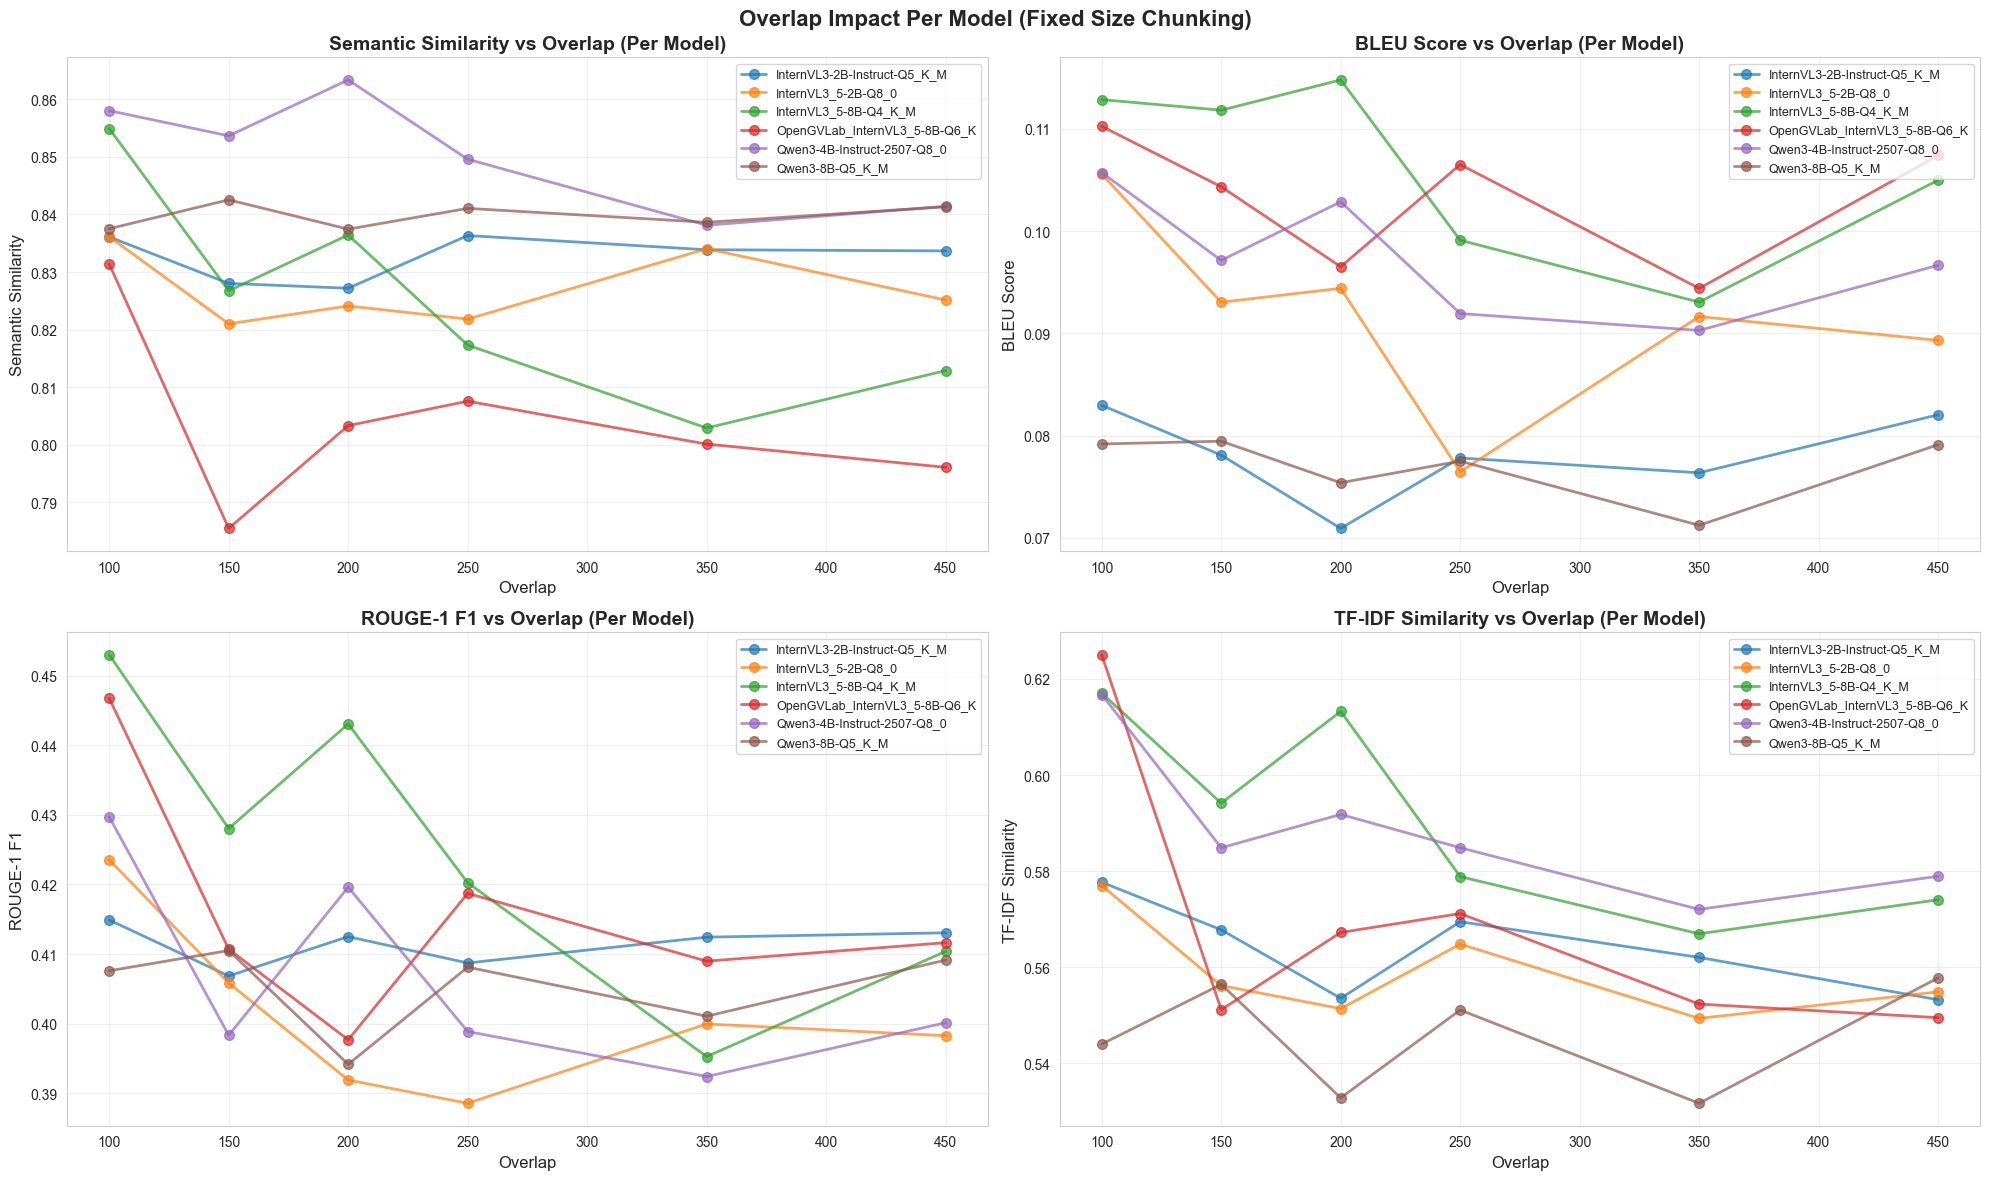

OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.0830,0.4149,2.3411,0.5285
150,0.8280,0.0781,0.4068,5.2790,0.5207
200,0.8272,0.0709,0.4125,3.2537,0.5175
250,0.8363,0.0778,0.4087,5.2131,0.5244
350,0.8339,0.0764,0.4124,7.7174,0.5226
450,0.8337,0.0820,0.4130,5.6018,0.5221


  → Best overlap: 250 (semantic similarity: 0.8363)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.1056,0.4235,20.0759,0.5350
150,0.8210,0.0931,0.4058,25.2365,0.5187
200,0.8241,0.0944,0.3919,23.2848,0.5156
250,0.8218,0.0765,0.3885,21.1609,0.5130
350,0.8340,0.0916,0.3999,27.1612,0.5201
450,0.8251,0.0893,0.3983,25.3022,0.5172


  → Best overlap: 100 (semantic similarity: 0.8361)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best overlap: 100 (semantic similarity: 0.8314)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8580,0.1057,0.4297,15.0055,0.5522
150,0.8537,0.0971,0.3983,22.4582,0.5348
200,0.8634,0.1029,0.4196,16.0236,0.5460
250,0.8496,0.0919,0.3989,22.8116,0.5324
350,0.8381,0.0903,0.3924,23.2279,0.5239
450,0.8414,0.0967,0.4001,23.7999,0.5297


  → Best overlap: 200 (semantic similarity: 0.8634)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8375,0.0792,0.4076,28.8969,0.5197
150,0.8425,0.0795,0.4105,42.1161,0.5247
200,0.8375,0.0754,0.3942,32.4753,0.5133
250,0.8411,0.0775,0.4081,41.1525,0.5221
350,0.8386,0.0712,0.4011,42.3231,0.5144
450,0.8413,0.0791,0.4091,42.8413,0.5241


  → Best overlap: 150 (semantic similarity: 0.8425)

OVERLAP × CHUNK SIZE HEATMAPS PER MODEL


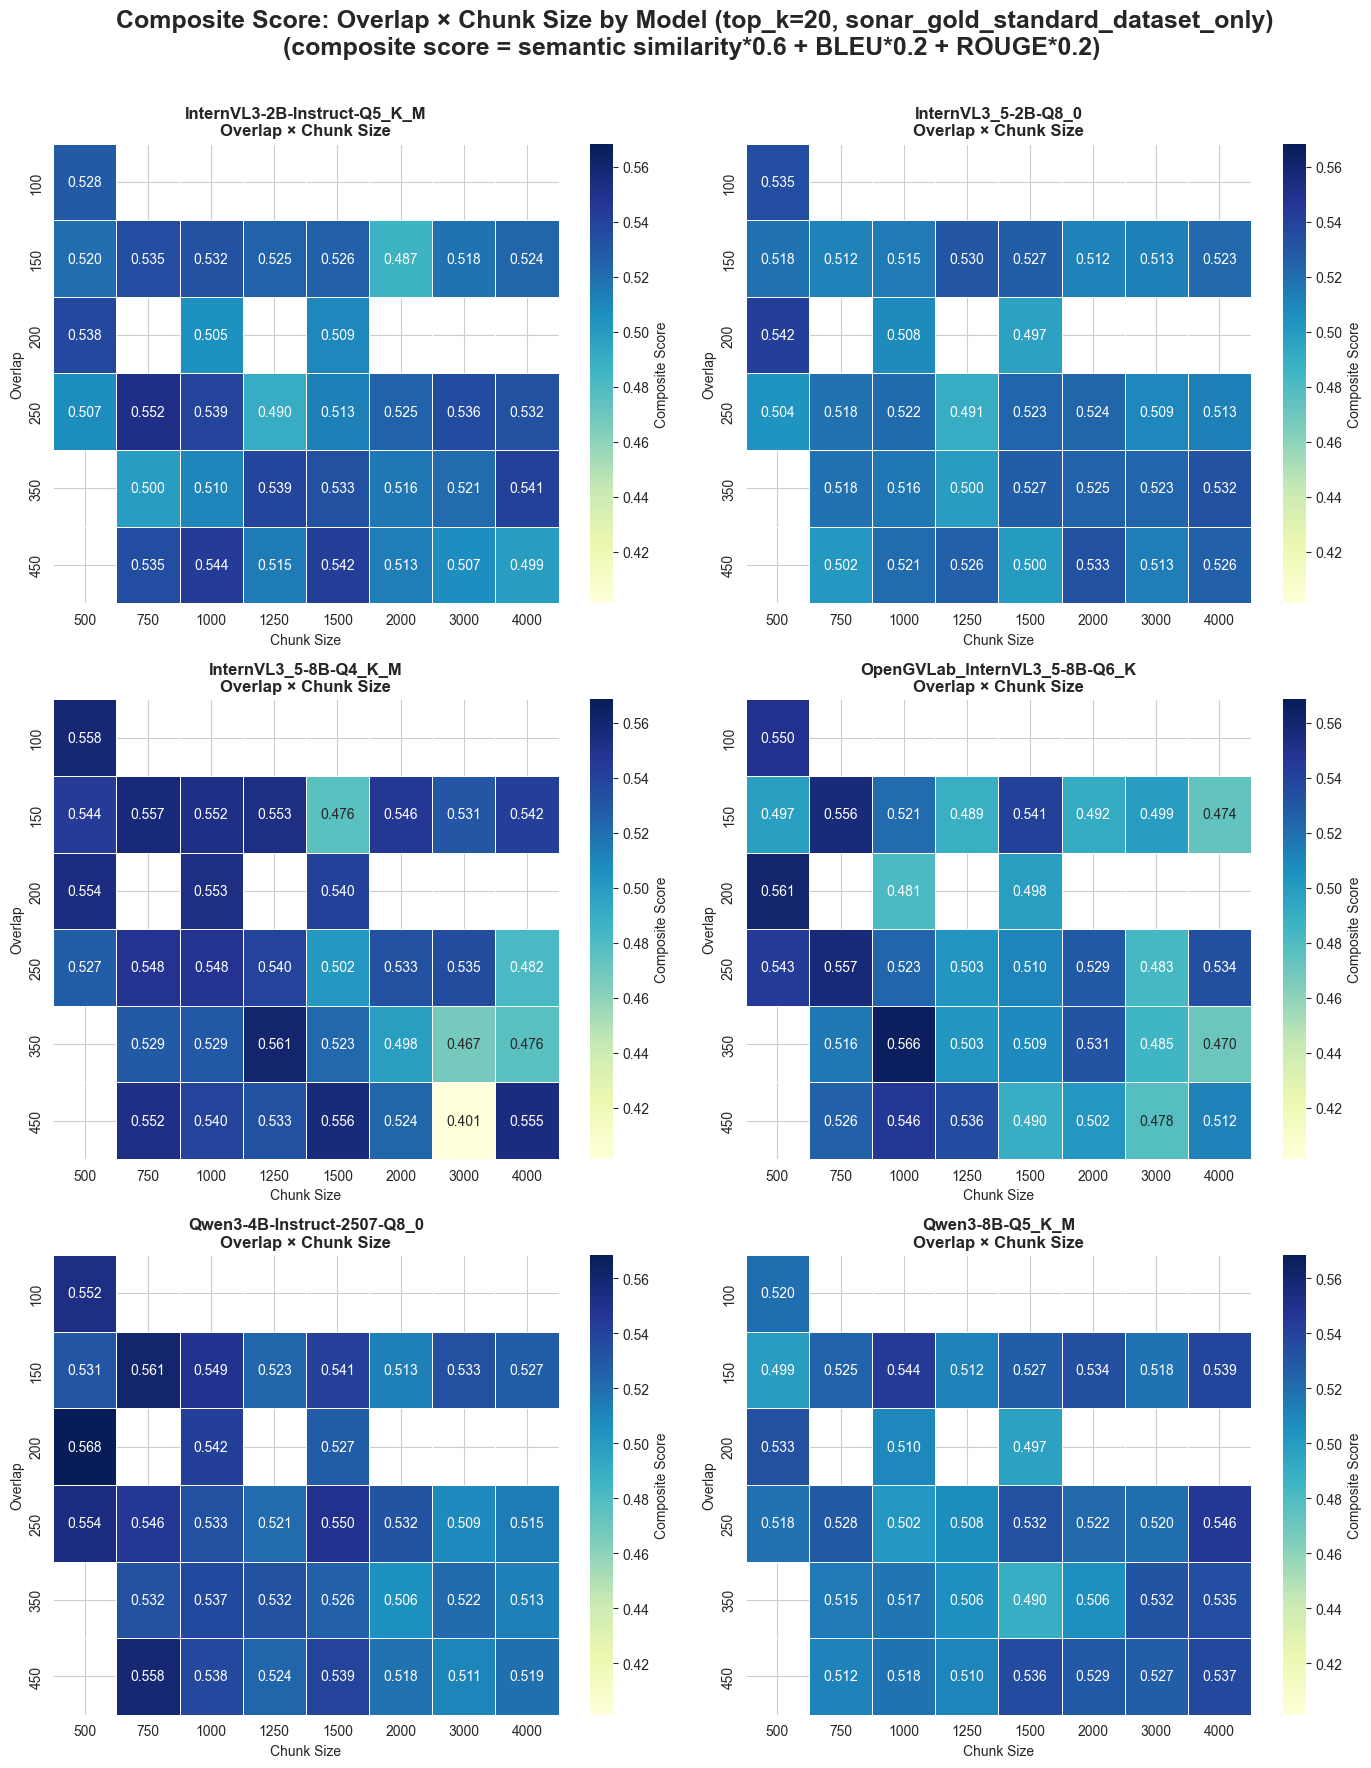

In [20]:
if len(fixed_size_df) > 0:
    # Create individual plots for each model showing overlap impact
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Plot each model separately
        for model in sorted(fixed_size_df['model_name'].dropna().unique()):
            model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap')[metric].mean()
            if len(model_data) > 0:
                ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                       markersize=7, label=model, alpha=0.7)
        
        ax.set_title(f'{label} vs Overlap (Per Model)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model (Fixed Size Chunking)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed breakdown by model and overlap
    print("=" * 100)
    print("OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)")
    print("=" * 100)
    
    for model in sorted(fixed_size_df['model_name'].dropna().unique()):
        model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean',
            'avg_response_time': 'mean',
            'composite_score': 'mean',
        }).round(4)
        
        if len(model_data) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(model_data)
            
            # Identify best overlap for this model
            best_overlap = model_data['avg_semantic_similarity'].idxmax()
            best_score = model_data.loc[best_overlap, 'avg_semantic_similarity']
            print(f"  → Best overlap: {int(best_overlap)} (semantic similarity: {best_score:.4f})")
    
    # Heatmap per model showing overlap vs chunk_size interaction
    print("\n" + "=" * 100)
    print("OVERLAP × CHUNK SIZE HEATMAPS PER MODEL")
    print("=" * 100)
    
    # Calculate optimal grid layout for all models
    num_models = fixed_size_df['model_name'].nunique()
    import math
    ncols = min(2, num_models)  # Max 2 columns for readability
    nrows = math.ceil(num_models / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
    
    # Flatten axes array for easy iteration
    if num_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else axes
    
    # Calculate global min and max for consistent scale
global_min = fixed_size_df['composite_score'].min()
global_max = fixed_size_df['composite_score'].max()

for idx, model in enumerate(sorted(fixed_size_df['model_name'].dropna().unique())):
    model_df = fixed_size_df[fixed_size_df['model_name'] == model]
    pivot_data = model_df.pivot_table(
        values='composite_score',
        index='overlap',
        columns='chunk_size',
        aggfunc='mean'
    )
    
    ax = axes[idx]
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
               cbar_kws={'label': 'Composite Score'}, linewidths=0.5,
               vmin=global_min, vmax=global_max)  # Added these parameters
    ax.set_title(f'{model}\nOverlap × Chunk Size', fontsize=12, fontweight='bold')
    ax.set_xlabel('Chunk Size', fontsize=10)
    ax.set_ylabel('Overlap', fontsize=10)

# Hide any unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Composite Score: Overlap × Chunk Size by Model (top_k=20, sonar_gold_standard_dataset_only)\n (composite score = semantic similarity*0.6 + BLEU*0.2 + ROUGE*0.2)  \n\n', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()



In [21]:
fixed_size_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 204 non-null    object 
 1   db_type                  204 non-null    object 
 2   chunking_strategy        204 non-null    object 
 3   embedding_model          204 non-null    object 
 4   embed_dimension          204 non-null    int64  
 5   chunk_size               204 non-null    int64  
 6   overlap                  204 non-null    int64  
 7   model_name               204 non-null    object 
 8   timestamp                204 non-null    object 
 9   total_questions          204 non-null    int64  
 10  avg_semantic_similarity  204 non-null    float64
 11  avg_bleu_score           204 non-null    float64
 12  avg_rouge_1_f            204 non-null    float64
 13  avg_rouge_2_f            204 non-null    float64
 14  avg_rouge_l_f            2

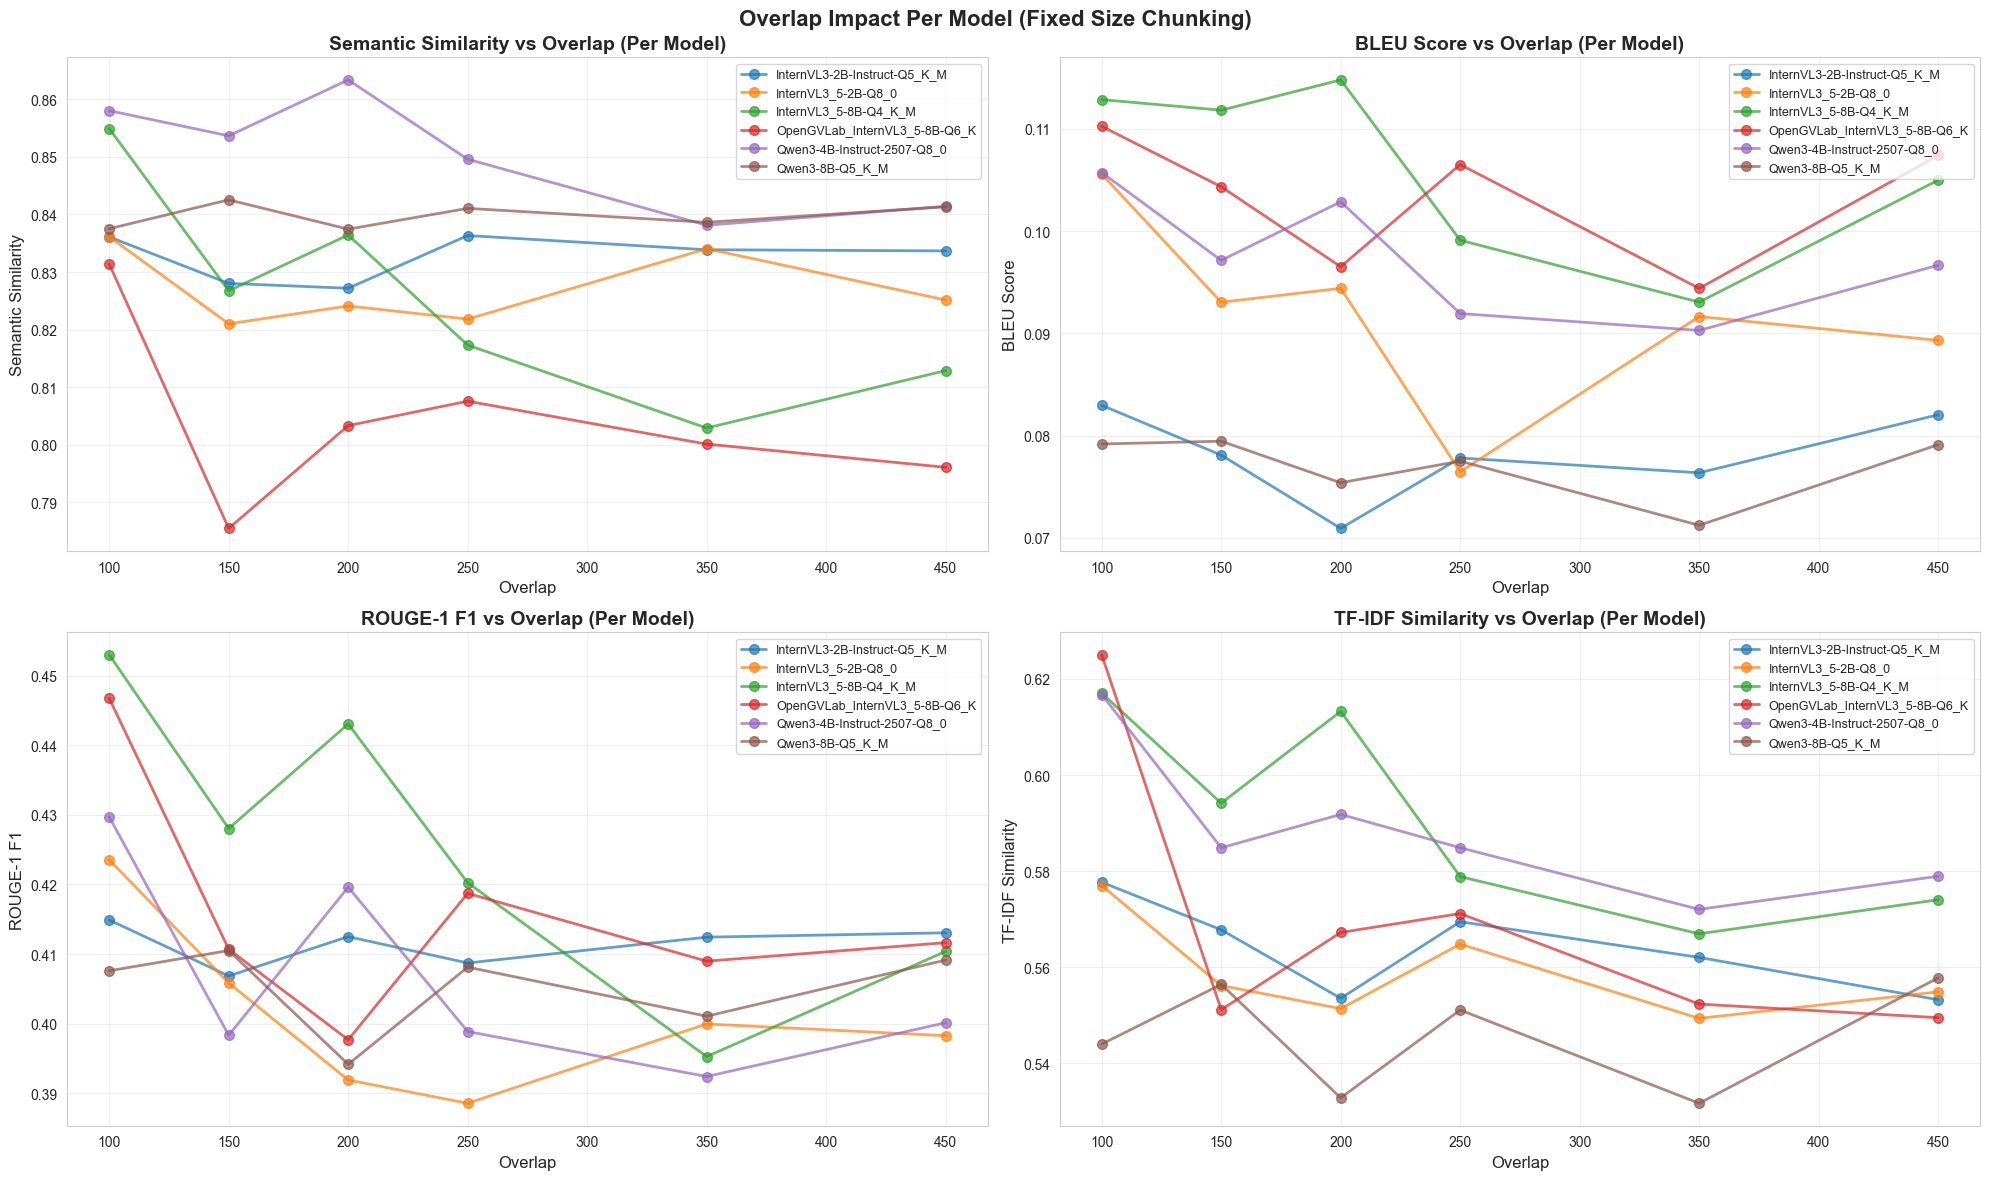

OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.0830,0.4149,2.3411,0.5285
150,0.8280,0.0781,0.4068,5.2790,0.5207
200,0.8272,0.0709,0.4125,3.2537,0.5175
250,0.8363,0.0778,0.4087,5.2131,0.5244
350,0.8339,0.0764,0.4124,7.7174,0.5226
450,0.8337,0.0820,0.4130,5.6018,0.5221


  → Best overlap: 250 (semantic similarity: 0.8363)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8361,0.1056,0.4235,20.0759,0.5350
150,0.8210,0.0931,0.4058,25.2365,0.5187
200,0.8241,0.0944,0.3919,23.2848,0.5156
250,0.8218,0.0765,0.3885,21.1609,0.5130
350,0.8340,0.0916,0.3999,27.1612,0.5201
450,0.8251,0.0893,0.3983,25.3022,0.5172


  → Best overlap: 100 (semantic similarity: 0.8361)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best overlap: 100 (semantic similarity: 0.8314)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8580,0.1057,0.4297,15.0055,0.5522
150,0.8537,0.0971,0.3983,22.4582,0.5348
200,0.8634,0.1029,0.4196,16.0236,0.5460
250,0.8496,0.0919,0.3989,22.8116,0.5324
350,0.8381,0.0903,0.3924,23.2279,0.5239
450,0.8414,0.0967,0.4001,23.7999,0.5297


  → Best overlap: 200 (semantic similarity: 0.8634)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time,composite_score
overlap,,,,,
100,0.8375,0.0792,0.4076,28.8969,0.5197
150,0.8425,0.0795,0.4105,42.1161,0.5247
200,0.8375,0.0754,0.3942,32.4753,0.5133
250,0.8411,0.0775,0.4081,41.1525,0.5221
350,0.8386,0.0712,0.4011,42.3231,0.5144
450,0.8413,0.0791,0.4091,42.8413,0.5241


  → Best overlap: 150 (semantic similarity: 0.8425)

OVERLAP × CHUNK SIZE HEATMAPS PER MODEL


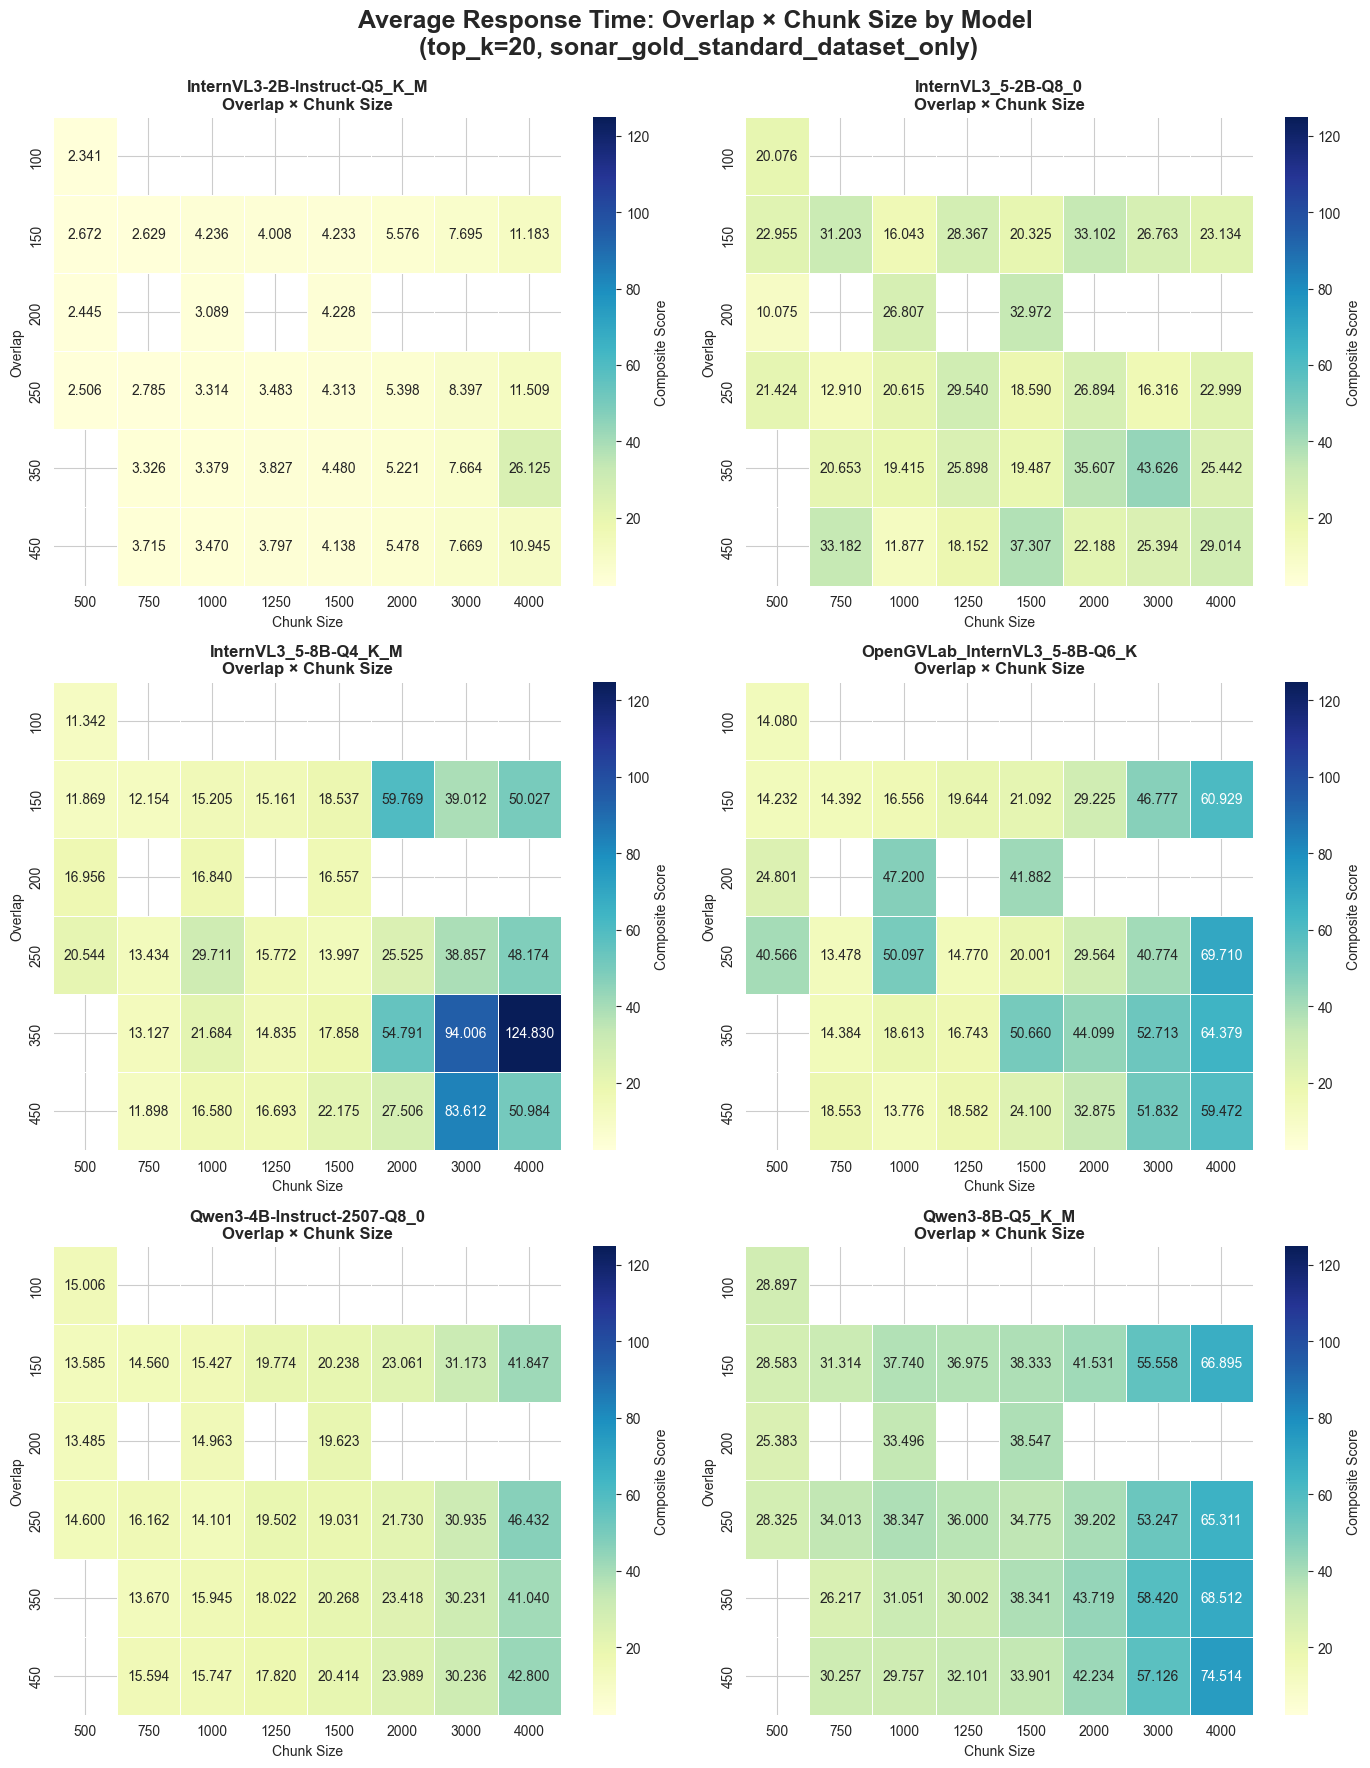

In [22]:
if len(fixed_size_df) > 0:
    # Create individual plots for each model showing overlap impact
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Plot each model separately
        for model in sorted(fixed_size_df['model_name'].dropna().unique()):
            model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap')[metric].mean()
            if len(model_data) > 0:
                ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                       markersize=7, label=model, alpha=0.7)
        
        ax.set_title(f'{label} vs Overlap (Per Model)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model (Fixed Size Chunking)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed breakdown by model and overlap
    print("=" * 100)
    print("OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)")
    print("=" * 100)
    
    for model in sorted(fixed_size_df['model_name'].dropna().unique()):
        model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean',
            'avg_response_time': 'mean',
            'composite_score': 'mean',
        }).round(4)
        
        if len(model_data) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(model_data)
            
            # Identify best overlap for this model
            best_overlap = model_data['avg_semantic_similarity'].idxmax()
            best_score = model_data.loc[best_overlap, 'avg_semantic_similarity']
            print(f"  → Best overlap: {int(best_overlap)} (semantic similarity: {best_score:.4f})")
    
    # Heatmap per model showing overlap vs chunk_size interaction
    print("\n" + "=" * 100)
    print("OVERLAP × CHUNK SIZE HEATMAPS PER MODEL")
    print("=" * 100)
    
    # Calculate optimal grid layout for all models
    num_models = fixed_size_df['model_name'].nunique()
    import math
    ncols = min(2, num_models)  # Max 2 columns for readability
    nrows = math.ceil(num_models / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
    
    # Flatten axes array for easy iteration
    if num_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else axes
    
    # Calculate global min and max for consistent scale
global_min = fixed_size_df['avg_response_time'].min()
global_max = fixed_size_df['avg_response_time'].max()

for idx, model in enumerate(sorted(fixed_size_df['model_name'].dropna().unique())):
    model_df = fixed_size_df[fixed_size_df['model_name'] == model]
    pivot_data = model_df.pivot_table(
        values='avg_response_time',
        index='overlap',
        columns='chunk_size',
        aggfunc='mean'
    )
    
    ax = axes[idx]
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
               cbar_kws={'label': 'Composite Score'}, linewidths=0.5,
               vmin=global_min, vmax=global_max)  # Added these parameters
    ax.set_title(f'{model}\nOverlap × Chunk Size', fontsize=12, fontweight='bold')
    ax.set_xlabel('Chunk Size', fontsize=10)
    ax.set_ylabel('Overlap', fontsize=10)

# Hide any unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Average Response Time: Overlap × Chunk Size by Model\n (top_k=20, sonar_gold_standard_dataset_only)\n', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()



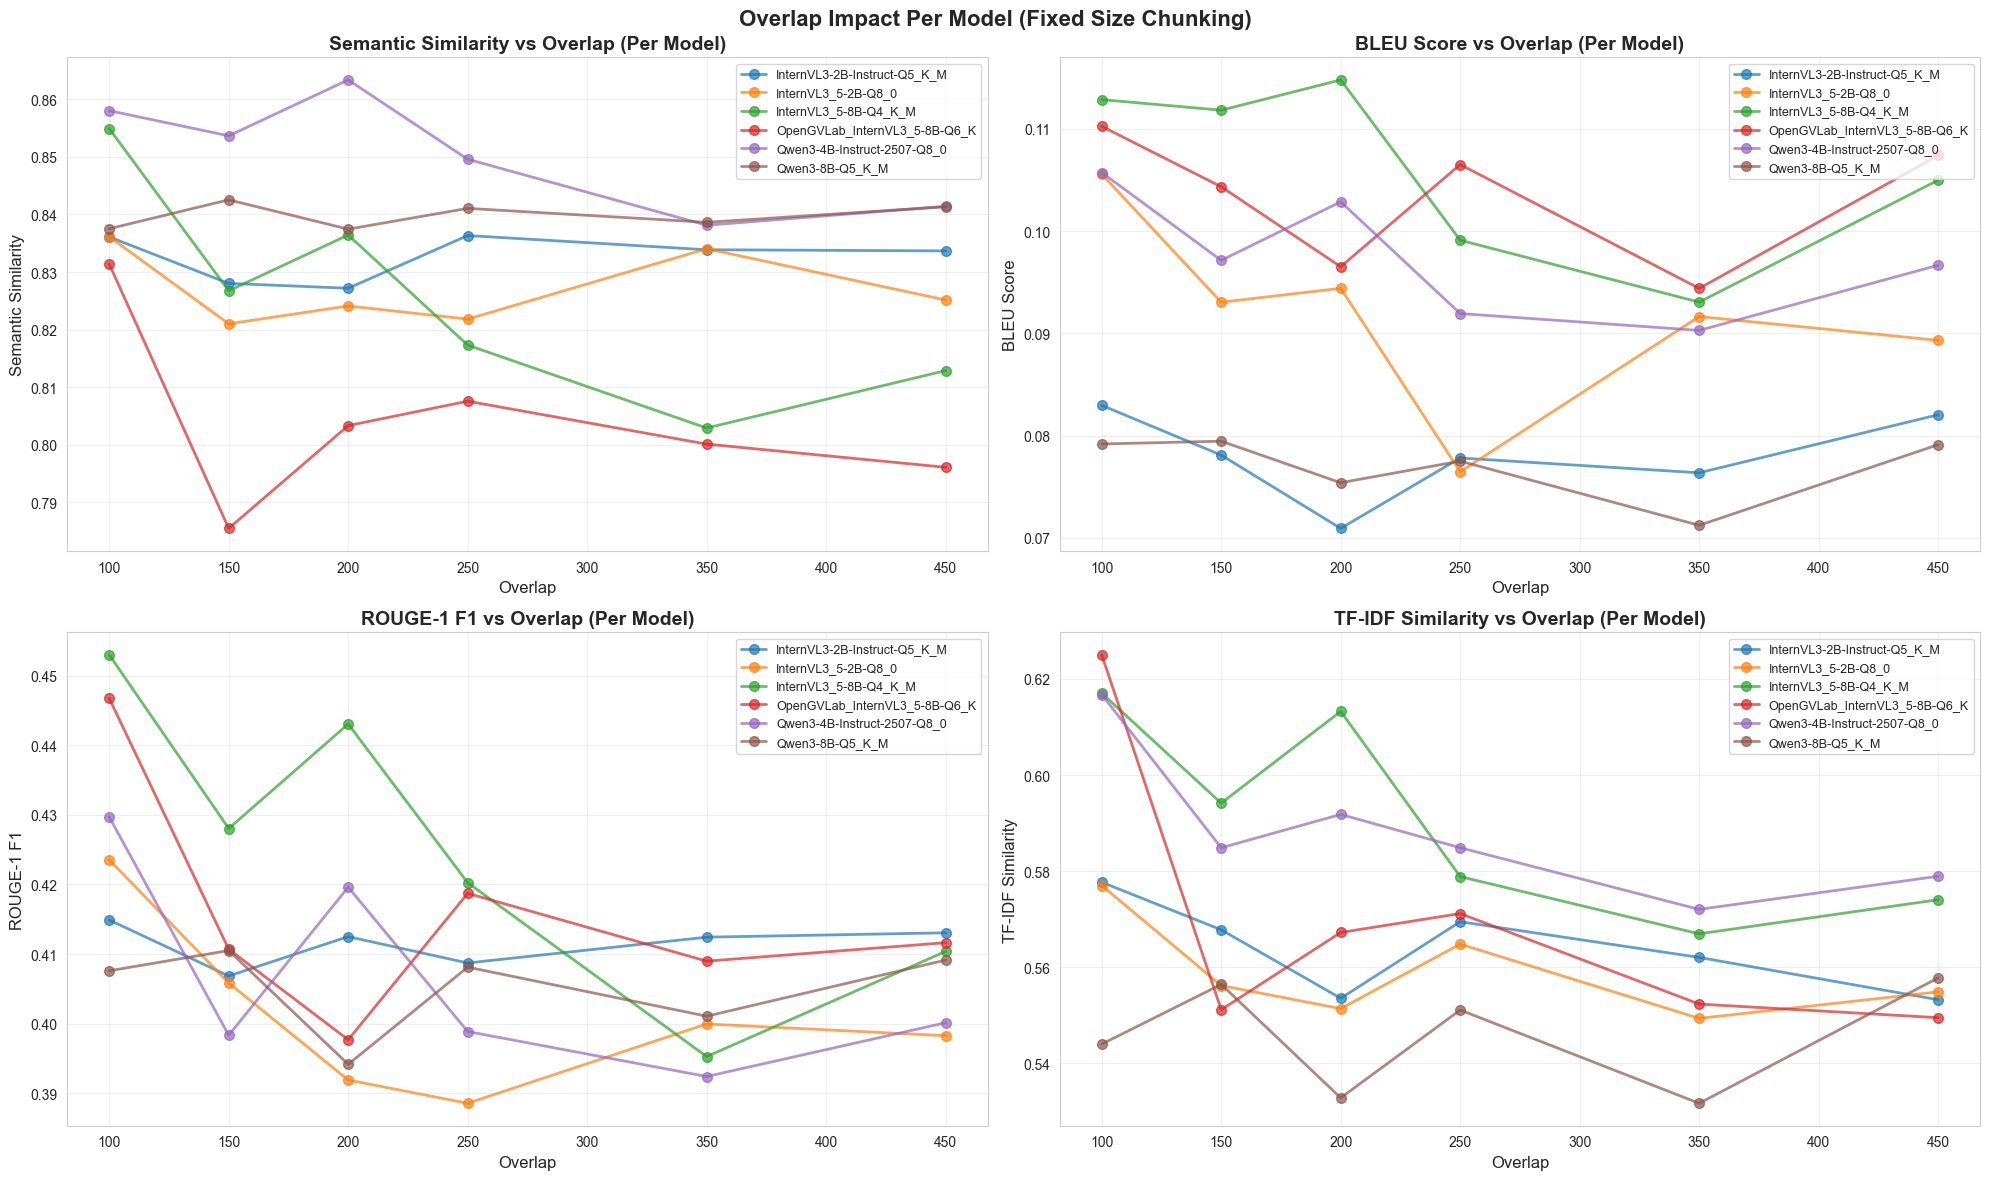

OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time
overlap,,,,
100,0.8361,0.0830,0.4149,2.3411
150,0.8280,0.0781,0.4068,5.2790
200,0.8272,0.0709,0.4125,3.2537
250,0.8363,0.0778,0.4087,5.2131
350,0.8339,0.0764,0.4124,7.7174
450,0.8337,0.0820,0.4130,5.6018


  → Best overlap: 250 (semantic similarity: 0.8363)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time
overlap,,,,
100,0.8361,0.1056,0.4235,20.0759
150,0.8210,0.0931,0.4058,25.2365
200,0.8241,0.0944,0.3919,23.2848
250,0.8218,0.0765,0.3885,21.1609
350,0.8340,0.0916,0.3999,27.1612
450,0.8251,0.0893,0.3983,25.3022


  → Best overlap: 100 (semantic similarity: 0.8361)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Best overlap: 100 (semantic similarity: 0.8314)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time
overlap,,,,
100,0.8580,0.1057,0.4297,15.0055
150,0.8537,0.0971,0.3983,22.4582
200,0.8634,0.1029,0.4196,16.0236
250,0.8496,0.0919,0.3989,22.8116
350,0.8381,0.0903,0.3924,23.2279
450,0.8414,0.0967,0.4001,23.7999


  → Best overlap: 200 (semantic similarity: 0.8634)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_response_time
overlap,,,,
100,0.8375,0.0792,0.4076,28.8969
150,0.8425,0.0795,0.4105,42.1161
200,0.8375,0.0754,0.3942,32.4753
250,0.8411,0.0775,0.4081,41.1525
350,0.8386,0.0712,0.4011,42.3231
450,0.8413,0.0791,0.4091,42.8413


  → Best overlap: 150 (semantic similarity: 0.8425)

OVERLAP × CHUNK SIZE HEATMAPS PER MODEL


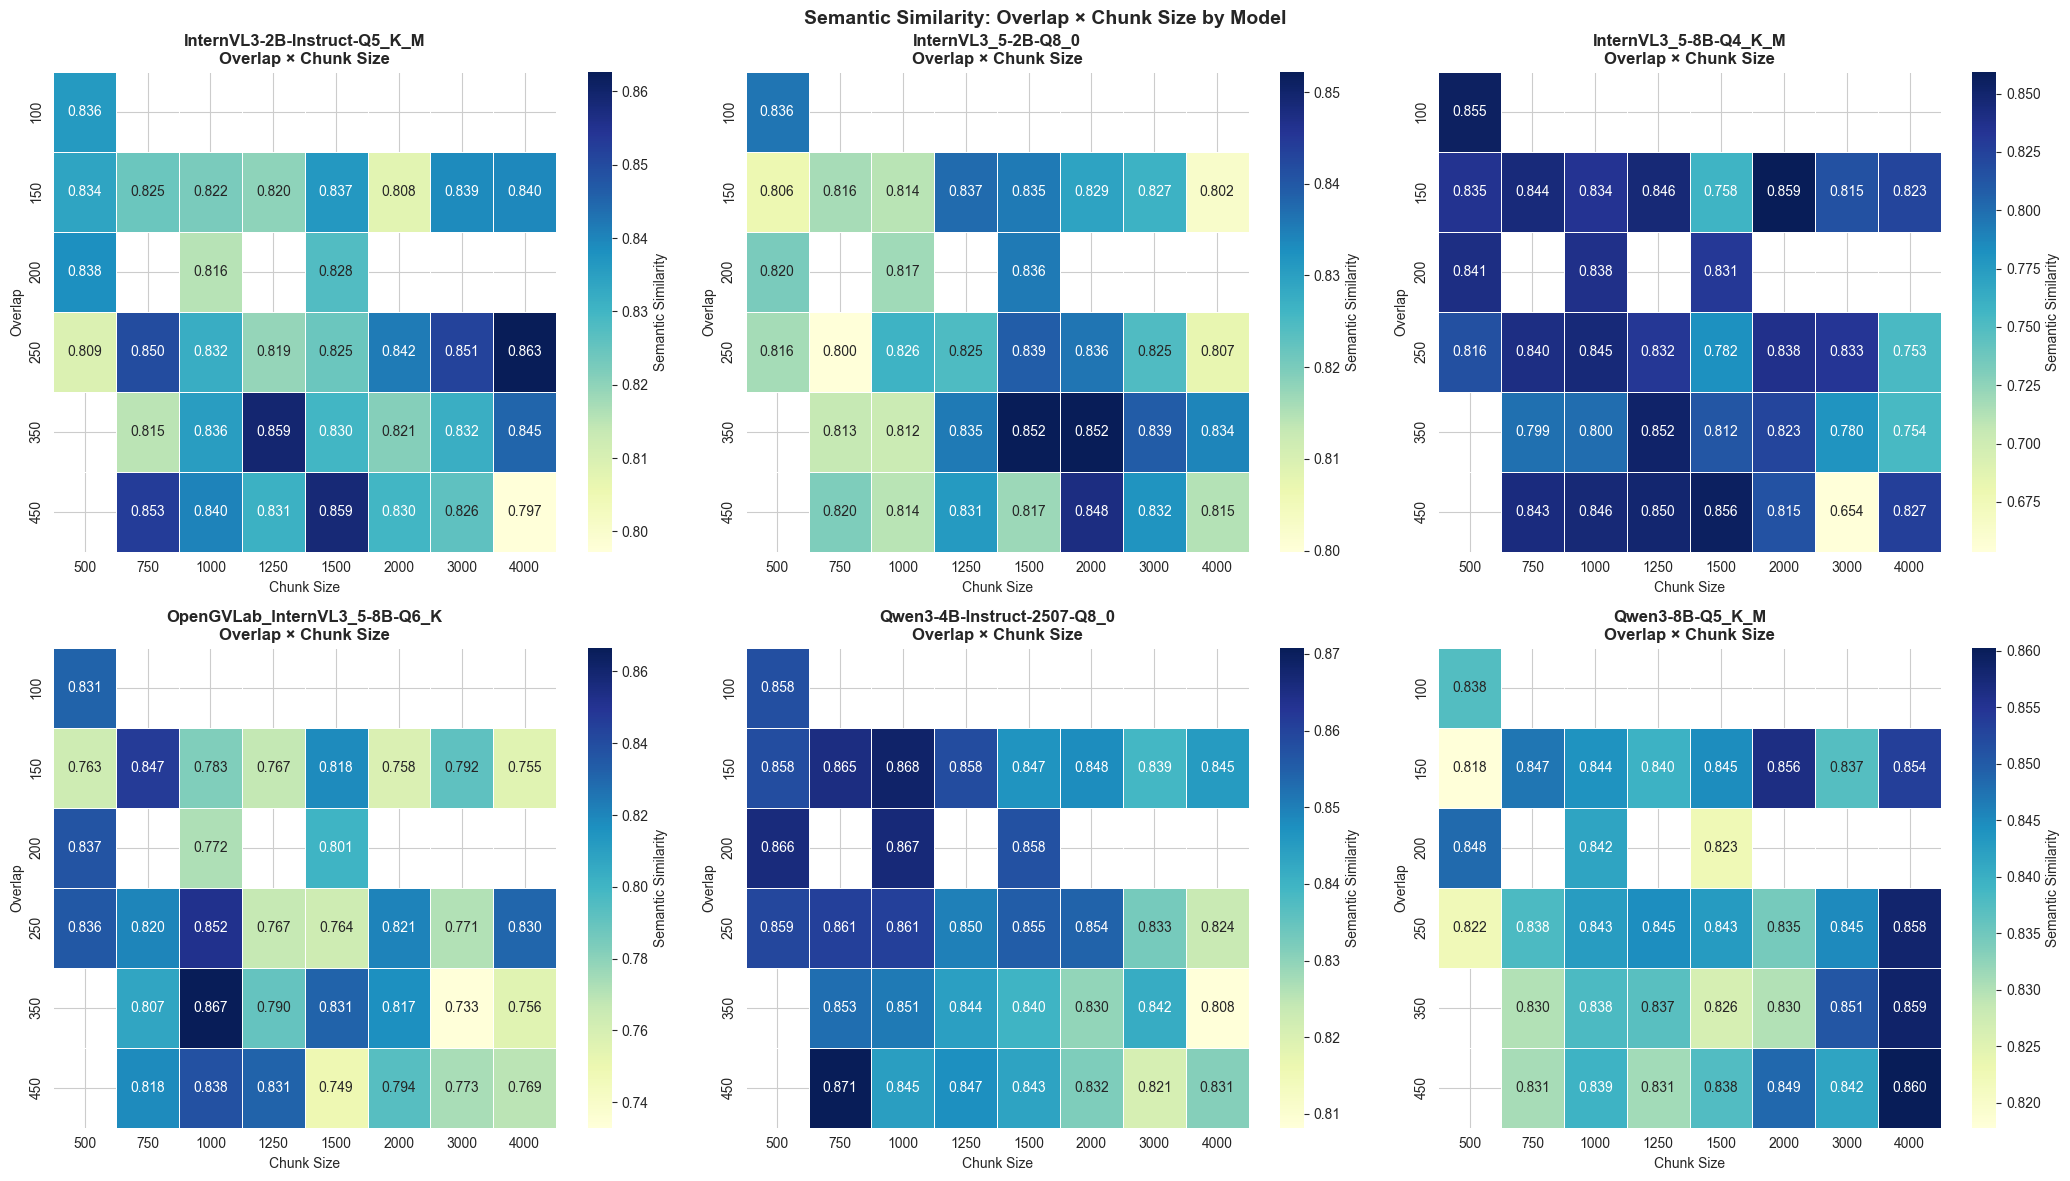

In [23]:
if len(fixed_size_df) > 0:
    # Create individual plots for each model showing overlap impact
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    for idx, (metric, label) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        # Plot each model separately
        for model in sorted(fixed_size_df['model_name'].dropna().unique()):
            model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap')[metric].mean()
            if len(model_data) > 0:
                ax.plot(model_data.index, model_data.values, marker='o', linewidth=2, 
                       markersize=7, label=model, alpha=0.7)
        
        ax.set_title(f'{label} vs Overlap (Per Model)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model (Fixed Size Chunking)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed breakdown by model and overlap
    print("=" * 100)
    print("OVERLAP PERFORMANCE BREAKDOWN BY MODEL (Fixed Size Chunking)")
    print("=" * 100)
    
    for model in sorted(fixed_size_df['model_name'].dropna().unique()):
        model_data = fixed_size_df[fixed_size_df['model_name'] == model].groupby('overlap').agg({
            'avg_semantic_similarity': 'mean',
            'avg_bleu_score': 'mean',
            'avg_rouge_1_f': 'mean',
            'avg_response_time': 'mean'
        }).round(4)
        
        if len(model_data) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(model_data)
            
            # Identify best overlap for this model
            best_overlap = model_data['avg_semantic_similarity'].idxmax()
            best_score = model_data.loc[best_overlap, 'avg_semantic_similarity']
            print(f"  → Best overlap: {int(best_overlap)} (semantic similarity: {best_score:.4f})")
    
    # Heatmap per model showing overlap vs chunk_size interaction
    print("\n" + "=" * 100)
    print("OVERLAP × CHUNK SIZE HEATMAPS PER MODEL")
    print("=" * 100)
    
    # Calculate optimal grid layout for all models
    num_models = fixed_size_df['model_name'].nunique()
    import math
    ncols = min(3, num_models)  # Max 3 columns for readability
    nrows = math.ceil(num_models / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
    
    # Flatten axes array for easy iteration
    if num_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else axes
    
    for idx, model in enumerate(sorted(fixed_size_df['model_name'].dropna().unique())):
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        pivot_data = model_df.pivot_table(
            values='avg_semantic_similarity',
            index='overlap',
            columns='chunk_size',
            aggfunc='mean'
        )
        
        ax = axes[idx]
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                   cbar_kws={'label': 'Semantic Similarity'}, linewidths=0.5)
        ax.set_title(f'{model}\nOverlap × Chunk Size', fontsize=12, fontweight='bold')
        ax.set_xlabel('Chunk Size', fontsize=10)
        ax.set_ylabel('Overlap', fontsize=10)
    
    # Hide any unused subplots
    for idx in range(num_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Semantic Similarity: Overlap × Chunk Size by Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("No fixed_size data available for overlap analysis per model")


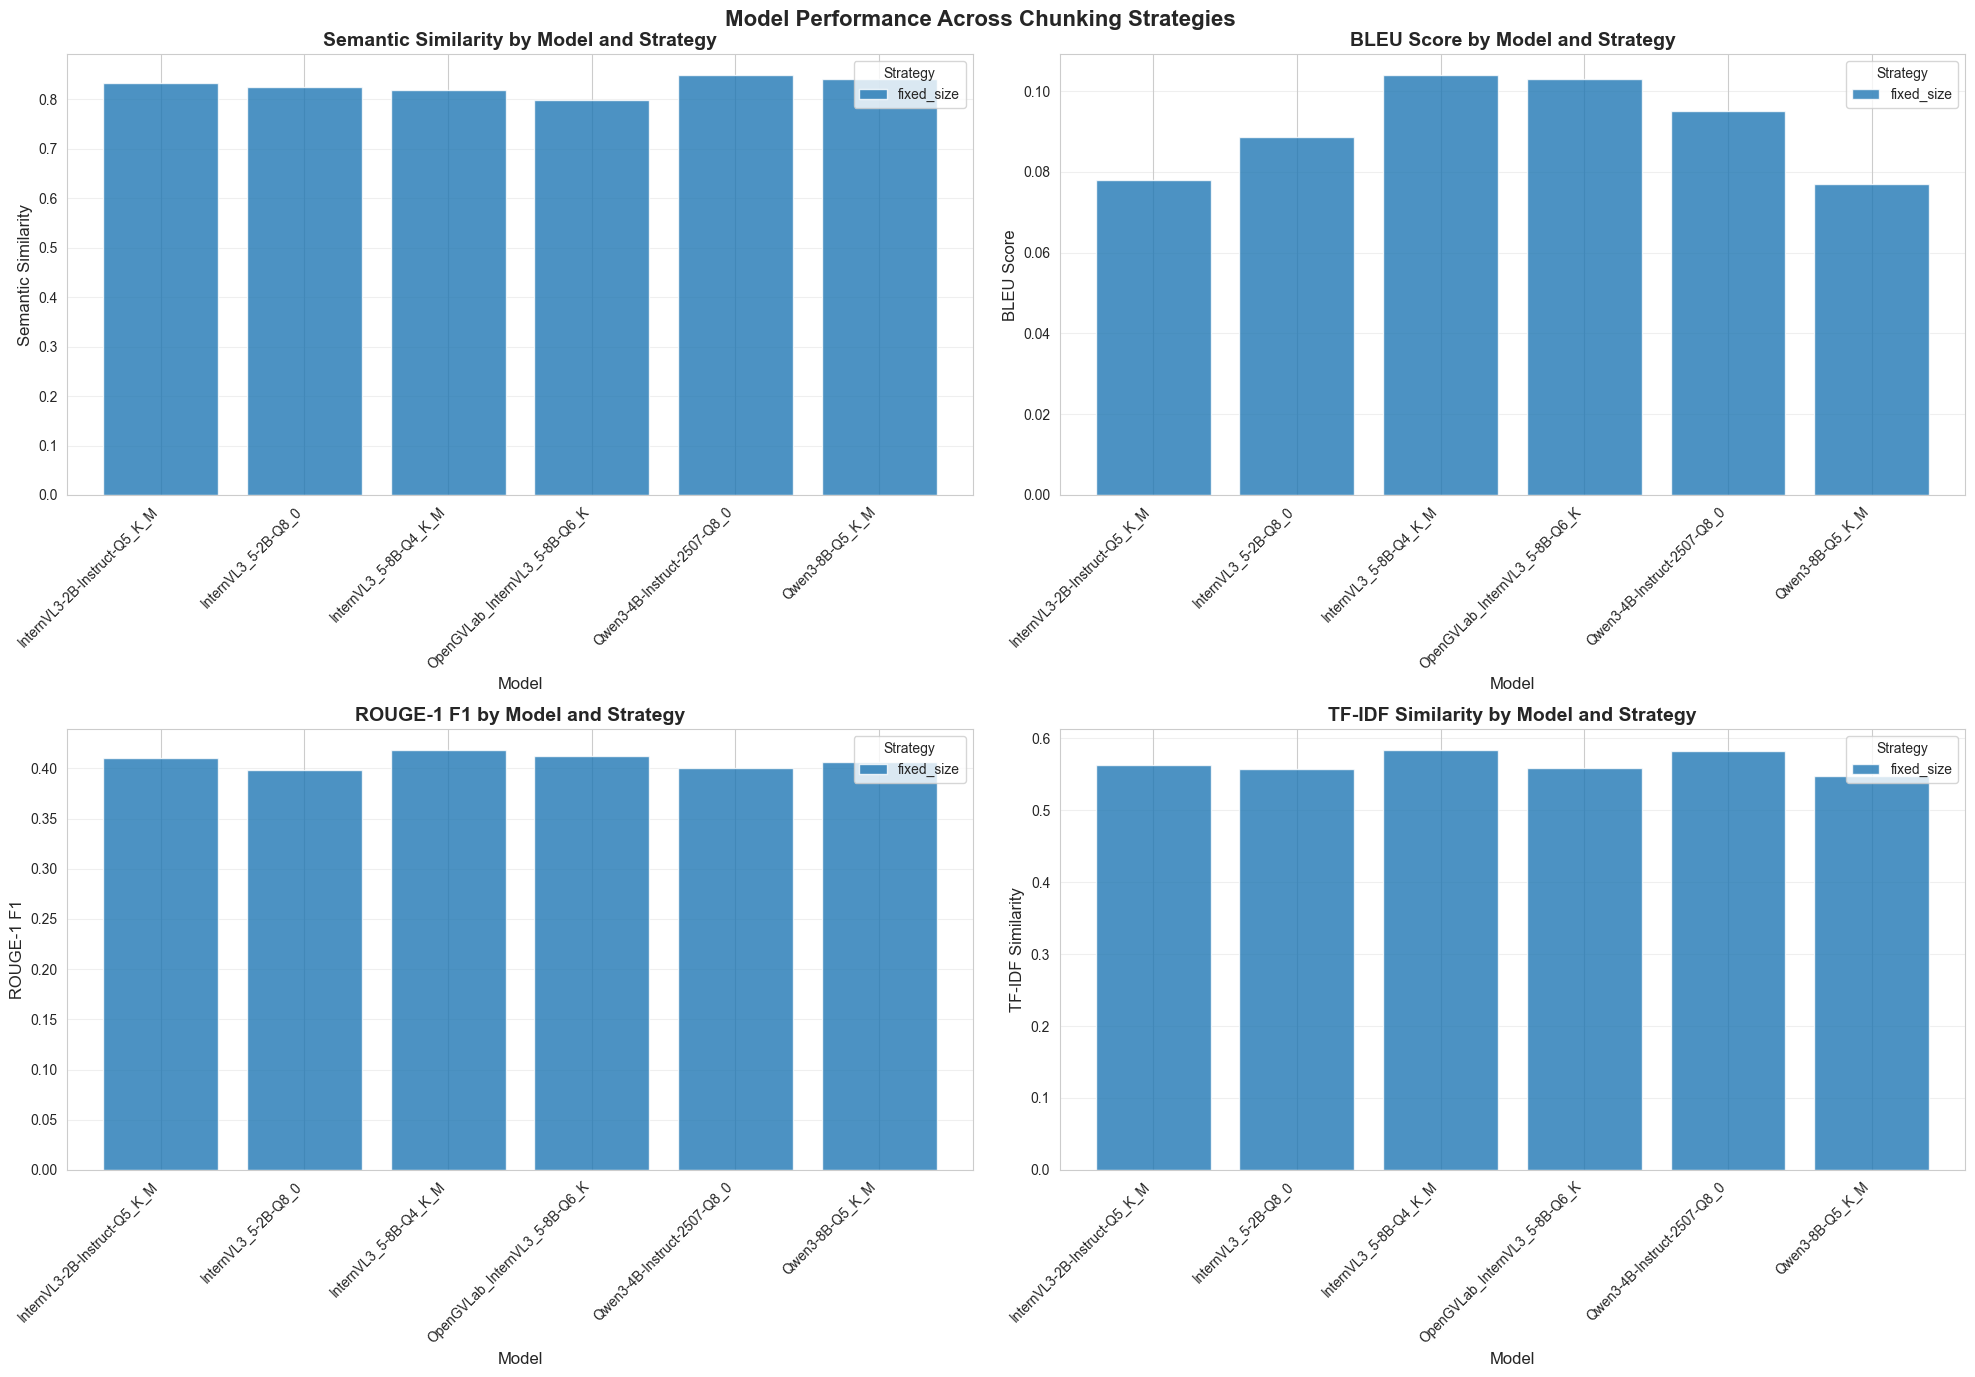

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for idx, (metric, label) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Group by model and chunking strategy
    model_data = df.groupby(['model_name', 'chunking_strategy'])[metric].mean().unstack()
    
    # Fill NaN values with 0 or drop them
    model_data = model_data.fillna(0)
    
    # Check if we have numeric data to plot
    if model_data.empty or model_data.shape[1] == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{label} by Model and Strategy', fontsize=14, fontweight='bold')
        continue
    
    model_data.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)
    ax.set_title(f'{label} by Model and Strategy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(title='Strategy', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Model Performance Across Chunking Strategies', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3c Overlap Impact Per Model by Chunk Size

OVERLAP IMPACT PER MODEL BY CHUNK SIZE


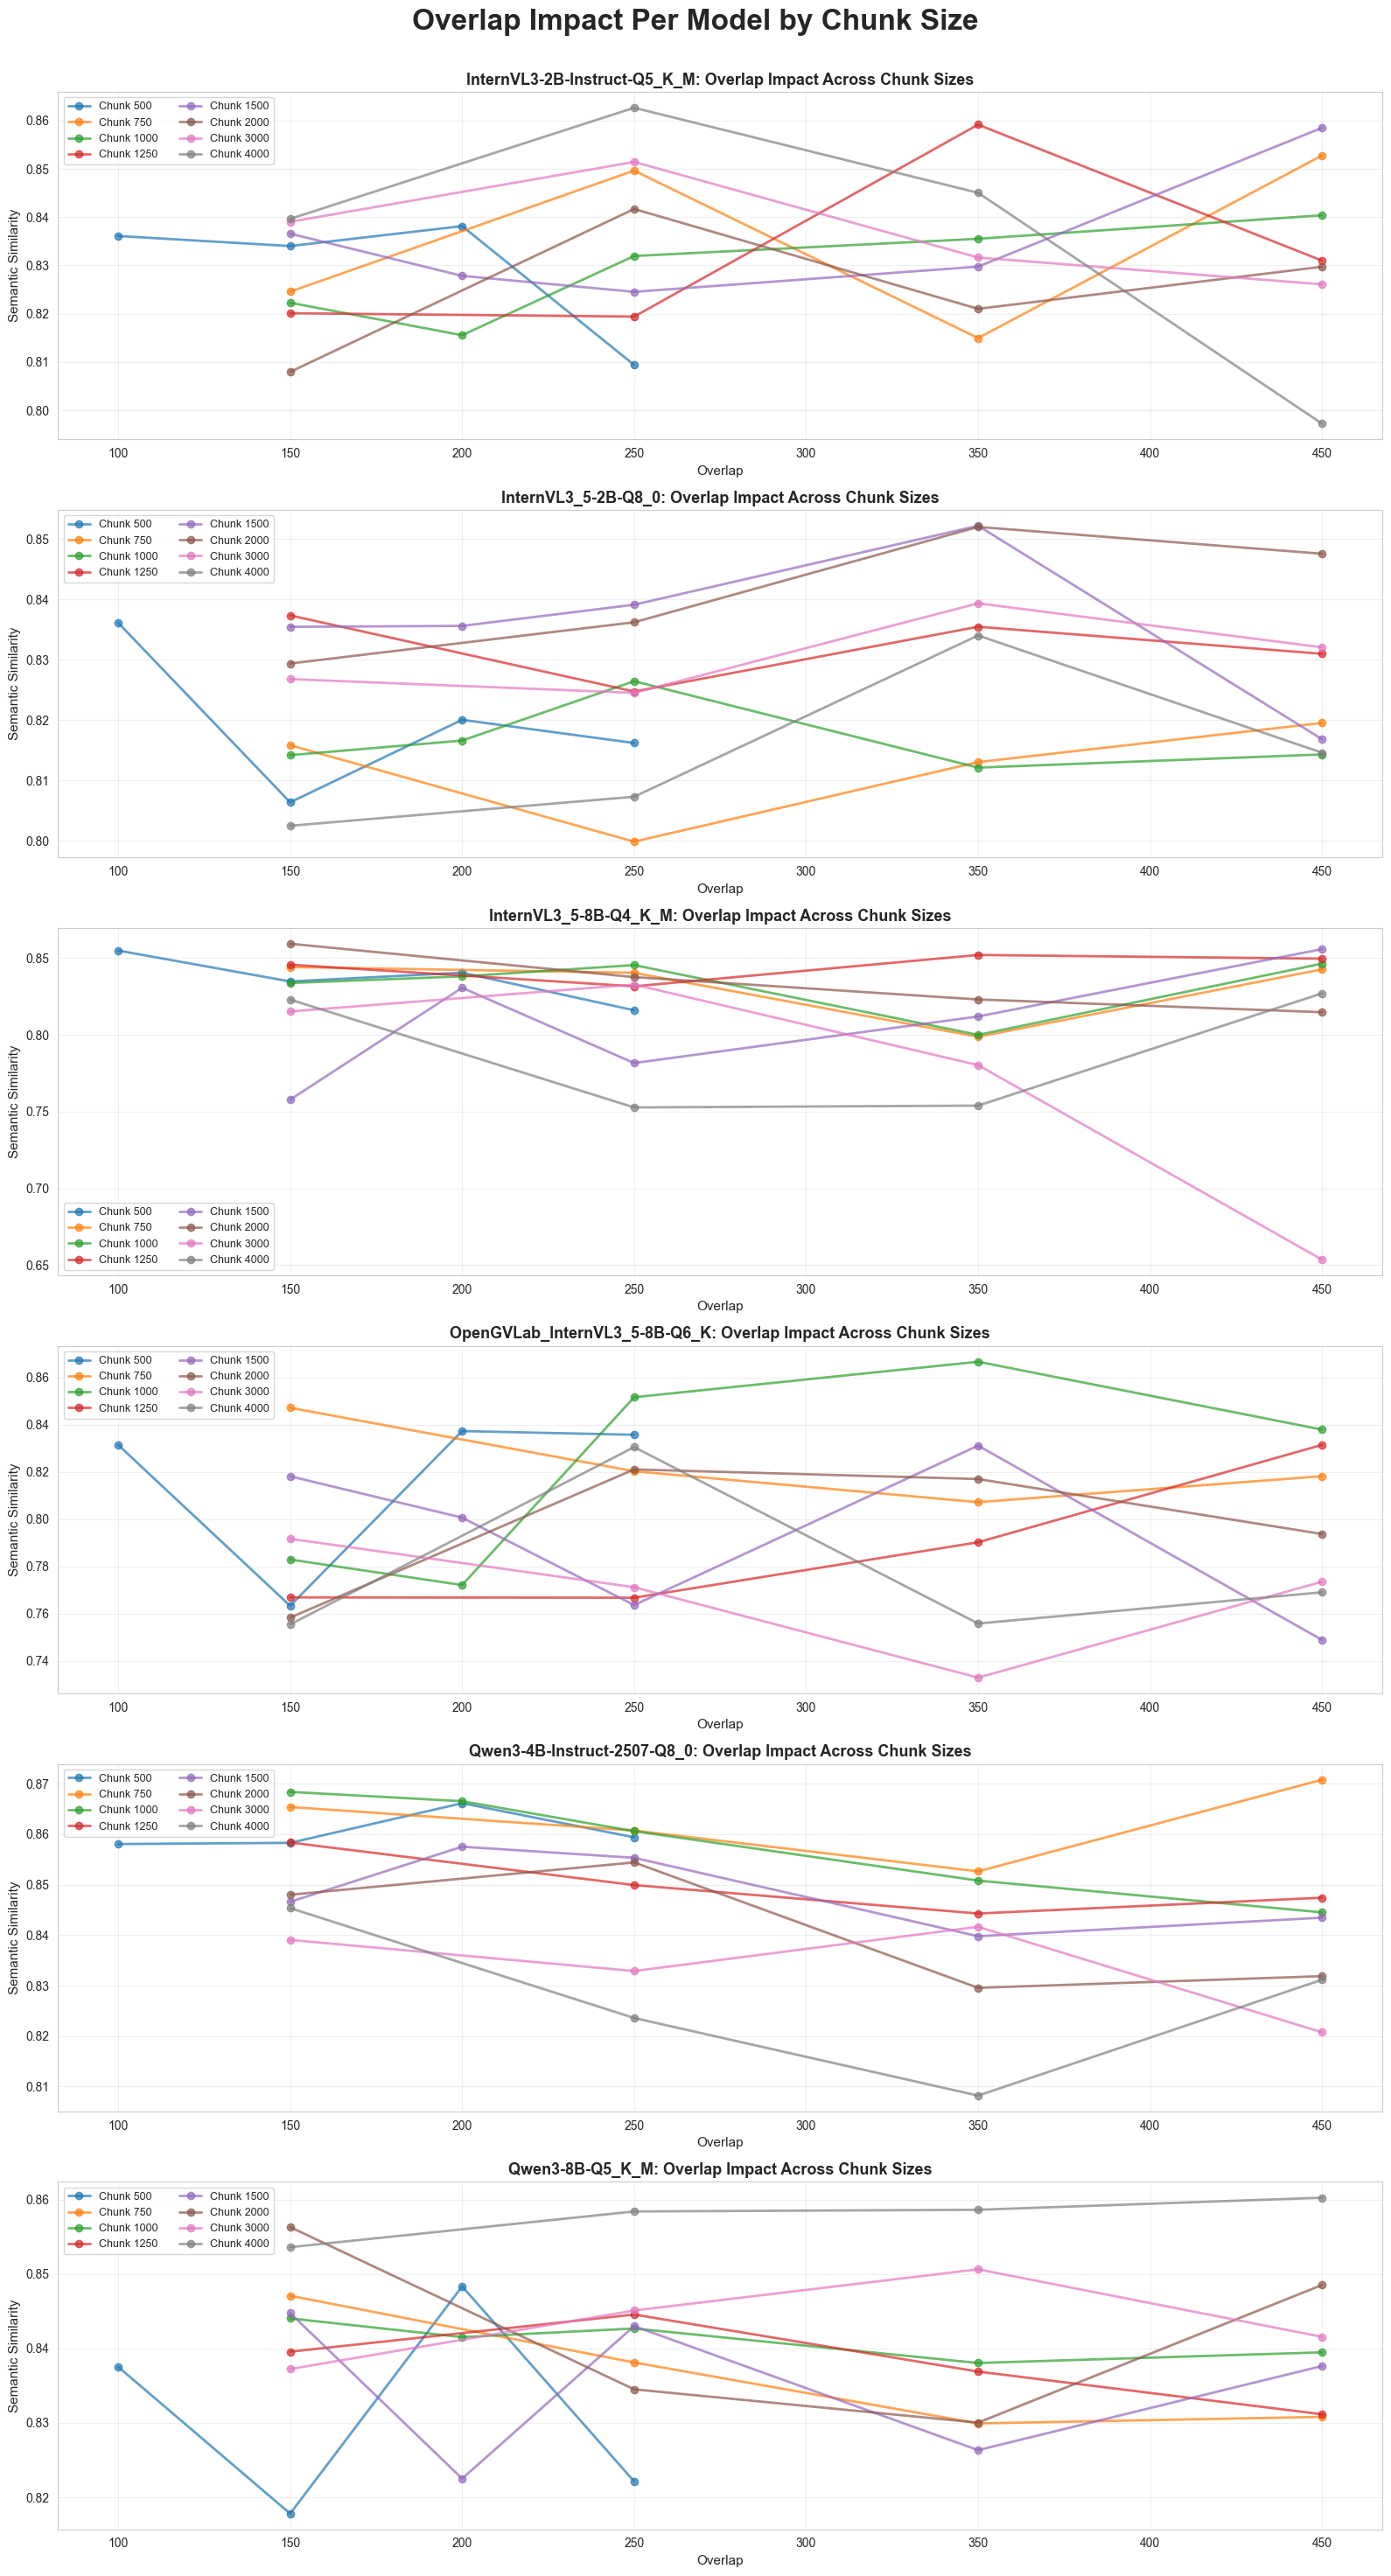


DETAILED BREAKDOWN: OVERLAP × CHUNK SIZE PER MODEL

InternVL3-2B-Instruct-Q5_K_M:
----------------------------------------------------------------------------------------------------


chunk_size,500,750,1000,1250,1500,2000,3000,4000
overlap,,,,,,,,
100,0.8361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,0.8340,0.8246,0.8223,0.8201,0.8366,0.8080,0.8390,0.8396
200,0.8381,NaN,0.8156,NaN,0.8278,NaN,NaN,NaN
250,0.8094,0.8496,0.8320,0.8194,0.8245,0.8417,0.8514,0.8627
350,NaN,0.8150,0.8355,0.8592,0.8298,0.8210,0.8316,0.8450
450,NaN,0.8528,0.8404,0.8310,0.8585,0.8297,0.8261,0.7972



  Best overlap per chunk size:
    Chunk 500: overlap=200 (semantic=0.8381)
    Chunk 750: overlap=450 (semantic=0.8528)
    Chunk 1000: overlap=450 (semantic=0.8404)
    Chunk 1250: overlap=350 (semantic=0.8592)
    Chunk 1500: overlap=450 (semantic=0.8585)
    Chunk 2000: overlap=250 (semantic=0.8417)
    Chunk 3000: overlap=250 (semantic=0.8514)
    Chunk 4000: overlap=250 (semantic=0.8627)

InternVL3_5-2B-Q8_0:
----------------------------------------------------------------------------------------------------


chunk_size,500,750,1000,1250,1500,2000,3000,4000
overlap,,,,,,,,
100,0.8361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,0.8064,0.8158,0.8142,0.8374,0.8355,0.8294,0.8268,0.8025
200,0.8201,NaN,0.8166,NaN,0.8356,NaN,NaN,NaN
250,0.8162,0.7999,0.8265,0.8247,0.8391,0.8362,0.8245,0.8073
350,NaN,0.8130,0.8121,0.8355,0.8522,0.8520,0.8394,0.8340
450,NaN,0.8195,0.8143,0.8310,0.8168,0.8476,0.8321,0.8146



  Best overlap per chunk size:
    Chunk 500: overlap=100 (semantic=0.8361)
    Chunk 750: overlap=450 (semantic=0.8195)
    Chunk 1000: overlap=250 (semantic=0.8265)
    Chunk 1250: overlap=150 (semantic=0.8374)
    Chunk 1500: overlap=350 (semantic=0.8522)
    Chunk 2000: overlap=350 (semantic=0.8520)
    Chunk 3000: overlap=350 (semantic=0.8394)
    Chunk 4000: overlap=350 (semantic=0.8340)

InternVL3_5-8B-Q4_K_M:
----------------------------------------------------------------------------------------------------


...

  → Most stable overlap across chunk sizes: 150 (std=0.0325)

Qwen3-4B-Instruct-2507-Q8_0:
----------------------------------------------------------------------------------------------------


,Mean,Std,Min,Max
overlap,,,,
100,0.8580,NaN,0.8580,0.8580
150,0.8537,0.0104,0.8391,0.8684
200,0.8634,0.0051,0.8575,0.8665
250,0.8496,0.0139,0.8236,0.8607
350,0.8381,0.0152,0.8082,0.8526
450,0.8414,0.0160,0.8208,0.8708


  → Most stable overlap across chunk sizes: 200 (std=0.0051)

Qwen3-8B-Q5_K_M:
----------------------------------------------------------------------------------------------------


,Mean,Std,Min,Max
overlap,,,,
100,0.8375,NaN,0.8375,0.8375
150,0.8425,0.0119,0.8178,0.8563
200,0.8375,0.0134,0.8225,0.8483
250,0.8411,0.0103,0.8221,0.8584
350,0.8386,0.0119,0.8263,0.8586
450,0.8413,0.0103,0.8308,0.8602


  → Most stable overlap across chunk sizes: 250 (std=0.0103)


In [25]:
if len(fixed_size_df) > 0:
    # Analyze overlap impact for each model at different chunk sizes
    print("=" * 100)
    print("OVERLAP IMPACT PER MODEL BY CHUNK SIZE")
    print("=" * 100)
    
    # Get all unique models and chunk sizes
    models = sorted(fixed_size_df['model_name'].dropna().unique())
    chunk_sizes = sorted(fixed_size_df['chunk_size'].dropna().unique())
    
    # Create subplots for each model
    num_models = len(models)
    fig, axes = plt.subplots(num_models, 1, figsize=(16, 5*num_models))
    if num_models == 1:
        axes = [axes]
    
    for model_idx, model in enumerate(models):
        ax = axes[model_idx]
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        
        # Plot overlap impact for each chunk size
        for chunk_size in chunk_sizes:
            chunk_data = model_df[model_df['chunk_size'] == chunk_size].groupby('overlap')['avg_semantic_similarity'].mean()
            if len(chunk_data) > 0:
                ax.plot(chunk_data.index, chunk_data.values, marker='o', linewidth=2, 
                       markersize=6, label=f'Chunk {int(chunk_size)}', alpha=0.7)
        
        ax.set_title(f'{model}: Overlap Impact Across Chunk Sizes', fontsize=13, fontweight='bold')
        ax.set_xlabel('Overlap', fontsize=11)
        ax.set_ylabel('Semantic Similarity', fontsize=11)
        ax.legend(fontsize=9, loc='best', ncol=2)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Overlap Impact Per Model by Chunk Size\n\n', fontsize=24, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detailed tables for each model showing overlap vs chunk size
    print("\n" + "=" * 100)
    print("DETAILED BREAKDOWN: OVERLAP × CHUNK SIZE PER MODEL")
    print("=" * 100)
    
    for model in models:
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        
        # Create pivot table
        pivot_table = model_df.pivot_table(
            values='avg_semantic_similarity',
            index='overlap',
            columns='chunk_size',
            aggfunc='mean'
        ).round(4)
        
        if len(pivot_table) > 0:
            print(f"\n{model}:")
            print("-" * 100)
            display(pivot_table)
            
            # Find best overlap for each chunk size
            print("\n  Best overlap per chunk size:")
            for chunk_size in pivot_table.columns:
                best_overlap = pivot_table[chunk_size].idxmax()
                best_score = pivot_table.loc[best_overlap, chunk_size]
                print(f"    Chunk {int(chunk_size)}: overlap={int(best_overlap)} (semantic={best_score:.4f})")
    
    # Statistical analysis: overlap stability across chunk sizes
    print("\n" + "=" * 100)
    print("OVERLAP STABILITY ANALYSIS")
    print("=" * 100)
    print("\nStandard deviation of semantic similarity across chunk sizes for each overlap:\n")
    
    for model in models:
        model_df = fixed_size_df[fixed_size_df['model_name'] == model]
        
        # Calculate std dev across chunk sizes for each overlap
        overlap_stability = model_df.groupby('overlap').agg({
            'avg_semantic_similarity': ['mean', 'std', 'min', 'max']
        }).round(4)
        overlap_stability.columns = ['Mean', 'Std', 'Min', 'Max']
        
        print(f"\n{model}:")
        print("-" * 100)
        display(overlap_stability)
        
        # Identify most stable overlap (lowest std dev)
        most_stable_overlap = overlap_stability['Std'].idxmin()
        print(f"  → Most stable overlap across chunk sizes: {int(most_stable_overlap)} (std={overlap_stability.loc[most_stable_overlap, 'Std']:.4f})")
        
else:
    print("No fixed_size data available for overlap impact analysis per model by chunk size")

### 8.5 Correlation Analysis

### 8.4 Correlation Analysis Per Model/Chunk/Overlap

CORRELATION ANALYSIS: METRICS BY MODEL, CHUNK SIZE, AND OVERLAP

1. OVERALL METRIC CORRELATIONS (All Configurations)


,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_rouge_2_f,avg_rouge_l_f,avg_tfidf_similarity,avg_response_time
avg_semantic_similarity,1.000,0.012,0.334,0.196,0.252,0.573,-0.292
avg_bleu_score,0.012,1.000,0.628,0.789,0.652,0.492,-0.042
avg_rouge_1_f,0.334,0.628,1.000,0.736,0.832,0.639,-0.318
avg_rouge_2_f,0.196,0.789,0.736,1.000,0.817,0.659,-0.209
avg_rouge_l_f,0.252,0.652,0.832,0.817,1.000,0.618,-0.371
avg_tfidf_similarity,0.573,0.492,0.639,0.659,0.618,1.000,-0.358
avg_response_time,-0.292,-0.042,-0.318,-0.209,-0.371,-0.358,1.000


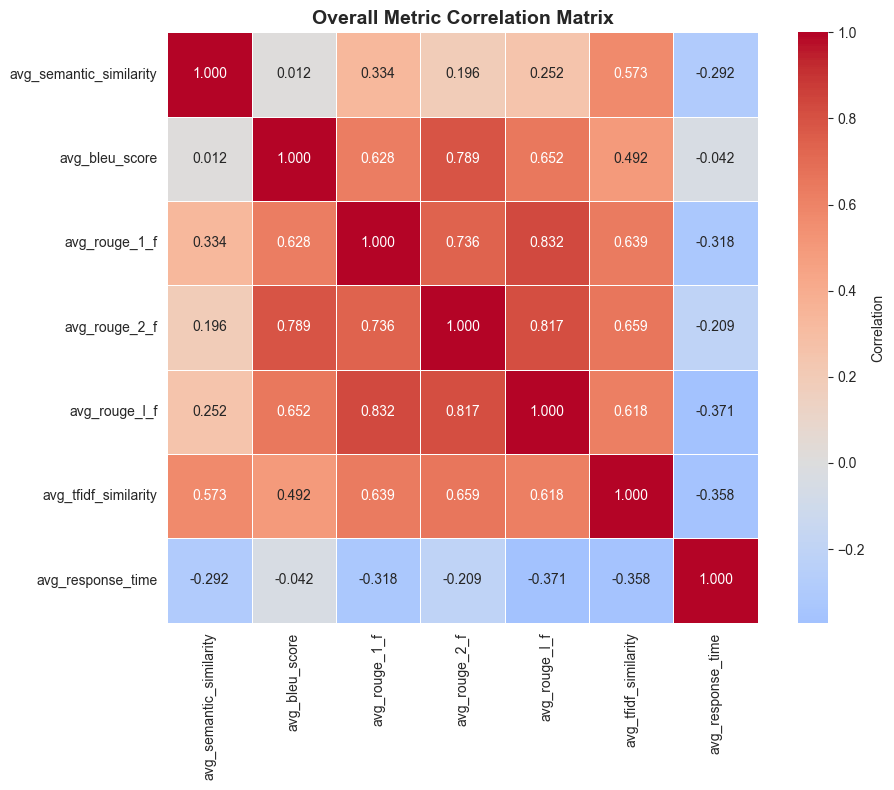


2. METRIC CORRELATIONS PER MODEL


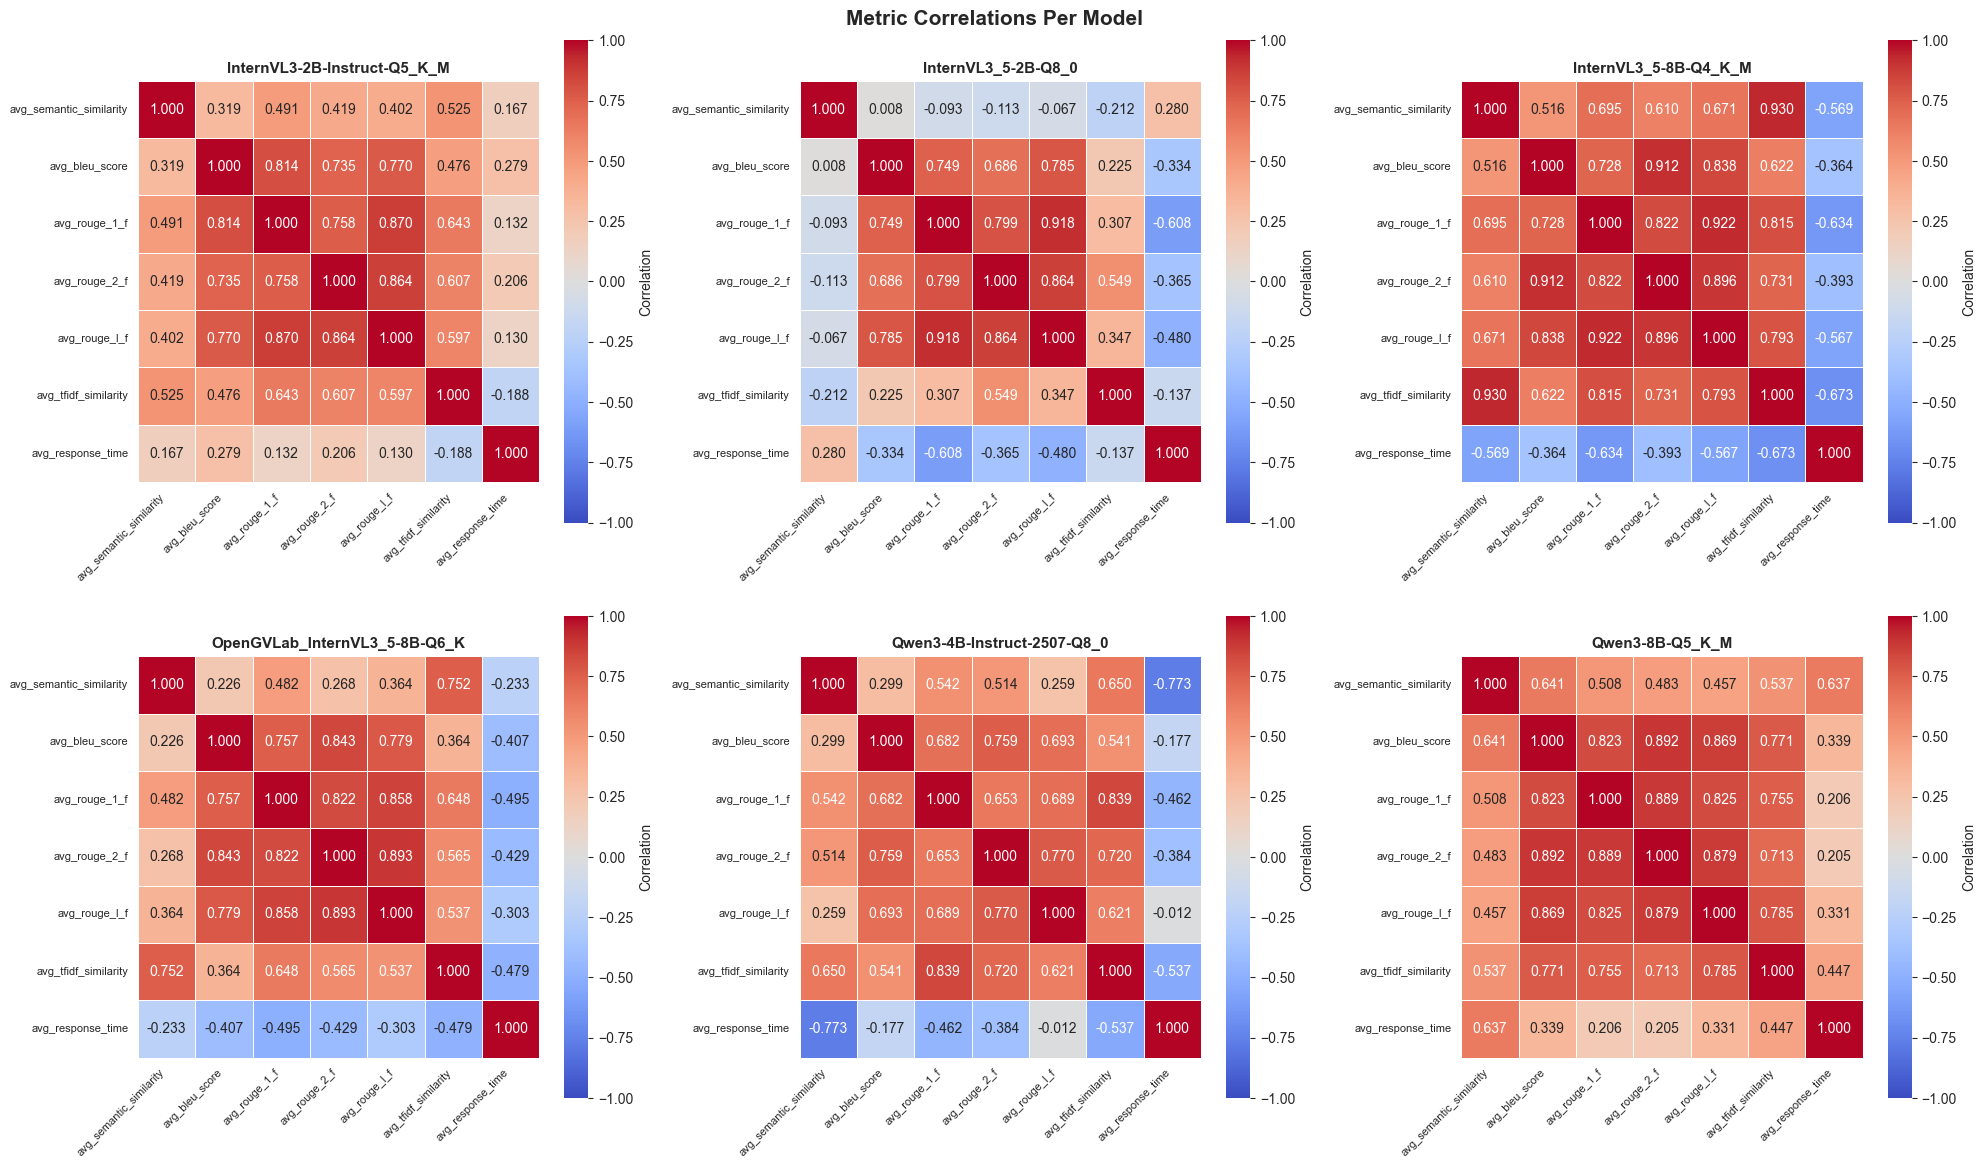


3. METRIC CORRELATIONS BY CHUNK SIZE (Fixed Size Chunking)


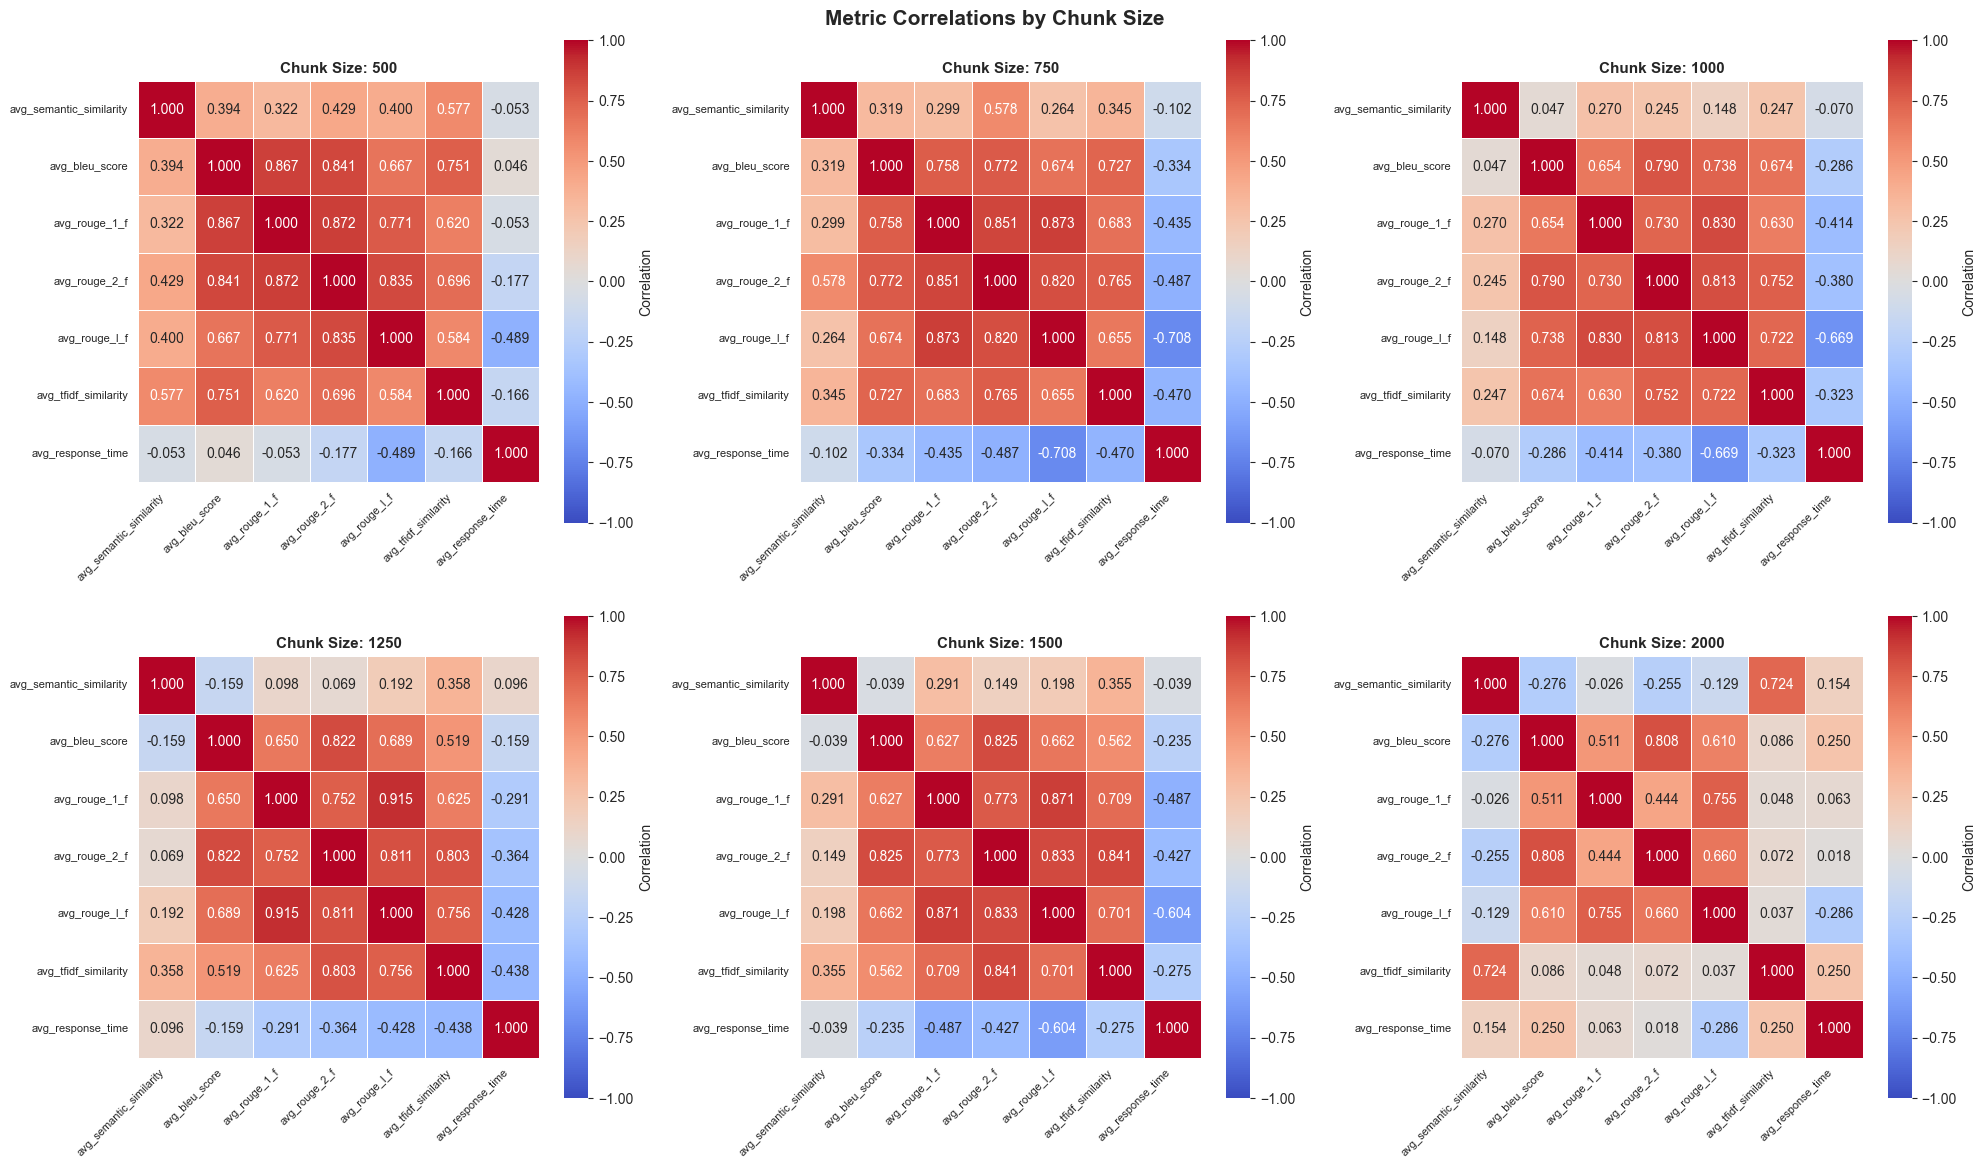


4. METRIC CORRELATIONS BY OVERLAP (Fixed Size Chunking)


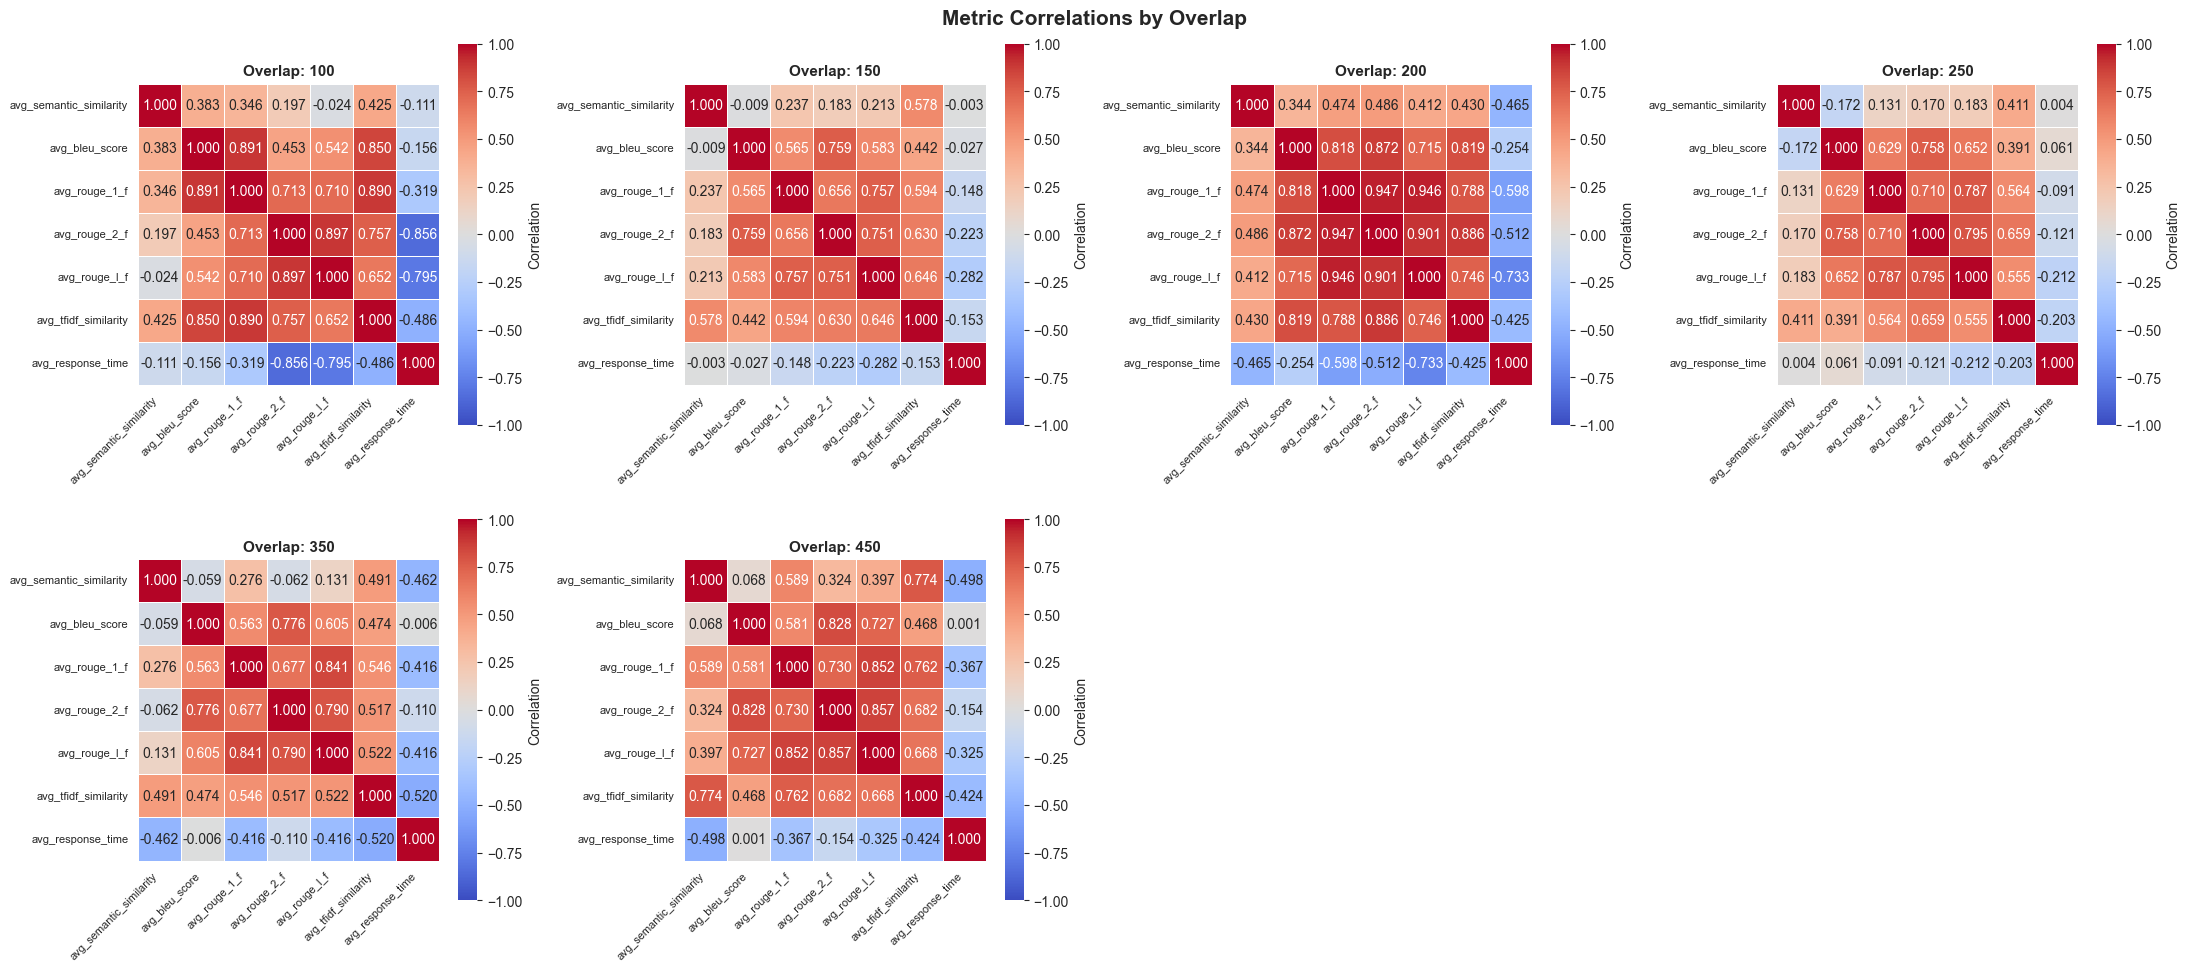


5. CORRELATION STRENGTH SUMMARY

Correlation of Semantic Similarity with Other Metrics (Per Model):


,Model,Sem-BLEU,Sem-ROUGE1,Sem-ROUGE2,Sem-ROUGEL,Sem-TFIDF,Sem-RespTime
0,InternVL3-2B-Instruct-Q5_K_M,0.319,0.491,0.419,0.402,0.525,0.167
1,InternVL3_5-2B-Q8_0,0.008,-0.093,-0.113,-0.067,-0.212,0.280
2,InternVL3_5-8B-Q4_K_M,0.516,0.695,0.610,0.671,0.930,-0.569
3,OpenGVLab_InternVL3_5-8B-Q6_K,0.226,0.482,0.268,0.364,0.752,-0.233
4,Qwen3-4B-Instruct-2507-Q8_0,0.299,0.542,0.514,0.259,0.650,-0.773
5,Qwen3-8B-Q5_K_M,0.641,0.508,0.483,0.457,0.537,0.637



6. KEY INSIGHTS FROM CORRELATION ANALYSIS

Strongest positive correlation with Semantic Similarity:
  tfidf_similarity: 0.573

Weakest/Most negative correlation with Semantic Similarity:
  response_time: -0.292


Correlation Variability Across Models:
  Sem-BLEU: mean=0.335, std=0.222 (variability=high)
  Sem-ROUGE1: mean=0.438, std=0.271 (variability=high)
  Sem-ROUGE2: mean=0.363, std=0.260 (variability=high)
  Sem-ROUGEL: mean=0.348, std=0.245 (variability=high)
  Sem-TFIDF: mean=0.530, std=0.394 (variability=high)
  Sem-RespTime: mean=-0.082, std=0.538 (variability=high)



In [26]:
# Correlation analysis between metrics at different granularities
print("=" * 100)
print("CORRELATION ANALYSIS: METRICS BY MODEL, CHUNK SIZE, AND OVERLAP")
print("=" * 100)

metric_cols = ['avg_semantic_similarity', 'avg_bleu_score', 'avg_rouge_1_f', 
               'avg_rouge_2_f', 'avg_rouge_l_f', 'avg_tfidf_similarity', 'avg_response_time']

# 1. Overall correlation across all data
print("\n" + "=" * 100)
print("1. OVERALL METRIC CORRELATIONS (All Configurations)")
print("=" * 100)
overall_corr = df[metric_cols].corr().round(3)
display(overall_corr)

# Visualize overall correlations
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overall_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
           ax=ax, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Overall Metric Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Correlation per model
print("\n" + "=" * 100)
print("2. METRIC CORRELATIONS PER MODEL")
print("=" * 100)

num_models = df['model_name'].nunique()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, model in enumerate(sorted(df['model_name'].dropna().unique())):
    model_df = df[df['model_name'] == model]
    
    if len(model_df) > 1:
        model_corr = model_df[metric_cols].corr().round(3)
        
        ax = axes[idx]
        sns.heatmap(model_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                   ax=ax, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'},
                   vmin=-1, vmax=1)
        ax.set_title(f'{model}', fontsize=11, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Metric Correlations Per Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Correlation by chunk size (fixed_size only)
if len(fixed_size_df) > 0:
    print("\n" + "=" * 100)
    print("3. METRIC CORRELATIONS BY CHUNK SIZE (Fixed Size Chunking)")
    print("=" * 100)
    
    # Select representative chunk sizes
    chunk_sizes_to_analyze = sorted(fixed_size_df['chunk_size'].unique())[:6]  # Top 6 chunk sizes
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, chunk_size in enumerate(chunk_sizes_to_analyze):
        chunk_df = fixed_size_df[fixed_size_df['chunk_size'] == chunk_size]
        
        if len(chunk_df) > 1:
            chunk_corr = chunk_df[metric_cols].corr().round(3)
            
            ax = axes[idx]
            sns.heatmap(chunk_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                       ax=ax, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'},
                       vmin=-1, vmax=1)
            ax.set_title(f'Chunk Size: {int(chunk_size)}', fontsize=11, fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(chunk_sizes_to_analyze), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Metric Correlations by Chunk Size', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 4. Correlation by overlap (fixed_size only)
    print("\n" + "=" * 100)
    print("4. METRIC CORRELATIONS BY OVERLAP (Fixed Size Chunking)")
    print("=" * 100)
    
    overlaps_to_analyze = sorted(fixed_size_df['overlap'].unique())
    
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    for idx, overlap in enumerate(overlaps_to_analyze):
        overlap_df = fixed_size_df[fixed_size_df['overlap'] == overlap]
        
        if len(overlap_df) > 1:
            overlap_corr = overlap_df[metric_cols].corr().round(3)
            
            ax = axes[idx]
            sns.heatmap(overlap_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                       ax=ax, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'},
                       vmin=-1, vmax=1)
            ax.set_title(f'Overlap: {int(overlap)}', fontsize=11, fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(overlaps_to_analyze), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Metric Correlations by Overlap', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 5. Detailed correlation analysis per model-chunk size combination
print("\n" + "=" * 100)
print("5. CORRELATION STRENGTH SUMMARY")
print("=" * 100)

# Calculate correlation between semantic similarity and other metrics
correlation_summary = []

for model in sorted(df['model_name'].dropna().unique()):
    model_df = df[df['model_name'] == model]
    
    if len(model_df) > 1:
        correlations = {
            'Model': model,
            'Sem-BLEU': model_df['avg_semantic_similarity'].corr(model_df['avg_bleu_score']),
            'Sem-ROUGE1': model_df['avg_semantic_similarity'].corr(model_df['avg_rouge_1_f']),
            'Sem-ROUGE2': model_df['avg_semantic_similarity'].corr(model_df['avg_rouge_2_f']),
            'Sem-ROUGEL': model_df['avg_semantic_similarity'].corr(model_df['avg_rouge_l_f']),
            'Sem-TFIDF': model_df['avg_semantic_similarity'].corr(model_df['avg_tfidf_similarity']),
            'Sem-RespTime': model_df['avg_semantic_similarity'].corr(model_df['avg_response_time'])
        }
        correlation_summary.append(correlations)

correlation_summary_df = pd.DataFrame(correlation_summary).round(3)
print("\nCorrelation of Semantic Similarity with Other Metrics (Per Model):")
display(correlation_summary_df)

# 6. Statistical insights
print("\n" + "=" * 100)
print("6. KEY INSIGHTS FROM CORRELATION ANALYSIS")
print("=" * 100)

# Find strongest and weakest correlations overall
overall_corr_values = overall_corr.loc['avg_semantic_similarity'].drop('avg_semantic_similarity')
print(f"\nStrongest positive correlation with Semantic Similarity:")
print(f"  {overall_corr_values.idxmax().replace('avg_', '')}: {overall_corr_values.max():.3f}")

print(f"\nWeakest/Most negative correlation with Semantic Similarity:")
print(f"  {overall_corr_values.idxmin().replace('avg_', '')}: {overall_corr_values.min():.3f}")

# Analyze if correlations vary significantly across models
if len(correlation_summary_df) > 1:
    print(f"\n\nCorrelation Variability Across Models:")
    for col in correlation_summary_df.columns[1:]:
        std = correlation_summary_df[col].std()
        mean = correlation_summary_df[col].mean()
        print(f"  {col}: mean={mean:.3f}, std={std:.3f} (variability={'high' if std > 0.2 else 'moderate' if std > 0.1 else 'low'})")

print("\n" + "=" * 100)

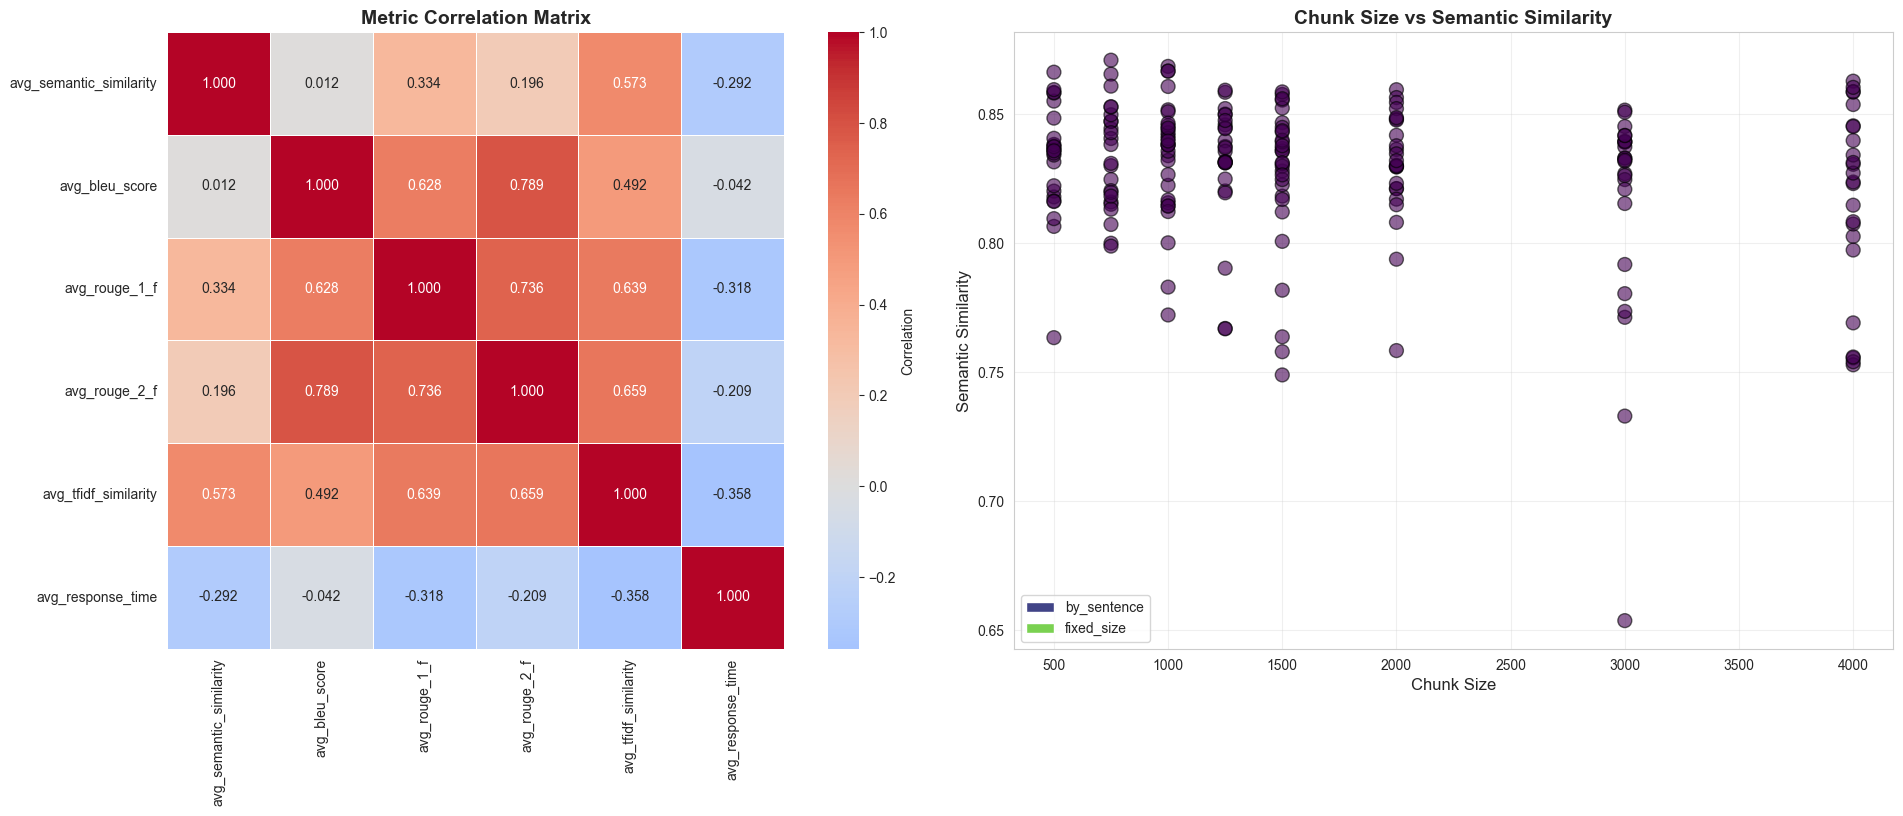

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Overall correlation
metric_cols = ['avg_semantic_similarity', 'avg_bleu_score', 'avg_rouge_1_f', 
               'avg_rouge_2_f', 'avg_tfidf_similarity', 'avg_response_time']
corr_matrix = df[metric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
           ax=axes[0], square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Metric Correlation Matrix', fontsize=14, fontweight='bold')

# Chunk size vs performance
axes[1].scatter(df['chunk_size'], df['avg_semantic_similarity'], 
               c=df['chunking_strategy'].astype('category').cat.codes, 
               cmap='viridis', s=100, alpha=0.6, edgecolors='black')
axes[1].set_xlabel('Chunk Size', fontsize=12)
axes[1].set_ylabel('Semantic Similarity', fontsize=12)
axes[1].set_title('Chunk Size vs Semantic Similarity', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=plt.cm.viridis(0.2), label='by_sentence'),
                  Patch(facecolor=plt.cm.viridis(0.8), label='fixed_size')]
axes[1].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

### 8.6 Response Time Analysis

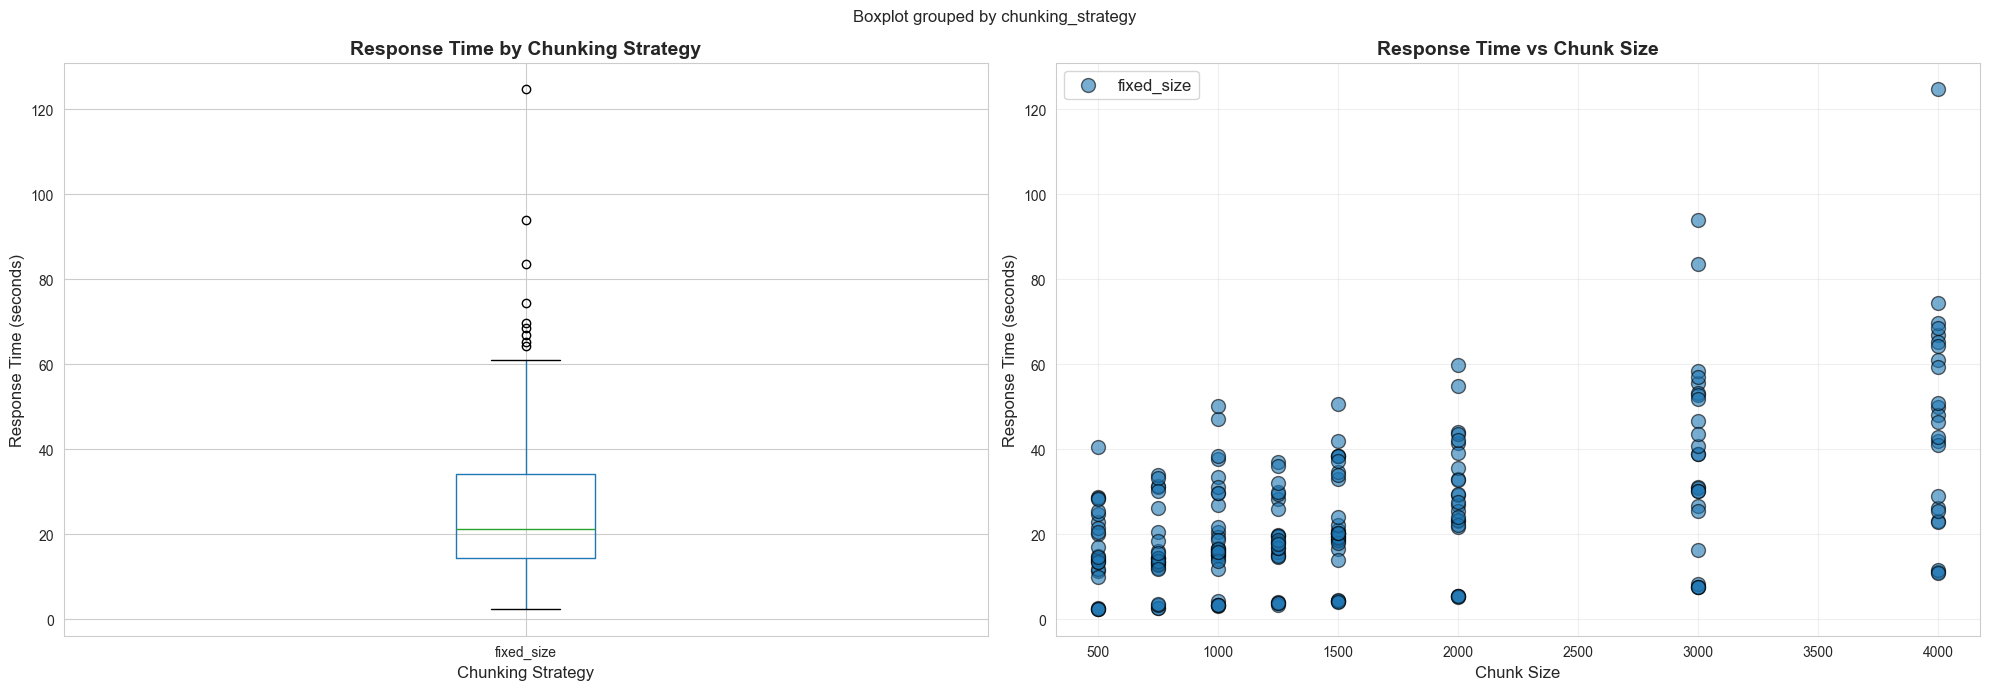

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Response time by chunking strategy
df.boxplot(column='avg_response_time', by='chunking_strategy', ax=axes[0])
axes[0].set_title('Response Time by Chunking Strategy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chunking Strategy', fontsize=12)
axes[0].set_ylabel('Response Time (seconds)', fontsize=12)

# Response time vs chunk size
for strategy in df['chunking_strategy'].unique():
    if pd.notna(strategy):
        strategy_data = df[df['chunking_strategy'] == strategy]
        axes[1].scatter(strategy_data['chunk_size'], strategy_data['avg_response_time'], 
                       label=strategy, s=100, alpha=0.6, edgecolors='black')

axes[1].set_xlabel('Chunk Size', fontsize=12)
axes[1].set_ylabel('Response Time (seconds)', fontsize=12)
axes[1].set_title('Response Time vs Chunk Size', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Top Configurations Analysis

Identify the best performing configurations overall.

In [29]:
# Calculate composite score
df['composite_score'] = (
    df['avg_semantic_similarity'] * 0.35 +
    df['avg_bleu_score'] * 0.20 +
    df['avg_rouge_1_f'] * 0.25 +
    df['avg_tfidf_similarity'] * 0.20
)

# Calculate composite score to match top_k configurations
df['composite_score'] = (
    df['avg_semantic_similarity'] * 0.60 +
    df['avg_bleu_score'] * 0.20 +
    df['avg_tfidf_similarity'] * 0.20
)

# Top 10 configurations
top_configs = df.nlargest(10, 'composite_score')[
    ['chunking_strategy', 'embed_dimension', 'chunk_size', 'overlap', 'model_name',
     'avg_semantic_similarity', 'avg_bleu_score', 'avg_rouge_1_f', 
     'avg_tfidf_similarity', 'composite_score', 'avg_response_time']
].round(4)

print("=" * 120)
print("TOP 10 CONFIGURATIONS (Composite Score)")
print("=" * 120)
print("\nComposite Score = 0.6*Semantic + 0.20*BLEU + 0.20*TF-IDF\n")
display(top_configs.reset_index(drop=True))

TOP 10 CONFIGURATIONS (Composite Score)

Composite Score = 0.6*Semantic + 0.20*BLEU + 0.20*TF-IDF



,chunking_strategy,embed_dimension,chunk_size,overlap,model_name,avg_semantic_similarity,avg_bleu_score,avg_rouge_1_f,avg_tfidf_similarity,composite_score,avg_response_time
0,fixed_size,1024,500,200,Qwen3-4B-Instruct-2507-Q8_0,0.8661,0.1265,0.4608,0.6240,0.6698,13.4849
1,fixed_size,1024,750,450,Qwen3-4B-Instruct-2507-Q8_0,0.8708,0.1132,0.4331,0.6136,0.6678,15.5941
2,fixed_size,1024,750,150,Qwen3-4B-Instruct-2507-Q8_0,0.8654,0.1170,0.4398,0.6221,0.6670,14.5605
3,fixed_size,1024,1000,350,OpenGVLab_InternVL3_5-8B-Q6_K,0.8666,0.1166,0.4670,0.6154,0.6663,18.6125
4,fixed_size,1024,1500,450,InternVL3_5-8B-Q4_K_M,0.8558,0.1191,0.4317,0.6255,0.6624,22.1749
5,fixed_size,1024,2000,150,InternVL3_5-8B-Q4_K_M,0.8594,0.1124,0.3998,0.6149,0.6611,59.7692
6,fixed_size,1024,1250,350,InternVL3_5-8B-Q4_K_M,0.8520,0.1116,0.4533,0.6353,0.6606,14.8351
7,fixed_size,1024,500,100,Qwen3-4B-Instruct-2507-Q8_0,0.8580,0.1057,0.4297,0.6168,0.6593,15.0055
8,fixed_size,1024,500,250,Qwen3-4B-Instruct-2507-Q8_0,0.8594,0.1026,0.4370,0.6156,0.6593,14.5995
9,fixed_size,1024,500,100,InternVL3_5-8B-Q4_K_M,0.8549,0.1129,0.4530,0.6170,0.6589,11.3417


## 10. Best Configuration Per Strategy

Find the optimal configuration for each chunking strategy.

In [30]:
print("=" * 120)
print("BEST CONFIGURATION PER CHUNKING STRATEGY")
print("=" * 120)

for strategy in df['chunking_strategy'].unique():
    if pd.notna(strategy):
        strategy_df = df[df['chunking_strategy'] == strategy]
        best = strategy_df.nlargest(1, 'composite_score')
        
        print(f"\n{'='*120}")
        print(f"{strategy.upper()}")
        print(f"{'='*120}")
        print(f"Model: {best['model_name'].values[0]}")
        print(f"Embedding Dimension: {int(best['embed_dimension'].values[0])}")
        print(f"Chunk Size: {int(best['chunk_size'].values[0])}")
        if strategy == 'fixed_size':
            print(f"Overlap: {int(best['overlap'].values[0])}")
        print(f"\nPerformance Metrics:")
        print(f"  Semantic Similarity: {best['avg_semantic_similarity'].values[0]:.4f}")
        print(f"  BLEU Score: {best['avg_bleu_score'].values[0]:.4f}")
        print(f"  ROUGE-1 F1: {best['avg_rouge_1_f'].values[0]:.4f}")
        print(f"  ROUGE-2 F1: {best['avg_rouge_2_f'].values[0]:.4f}")
        print(f"  TF-IDF Similarity: {best['avg_tfidf_similarity'].values[0]:.4f}")
        print(f"  Composite Score: {best['composite_score'].values[0]:.4f}")
        print(f"  Avg Response Time: {best['avg_response_time'].values[0]:.4f}s")

BEST CONFIGURATION PER CHUNKING STRATEGY

FIXED_SIZE
Model: Qwen3-4B-Instruct-2507-Q8_0
Embedding Dimension: 1024
Chunk Size: 500
Overlap: 200

Performance Metrics:
  Semantic Similarity: 0.8661
  BLEU Score: 0.1265
  ROUGE-1 F1: 0.4608
  ROUGE-2 F1: 0.2018
  TF-IDF Similarity: 0.6240
  Composite Score: 0.6698
  Avg Response Time: 13.4849s


## 11. Detailed Statistical Analysis

Perform statistical tests to validate performance differences.

In [31]:
from scipy import stats

print("=" * 100)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 100)

# T-test between chunking strategies
strategies = df['chunking_strategy'].unique()
if len(strategies) == 2:
    strategy1_data = df[df['chunking_strategy'] == strategies[0]]['avg_semantic_similarity'].dropna()
    strategy2_data = df[df['chunking_strategy'] == strategies[1]]['avg_semantic_similarity'].dropna()
    
    if len(strategy1_data) > 0 and len(strategy2_data) > 0:
        t_stat, p_value = stats.ttest_ind(strategy1_data, strategy2_data)
        
        print(f"\nT-Test: {strategies[0]} vs {strategies[1]}")
        print(f"  Metric: Semantic Similarity")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")
        
        print(f"\n  {strategies[0]} Mean: {strategy1_data.mean():.4f} (±{strategy1_data.std():.4f})")
        print(f"  {strategies[1]} Mean: {strategy2_data.mean():.4f} (±{strategy2_data.std():.4f})")

# ANOVA for chunk sizes (if more than 2 groups)
chunk_sizes = df['chunk_size'].unique()
if len(chunk_sizes) > 2:
    groups = [df[df['chunk_size'] == cs]['avg_semantic_similarity'].dropna() for cs in chunk_sizes]
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) > 2:
        f_stat, p_value = stats.f_oneway(*groups)
        
        print(f"\n\nANOVA: Chunk Size Effect on Semantic Similarity")
        print(f"  F-statistic: {f_stat:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")

STATISTICAL SIGNIFICANCE TESTS


ANOVA: Chunk Size Effect on Semantic Similarity
  F-statistic: 1.7468
  P-value: 0.1002
  Significant: No (α=0.05)


## 12. Summary Report

Generate a comprehensive summary of findings.

In [32]:
print("=" * 120)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 120)

print("\n1. DATASET OVERVIEW")
print("-" * 120)
print(f"   Total Configurations Tested: {len(df)}")
print(f"   Chunking Strategies: {df['chunking_strategy'].nunique()}")
print(f"   Unique Models: {df['model_name'].nunique()}")
print(f"   Embedding Dimension: {int(df['embed_dimension'].mode()[0])}")
print(f"   Chunk Size Range: {int(df['chunk_size'].min())} - {int(df['chunk_size'].max())}")
if len(fixed_size_df) > 0:
    print(f"   Overlap Range (fixed_size): {int(fixed_size_df['overlap'].min())} - {int(fixed_size_df['overlap'].max())}")

print("\n2. BEST OVERALL CONFIGURATION")
print("-" * 120)
best_overall = df.nlargest(1, 'composite_score').iloc[0]
print(f"   Strategy: {best_overall['chunking_strategy']}")
print(f"   Model: {best_overall['model_name']}")
print(f"   Embedding Dimension: {int(best_overall['embed_dimension'])}")
print(f"   Chunk Size: {int(best_overall['chunk_size'])}")
if pd.notna(best_overall['overlap']):
    print(f"   Overlap: {int(best_overall['overlap'])}")
print(f"   Composite Score: {best_overall['composite_score']:.4f}")
print(f"   Semantic Similarity: {best_overall['avg_semantic_similarity']:.4f}")

print("\n3. CHUNKING STRATEGY COMPARISON")
print("-" * 120)
for strategy in df['chunking_strategy'].unique():
    if pd.notna(strategy):
        strategy_data = df[df['chunking_strategy'] == strategy]
        print(f"   {strategy.upper()}:")
        print(f"      Configurations: {len(strategy_data)}")
        print(f"      Avg Semantic Similarity: {strategy_data['avg_semantic_similarity'].mean():.4f}")
        print(f"      Avg Composite Score: {strategy_data['composite_score'].mean():.4f}")
        print(f"      Avg Response Time: {strategy_data['avg_response_time'].mean():.4f}s")

print("\n4. MODEL RANKINGS (By Average Semantic Similarity)")
print("-" * 120)
model_rankings = df.groupby('model_name')['avg_semantic_similarity'].mean().sort_values(ascending=False)
for rank, (model, score) in enumerate(model_rankings.items(), 1):
    print(f"   {rank}. {model}: {score:.4f}")

print("\n5. RECOMMENDATIONS")
print("-" * 120)
print("   Based on the analysis:")
best = df.nlargest(1, 'composite_score').iloc[0]
print(f"   • Best performing setup: {best['chunking_strategy']} with chunk_size={int(best['chunk_size'])}")
print(f"   • Recommended model: {best['model_name']}")
print(f"   • Embedding dimension: {int(best['embed_dimension'])}")
if best['chunking_strategy'] == 'fixed_size':
    print(f"   • Optimal overlap: {int(best['overlap'])}")
print(f"   • Expected semantic similarity: {best['avg_semantic_similarity']:.4f}")
print(f"   • Expected response time: {best['avg_response_time']:.4f}s")

print("\n" + "=" * 120)

COMPREHENSIVE ANALYSIS SUMMARY

1. DATASET OVERVIEW
------------------------------------------------------------------------------------------------------------------------
   Total Configurations Tested: 204
   Chunking Strategies: 1
   Unique Models: 6
   Embedding Dimension: 1024
   Chunk Size Range: 500 - 4000
   Overlap Range (fixed_size): 100 - 450

2. BEST OVERALL CONFIGURATION
------------------------------------------------------------------------------------------------------------------------
   Strategy: fixed_size
   Model: Qwen3-4B-Instruct-2507-Q8_0
   Embedding Dimension: 1024
   Chunk Size: 500
   Overlap: 200
   Composite Score: 0.6698
   Semantic Similarity: 0.8661

3. CHUNKING STRATEGY COMPARISON
------------------------------------------------------------------------------------------------------------------------
   FIXED_SIZE:
      Configurations: 204
      Avg Semantic Similarity: 0.8273
      Avg Composite Score: 0.6276
      Avg Response Time: 26.1336s

4. MO